In [ ]:
import pandas as pd
import torch
from transformers import pipeline
from tqdm.auto import tqdm


df = pd.read_csv('news_per_sentiment_split2.csv')


device = 0 if torch.cuda.is_available() else -1
sentiment_task = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)


batch_size = 32
scores = []

print(f"Analisi in corso su {len(df)} news finanziarie...")

for i in tqdm(range(0, len(df), batch_size)):
    batch_texts = df['testo_per_ai'].iloc[i:i+batch_size].astype(str).tolist()

    results = sentiment_task(batch_texts, truncation=True, max_length=512)


    for res in results:
        s = res['score']
        if res['label'] == 'negative':
            scores.append(-s)
        elif res['label'] == 'positive':
            scores.append(s)
        else:
            scores.append(0)


df['sentiment_score'] = scores
df.to_csv('news_con_sentiment_split_finale7.csv', index=False)
print("\nAnalisi completata! Scarica il file 'news_con_sentiment_split_finale.csv'.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Analisi in corso su 9289 news finanziarie...


  0%|          | 0/291 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Analisi completata! Scarica il file 'news_con_sentiment_split_finale.csv'.


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional # Aggiunto Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# Caricamento dati
df = pd.read_csv('input_per_bilstm_final1.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

features = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# SPLIT 70/30 — il test non viene mai toccato fino alla fine
# ----------------------------------------------------------------
split_idx = int(len(df) * 0.70)
df_trainval = df.iloc[:split_idx].reset_index(drop=True)
df_test     = df.iloc[split_idx:].reset_index(drop=True)

print(f"Dati train+val: {len(df_trainval)} giorni")
print(f"Dati test OOS:  {len(df_test)} giorni")

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

param_grid = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials = 6
tscv = TimeSeriesSplit(n_splits=3)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params = {}

print(f"\nInizio Robust Tuning su {len(param_list)} combinazioni (BiLSTM, CV su trainval)...")

for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_trainval):
        train_fold = df_trainval.iloc[train_idx]
        val_fold   = df_trainval.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])
        val_scaled   = scaler.transform(val_fold[features])

        X_tr, y_tr   = create_sequences(train_scaled, train_fold[target_col].values, current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled,   val_fold[target_col].values,   current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        # --- MODELLO BiLSTM ---
        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            Bidirectional(LSTM(current_params['lstm_units'], return_sequences=True)),
            Dropout(current_params['dropout_rate']),
            Bidirectional(LSTM(int(current_params['lstm_units'] / 2))),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        model.fit(X_tr, y_tr,
                  epochs=50,
                  batch_size=current_params['batch_size'],
                  validation_data=(X_val, y_val),
                  callbacks=[
                      EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
                  ],
                  verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI ---\n{best_params}")

# ----------------------------------------------------------------
# TRAINING FINALE — Solo su df_trainval
# ----------------------------------------------------------------

final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(df_trainval[features])
X_test_scaled     = final_scaler.transform(df_test[features])

X_trainval_seq, y_trainval_seq = create_sequences(X_trainval_scaled, df_trainval[target_col].values, best_params['window_size'])
X_test_seq, y_test_seq = create_sequences(X_test_scaled, df_test[target_col].values, best_params['window_size'])

# Validazione interna per EarlyStopping (10% finale di trainval)
val_size = int(len(X_trainval_seq) * 0.10)
X_tr_es  = X_trainval_seq[:-val_size]
y_tr_es  = y_trainval_seq[:-val_size]
X_val_es = X_trainval_seq[-val_size:]
y_val_es = y_trainval_seq[-val_size:]

# Modello finale BiLSTM
tf.keras.backend.clear_session()
set_reproducibility(42)

final_model_bilstm = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    Bidirectional(LSTM(int(best_params['lstm_units'] / 2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model_bilstm.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining finale in corso (BiLSTM)...")
final_model_bilstm.fit(
    X_tr_es, y_tr_es,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_es, y_val_es),
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
    verbose=1
)

loss, accuracy = final_model_bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET (OOS): {accuracy:.4f}")

Dati train+val: 452 giorni
Dati test OOS:  195 giorni

Inizio Robust Tuning su 6 combinazioni (BiLSTM, CV su trainval)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5049, Std: 0.0286, Score: 0.4477
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5412, Std: 0.0415, Score: 0.4582
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5305, Std: 0.0268, Score: 0.4768
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5307, Std: 0.0046, Score: 0.5216
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5412, Std: 0.0268, Score: 0.4876
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4

Dati totali: 647 giorni
Periodo: 2022-10-18 -> 2025-04-14
Distribuzione target:
Target
0    334
1    313
Name: count, dtype: int64

Train+Val: 452 giorni (2022-10-18 -> 2024-07-11)
Test OOS:  195 giorni (2024-07-14 -> 2025-04-14)

Tuning su 6 combinazioni (CV su trainval)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5016, Std: 0.0199, Score: 0.4617
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.4910, Std: 0.0433, Score: 0.4044
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.4803, Std: 0.0451, Score: 0.3902
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg: 0.4854, Std: 0.0079, Score: 0.4696
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32}

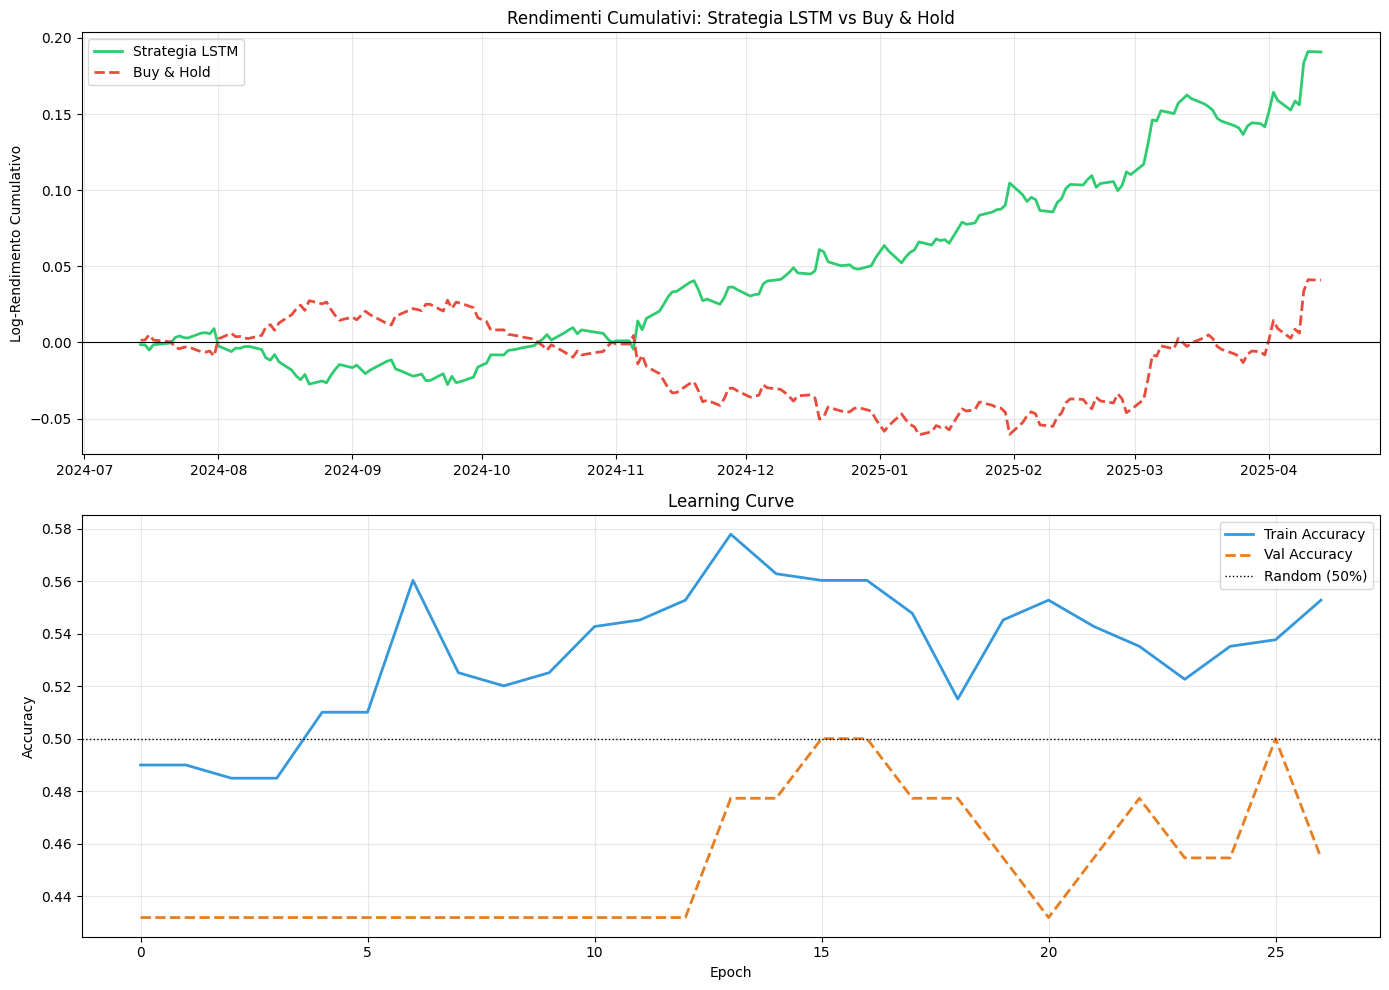


File salvati: 'backtest_results.csv', 'risultati_lstm.png'


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

set_reproducibility(42)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final1.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

features   = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

print(f"Dati totali: {len(df)} giorni")
print(f"Periodo: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Distribuzione target:\n{df[target_col].value_counts()}")

# ----------------------------------------------------------------
# SPLIT 70/30 — test mai toccato fino alla fine
# ----------------------------------------------------------------
split_idx   = int(len(df) * 0.70)
df_trainval = df.iloc[:split_idx].reset_index(drop=True)
df_test     = df.iloc[split_idx:].reset_index(drop=True)

print(f"\nTrain+Val: {len(df_trainval)} giorni "
      f"({df_trainval['Date'].min().date()} -> {df_trainval['Date'].max().date()})")
print(f"Test OOS:  {len(df_test)} giorni "
      f"({df_test['Date'].min().date()} -> {df_test['Date'].max().date()})")

# ----------------------------------------------------------------
# TUNING — solo su df_trainval con TimeSeriesSplit
# ----------------------------------------------------------------
param_grid = {
    'window_size':   [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units':    [32, 64],
    'dropout_rate':  [0.3, 0.4],
    'batch_size':    [32]
}

num_trials = 6
tscv       = TimeSeriesSplit(n_splits=3)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params       = {}

print(f"\nTuning su {len(param_list)} combinazioni (CV su trainval)...")

for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_trainval):
        train_fold = df_trainval.iloc[train_idx]
        val_fold   = df_trainval.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])
        val_scaled   = scaler.transform(val_fold[features])

        X_tr, y_tr   = create_sequences(train_scaled,
                                         train_fold[target_col].values,
                                         current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled,
                                         val_fold[target_col].values,
                                         current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            LSTM(current_params['lstm_units'], return_sequences=True),
            Dropout(current_params['dropout_rate']),
            LSTM(current_params['lstm_units'] // 2),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=Adam(learning_rate=current_params['learning_rate']),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=current_params['batch_size'],
            validation_data=(X_val, y_val),
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=8,
                              restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
            ],
            verbose=0
        )

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> "
          f"Avg: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params       = current_params

print(f"\nMigliori parametri: {best_params}")

# ----------------------------------------------------------------
# TRAINING FINALE — su tutto df_trainval
# ----------------------------------------------------------------
final_scaler      = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(df_trainval[features])

X_trainval_seq, y_trainval_seq = create_sequences(
    X_trainval_scaled,
    df_trainval[target_col].values,
    best_params['window_size']
)

# *** CORREZIONE: aggiungi contesto del trainval al test ***
context           = df_trainval.iloc[-best_params['window_size']:].copy()
test_with_context = pd.concat([context, df_test], ignore_index=True)
X_test_context    = final_scaler.transform(test_with_context[features])

X_test_seq, y_test_seq = create_sequences(
    X_test_context,
    test_with_context[target_col].values,
    best_params['window_size']
)

# Verifica allineamento date
assert len(X_test_seq) == len(df_test), \
    f"Mismatch sequenze: {len(X_test_seq)} vs {len(df_test)}"

print(f"\nSequenze training: {len(X_trainval_seq)}")
print(f"Sequenze test OOS: {len(X_test_seq)}")

# Validation interna per EarlyStopping — ultimi 10% del trainval
val_size = int(len(X_trainval_seq) * 0.10)
X_tr_es  = X_trainval_seq[:-val_size]
y_tr_es  = y_trainval_seq[:-val_size]
X_val_es = X_trainval_seq[-val_size:]
y_val_es = y_trainval_seq[-val_size:]

print(f"Training effettivo: {len(X_tr_es)} | Validation ES: {len(X_val_es)}")

# Modello finale
tf.keras.backend.clear_session()
set_reproducibility(42)

final_model = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    LSTM(best_params['lstm_units'], return_sequences=True),
    Dropout(best_params['dropout_rate']),
    LSTM(best_params['lstm_units'] // 2),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining finale in corso...")
history = final_model.fit(
    X_tr_es, y_tr_es,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_es, y_val_es),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12,
                      restore_best_weights=True)
    ],
    verbose=1
)

# ----------------------------------------------------------------
# VALUTAZIONE SUL TEST OOS
# ----------------------------------------------------------------
loss_test, acc_test = final_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"\nACCURACY SUL TEST SET OOS: {acc_test:.4f}")

# ----------------------------------------------------------------
# BACKTEST — Log_Return_Next per coerenza con il target
# ----------------------------------------------------------------
proba_test  = final_model.predict(X_test_seq, verbose=0).flatten()
binary_test = (proba_test >= 0.5).astype(int)

backtest = df_test.copy()
backtest['Pred']            = binary_test
backtest['Pred_proba']      = proba_test
backtest['Log_Return_Next'] = backtest['Log_Return'].shift(-1)

backtest['Strategy_Return'] = np.where(
    backtest['Pred'] == 1,
     backtest['Log_Return_Next'],
    -backtest['Log_Return_Next']
)
backtest['BuyHold_Return'] = backtest['Log_Return_Next']
backtest = backtest.dropna(subset=['Log_Return_Next']).reset_index(drop=True)

backtest['Cumulative_Strategy'] = backtest['Strategy_Return'].cumsum()
backtest['Cumulative_BuyHold']  = backtest['BuyHold_Return'].cumsum()

# Metriche
ann_factor      = 252
ret_strategy    = backtest['Strategy_Return'].mean() * ann_factor
ret_buyhold     = backtest['BuyHold_Return'].mean()  * ann_factor
vol_strategy    = backtest['Strategy_Return'].std()  * np.sqrt(ann_factor)
vol_buyhold     = backtest['BuyHold_Return'].std()   * np.sqrt(ann_factor)
sharpe_strategy = ret_strategy / vol_strategy if vol_strategy > 0 else 0
sharpe_buyhold  = ret_buyhold  / vol_buyhold  if vol_buyhold  > 0 else 0

def max_drawdown(cumret):
    return (cumret - cumret.cummax()).min()

mdd_strategy = max_drawdown(backtest['Cumulative_Strategy'])
mdd_buyhold  = max_drawdown(backtest['Cumulative_BuyHold'])
win_rate     = (backtest['Strategy_Return'] > 0).mean()
hit_rate     = (backtest['Pred'] == backtest['Target']).mean()

print("\n" + "=" * 55)
print("REPORT BACKTEST")
print("=" * 55)
print(f"Periodo: {backtest['Date'].min().date()} -> {backtest['Date'].max().date()}")
print(f"Giorni totali: {len(backtest)}")
print()
print(f"{'Metrica':<30} {'Strategia':>12} {'Buy&Hold':>12}")
print("-" * 55)
print(f"{'Rendimento annualizzato':<30} {ret_strategy:>11.2%} {ret_buyhold:>11.2%}")
print(f"{'Volatilità annualizzata':<30} {vol_strategy:>11.2%} {vol_buyhold:>11.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_strategy:>12.4f} {sharpe_buyhold:>12.4f}")
print(f"{'Max Drawdown':<30} {mdd_strategy:>11.2%} {mdd_buyhold:>11.2%}")
print(f"{'Win Rate':<30} {win_rate:>11.2%}")
print(f"{'Hit Rate (accuracy)':<30} {hit_rate:>11.2%}")

# ----------------------------------------------------------------
# GRAFICI
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(backtest['Date'], backtest['Cumulative_Strategy'],
             label='Strategia LSTM', color='#2ecc71', linewidth=2)
axes[0].plot(backtest['Date'], backtest['Cumulative_BuyHold'],
             label='Buy & Hold', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Rendimenti Cumulativi: Strategia LSTM vs Buy & Hold')
axes[0].set_ylabel('Log-Rendimento Cumulativo')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)

# Learning curve
axes[1].plot(history.history['accuracy'],
             label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_accuracy'],
             label='Val Accuracy', color='#e67e22', linewidth=2, linestyle='--')
axes[1].axhline(y=0.5, color='black', linewidth=1,
                linestyle=':', label='Random (50%)')
axes[1].set_title('Learning Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('risultati_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

backtest.to_csv('backtest_results.csv', index=False)
print("\nFile salvati: 'backtest_results.csv', 'risultati_lstm.png'")

In [ ]:
from scipy import stats
n = 194
p_hat = 0.5876
z = (p_hat - 0.5) / np.sqrt(0.5 * 0.5 / n)
p_value = 1 - stats.norm.cdf(z)
print(f"z-score: {z:.4f}, p-value: {p_value:.4f}")

z-score: 2.4403, p-value: 0.0073


Baseline accuracy: 0.5846
Calcolo permutation importance...
  Log_Return     : drop medio = 0.0407
  Sigma          : drop medio = 0.0236
  sent_EUR       : drop medio = 0.0260
  sent_USD       : drop medio = 0.0390

--- IMPORTANZA RELATIVA ---
  Log_Return     : 31.5%
  sent_USD       : 30.2%
  sent_EUR       : 20.1%
  Sigma          : 18.3%


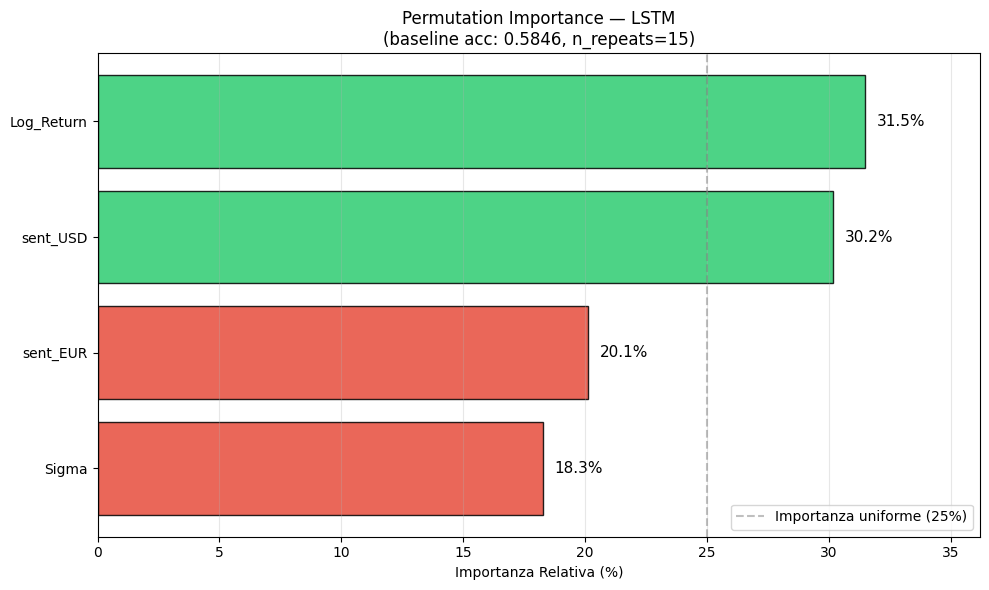

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def permutation_importance(model, X_test, y_test, feature_names, n_repeats=15):
    """
    Calcola la permutation importance per ogni feature.
    Per ogni feature, permuta i valori lungo tutta la finestra temporale
    e misura il calo di accuracy rispetto alla baseline.
    """
    baseline_preds  = (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
    baseline_acc    = (baseline_preds == y_test).mean()

    importances = []
    print(f"Baseline accuracy: {baseline_acc:.4f}")
    print("Calcolo permutation importance...")

    for i, feat in enumerate(feature_names):
        drops = []
        for r in range(n_repeats):
            np.random.seed(r)
            X_perm = X_test.copy()

            # Permuta i valori della feature i lungo tutti i campioni
            # mantenendo la struttura temporale interna invariata
            col = X_perm[:, :, i].copy()
            idx = np.random.permutation(col.shape[0])
            X_perm[:, :, i] = col[idx]

            perm_preds = (model.predict(X_perm, verbose=0).flatten() >= 0.5).astype(int)
            perm_acc   = (perm_preds == y_test).mean()
            drops.append(max(0, baseline_acc - perm_acc))

        mean_drop = np.mean(drops)
        importances.append(mean_drop)
        print(f"  {feat:<15}: drop medio = {mean_drop:.4f}")

    # Normalizza in percentuale
    total = sum(importances) if sum(importances) > 0 else 1
    percentages = [imp / total * 100 for imp in importances]

    print("\n--- IMPORTANZA RELATIVA ---")
    for feat, pct in sorted(zip(feature_names, percentages), key=lambda x: -x[1]):
        print(f"  {feat:<15}: {pct:.1f}%")

    # Grafico
    sorted_pairs = sorted(zip(feature_names, percentages), key=lambda x: x[1])
    feats_sorted = [p[0] for p in sorted_pairs]
    pcts_sorted  = [p[1] for p in sorted_pairs]

    colors = ['#2ecc71' if p > 25 else '#e74c3c' for p in pcts_sorted]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(feats_sorted, pcts_sorted,
                    color=colors, edgecolor='black', alpha=0.85)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}%', va='center', fontsize=11)

    plt.xlabel('Importanza Relativa (%)')
    plt.title('Permutation Importance — LSTM\n'
              f'(baseline acc: {baseline_acc:.4f}, n_repeats={n_repeats})')
    plt.xlim(0, max(pcts_sorted) * 1.15)
    plt.axvline(x=25, color='gray', linestyle='--',
                alpha=0.5, label='Importanza uniforme (25%)')
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance_lstm.png', dpi=150, bbox_inches='tight')
    plt.show()

    return dict(zip(feature_names, percentages))

# ----------------------------------------------------------------
# ESECUZIONE — usa il modello e i dati già in memoria
# ----------------------------------------------------------------
feature_names = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']

importance_results = permutation_importance(
    model       = final_model,
    X_test      = X_test_seq,
    y_test      = y_test_seq,
    feature_names = feature_names,
    n_repeats   = 15
)

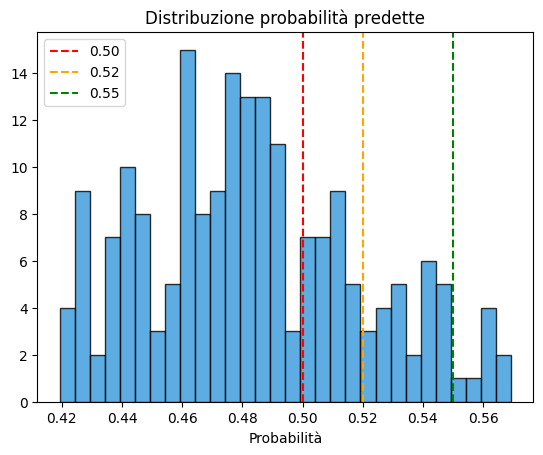

Soglia 0.48: Long=100 (51.3%), Short=162 (83.1%)
Soglia 0.5: Long=61 (31.3%), Short=134 (68.7%)
Soglia 0.52: Long=33 (16.9%), Short=95 (48.7%)
Soglia 0.53: Long=25 (12.8%), Short=72 (36.9%)
Soglia 0.55: Long=8 (4.1%), Short=41 (21.0%)
Soglia 0.57: Long=0 (0.0%), Short=13 (6.7%)
Soglia 0.6: Long=0 (0.0%), Short=0 (0.0%)


In [ ]:
# Distribuzione delle probabilità predette
import matplotlib.pyplot as plt

plt.hist(proba_test, bins=30, edgecolor='black', color='#3498db', alpha=0.8)
plt.axvline(x=0.5, color='red', linestyle='--', label='0.50')
plt.axvline(x=0.52, color='orange', linestyle='--', label='0.52')
plt.axvline(x=0.55, color='green', linestyle='--', label='0.55')
plt.title('Distribuzione probabilità predette')
plt.xlabel('Probabilità')
plt.legend()
plt.show()

# Quanti trade per soglia
for soglia in [0.48, 0.50, 0.52, 0.53, 0.55, 0.57, 0.60]:
    n_long  = (proba_test >= soglia).sum()
    n_short = (proba_test <= 1-soglia).sum()
    print(f"Soglia {soglia}: Long={n_long} ({n_long/len(proba_test):.1%}), "
          f"Short={n_short} ({n_short/len(proba_test):.1%})")


REPORT BACKTEST COMPLETO
Periodo: 2024-07-14 -> 2025-04-13
Giorni totali test set: 194
Annualizzazione: 252 giorni lavorativi

Metrica                           Always In    Only Long   Only Short     Buy&Hold    Random WK
------------------------------------------------------------------------------------------
Rendimento annualizzato             24.78%      12.82%       6.89%       5.31%       8.69%
Volatilità annualizzata              7.95%       5.02%       5.22%       8.10%       8.09%
Sharpe Ratio                         3.1151       2.5520       1.3195       0.6555       1.0750
Sharpe CI 95% lower                  0.8599       0.3038      -0.9181      -1.5793      -1.1614
Sharpe CI 95% upper                  5.3703       4.8002       3.5572       2.8903       3.3113
Max Drawdown                        -3.67%      -1.17%      -3.64%      -8.84%      -4.73%
Win Rate                            58.76%      50.00%      60.00%      44.33%      58.25%
Hit Rate (accuracy)              

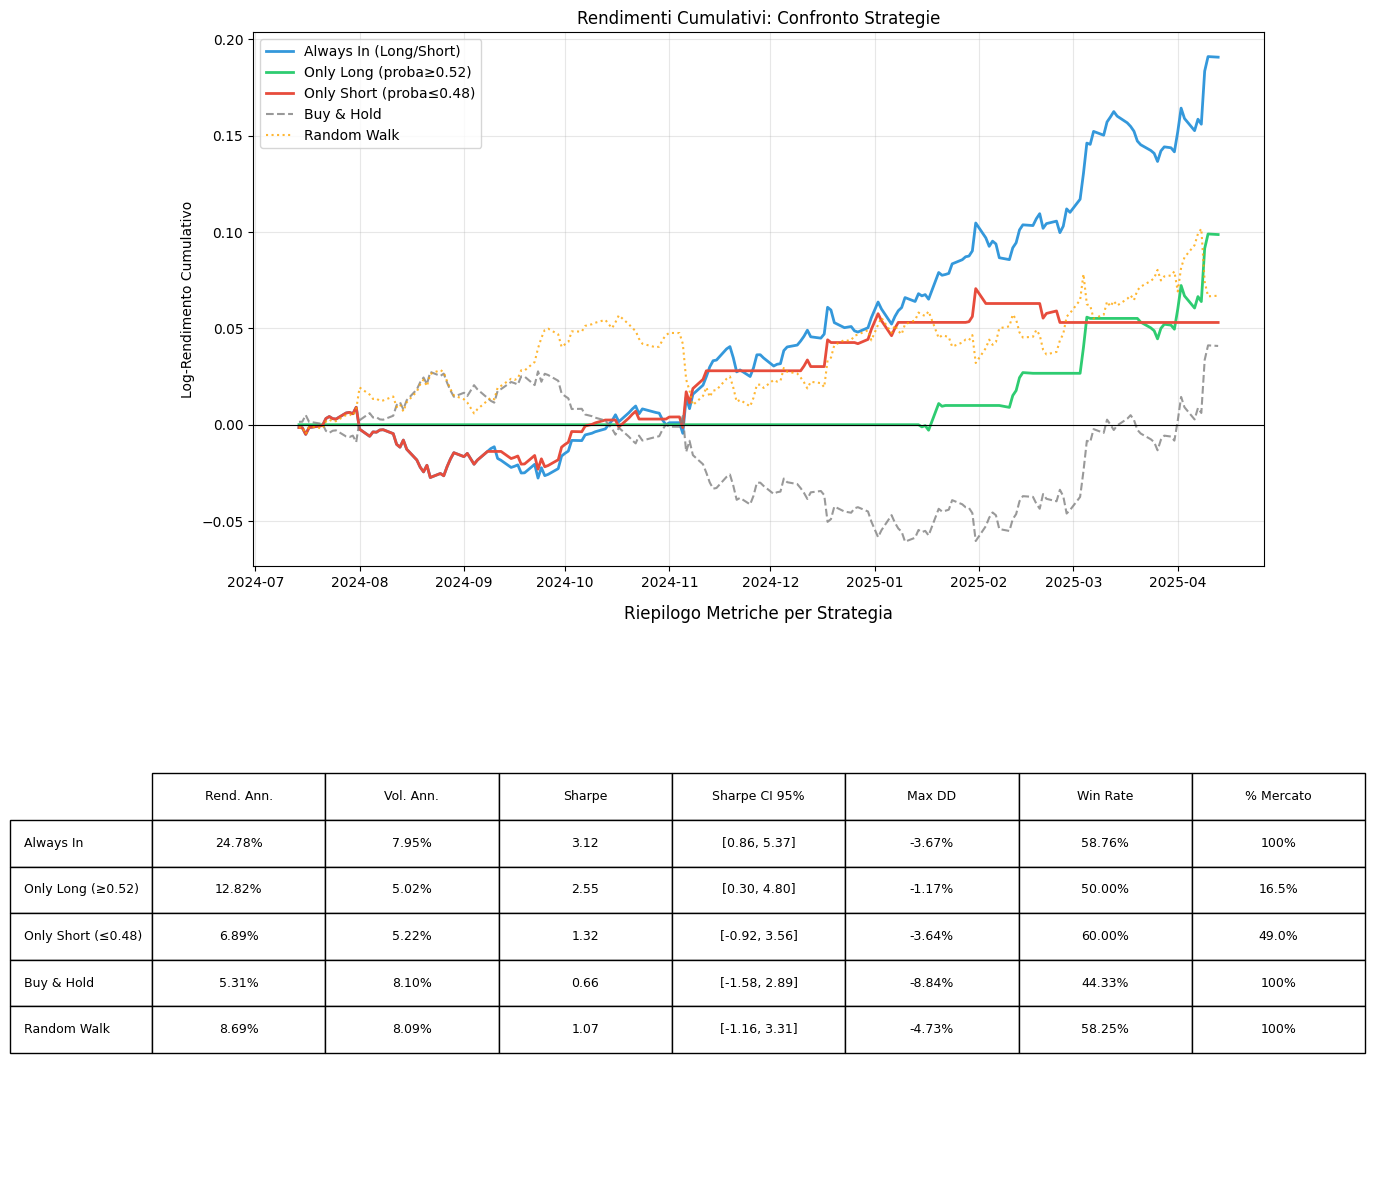


File salvati: 'confronto_strategie.png', 'backtest_random_walk.csv'


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ----------------------------------------------------------------
# FUNZIONI DI SUPPORTO
# ----------------------------------------------------------------
def max_drawdown(cumret):
    return (cumret - cumret.cummax()).min()

def sharpe_confidence_interval(returns, ann_factor=252, confidence=0.95):
    """
    Calcola Sharpe Ratio e intervallo di confidenza secondo
    Jobson & Korkie (1981) corretto da Memmel (2003).
    n è il numero effettivo di osservazioni del campione.
    """
    n      = len(returns)          # giorni effettivi, non 252
    mean_r = returns.mean()
    std_r  = returns.std()
    sharpe = (mean_r / std_r) * np.sqrt(ann_factor) if std_r > 0 else 0
    se     = np.sqrt((1 + 0.5 * sharpe**2 / ann_factor) / n) * np.sqrt(ann_factor)
    z      = stats.norm.ppf((1 + confidence) / 2)
    ci_low  = sharpe - z * se
    ci_high = sharpe + z * se
    return sharpe, ci_low, ci_high

ann_factor   = 252
SOGLIA_LONG  = 0.52
SOGLIA_SHORT = 0.48

# ----------------------------------------------------------------
# RANDOM WALK BENCHMARK
# ----------------------------------------------------------------
np.random.seed(42)
backtest_rw = backtest.copy()
random_pred = np.random.randint(0, 2, size=len(backtest_rw))
backtest_rw['Strategy_Return'] = np.where(
    random_pred == 1,
     backtest_rw['Log_Return_Next'],
    -backtest_rw['Log_Return_Next']
)
backtest_rw['Cumulative_Strategy'] = backtest_rw['Strategy_Return'].cumsum()

# ----------------------------------------------------------------
# ALWAYS IN (Long/Short baseline)
# ----------------------------------------------------------------
sharpe_ls, ci_low_ls, ci_high_ls = sharpe_confidence_interval(
    backtest['Strategy_Return'])
vol_strategy = backtest['Strategy_Return'].std() * np.sqrt(ann_factor)
ret_ann_ls   = backtest['Strategy_Return'].mean() * ann_factor
mdd_ls       = max_drawdown(backtest['Cumulative_Strategy'])
wr_ls        = (backtest['Strategy_Return'] > 0).mean()
hit_ls       = (backtest['Pred'] == backtest['Target']).mean()

# ----------------------------------------------------------------
# ONLY LONG
# ----------------------------------------------------------------
backtest_long = df_test.copy()
backtest_long['Pred_proba']      = proba_test
backtest_long['Log_Return_Next'] = backtest_long['Log_Return'].shift(-1)
backtest_long = backtest_long.dropna(
    subset=['Log_Return_Next']).reset_index(drop=True)

backtest_long['Strategy_Return'] = np.where(
    backtest_long['Pred_proba'] >= SOGLIA_LONG,
    backtest_long['Log_Return_Next'],
    0.0
)
backtest_long['Cumulative_Strategy'] = backtest_long['Strategy_Return'].cumsum()
backtest_long['BuyHold_Return']      = backtest_long['Log_Return_Next']
backtest_long['Cumulative_BuyHold']  = backtest_long['BuyHold_Return'].cumsum()

n_trades_long      = (backtest_long['Pred_proba'] >= SOGLIA_LONG).sum()
pct_in_market_long = n_trades_long / len(backtest_long)
ret_ann_long       = backtest_long['Strategy_Return'].mean() * ann_factor
vol_long           = backtest_long['Strategy_Return'].std() * np.sqrt(ann_factor)
sharpe_long, ci_low_long, ci_high_long = sharpe_confidence_interval(
    backtest_long['Strategy_Return'])
mdd_long = max_drawdown(backtest_long['Cumulative_Strategy'])
wr_long  = (backtest_long.loc[
    backtest_long['Pred_proba'] >= SOGLIA_LONG, 'Strategy_Return'] > 0).mean()

# ----------------------------------------------------------------
# ONLY SHORT
# ----------------------------------------------------------------
backtest_short = df_test.copy()
backtest_short['Pred_proba']      = proba_test
backtest_short['Log_Return_Next'] = backtest_short['Log_Return'].shift(-1)
backtest_short = backtest_short.dropna(
    subset=['Log_Return_Next']).reset_index(drop=True)

backtest_short['Strategy_Return'] = np.where(
    backtest_short['Pred_proba'] <= SOGLIA_SHORT,
   -backtest_short['Log_Return_Next'],
    0.0
)
backtest_short['Cumulative_Strategy'] = backtest_short['Strategy_Return'].cumsum()
backtest_short['BuyHold_Return']      = backtest_short['Log_Return_Next']
backtest_short['Cumulative_BuyHold']  = backtest_short['BuyHold_Return'].cumsum()

n_trades_short      = (backtest_short['Pred_proba'] <= SOGLIA_SHORT).sum()
pct_in_market_short = n_trades_short / len(backtest_short)
ret_ann_short       = backtest_short['Strategy_Return'].mean() * ann_factor
vol_short           = backtest_short['Strategy_Return'].std() * np.sqrt(ann_factor)
sharpe_short, ci_low_short, ci_high_short = sharpe_confidence_interval(
    backtest_short['Strategy_Return'])
mdd_short = max_drawdown(backtest_short['Cumulative_Strategy'])
wr_short  = (backtest_short.loc[
    backtest_short['Pred_proba'] <= SOGLIA_SHORT, 'Strategy_Return'] > 0).mean()

# ----------------------------------------------------------------
# BUY & HOLD
# ----------------------------------------------------------------
ret_ann_bh             = backtest['BuyHold_Return'].mean() * ann_factor
vol_bh                 = backtest['BuyHold_Return'].std() * np.sqrt(ann_factor)
sharpe_bh, ci_low_bh, ci_high_bh = sharpe_confidence_interval(
    backtest['BuyHold_Return'])
mdd_bh = max_drawdown(backtest['Cumulative_BuyHold'])
wr_bh  = (backtest['BuyHold_Return'] > 0).mean()

# ----------------------------------------------------------------
# RANDOM WALK
# ----------------------------------------------------------------
ret_ann_rw             = backtest_rw['Strategy_Return'].mean() * ann_factor
vol_rw                 = backtest_rw['Strategy_Return'].std() * np.sqrt(ann_factor)
sharpe_rw, ci_low_rw, ci_high_rw = sharpe_confidence_interval(
    backtest_rw['Strategy_Return'])
mdd_rw = max_drawdown(backtest_rw['Cumulative_Strategy'])
wr_rw  = (backtest_rw['Strategy_Return'] > 0).mean()

# ----------------------------------------------------------------
# REPORT COMPLETO
# ----------------------------------------------------------------
print("\n" + "=" * 90)
print("REPORT BACKTEST COMPLETO")
print("=" * 90)
print(f"Periodo: {backtest['Date'].min().date()} -> {backtest['Date'].max().date()}")
print(f"Giorni totali test set: {len(backtest)}")
print(f"Annualizzazione: {ann_factor} giorni lavorativi")
print()

header = (f"{'Metrica':<30} {'Always In':>12} {'Only Long':>12} "
          f"{'Only Short':>12} {'Buy&Hold':>12} {'Random WK':>12}")
sep = "-" * 90
print(header)
print(sep)
print(f"{'Rendimento annualizzato':<30} "
      f"{ret_ann_ls:>11.2%} {ret_ann_long:>11.2%} "
      f"{ret_ann_short:>11.2%} {ret_ann_bh:>11.2%} {ret_ann_rw:>11.2%}")
print(f"{'Volatilità annualizzata':<30} "
      f"{vol_strategy:>11.2%} {vol_long:>11.2%} "
      f"{vol_short:>11.2%} {vol_bh:>11.2%} {vol_rw:>11.2%}")
print(f"{'Sharpe Ratio':<30} "
      f"{sharpe_ls:>12.4f} {sharpe_long:>12.4f} "
      f"{sharpe_short:>12.4f} {sharpe_bh:>12.4f} {sharpe_rw:>12.4f}")
print(f"{'Sharpe CI 95% lower':<30} "
      f"{ci_low_ls:>12.4f} {ci_low_long:>12.4f} "
      f"{ci_low_short:>12.4f} {ci_low_bh:>12.4f} {ci_low_rw:>12.4f}")
print(f"{'Sharpe CI 95% upper':<30} "
      f"{ci_high_ls:>12.4f} {ci_high_long:>12.4f} "
      f"{ci_high_short:>12.4f} {ci_high_bh:>12.4f} {ci_high_rw:>12.4f}")
print(f"{'Max Drawdown':<30} "
      f"{mdd_ls:>11.2%} {mdd_long:>11.2%} "
      f"{mdd_short:>11.2%} {mdd_bh:>11.2%} {mdd_rw:>11.2%}")
print(f"{'Win Rate':<30} "
      f"{wr_ls:>11.2%} {wr_long:>11.2%} "
      f"{wr_short:>11.2%} {wr_bh:>11.2%} {wr_rw:>11.2%}")
print(f"{'Hit Rate (accuracy)':<30} "
      f"{hit_ls:>11.2%} {'N/A':>12} {'N/A':>12} {'N/A':>12} {'N/A':>12}")
print(f"{'% Giorni a mercato':<30} "
      f"{'100%':>12} {pct_in_market_long:>11.1%} "
      f"{pct_in_market_short:>11.1%} {'100%':>12} {'100%':>12}")
print(sep)

# ----------------------------------------------------------------
# GRAFICO RENDIMENTI CUMULATIVI
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

axes[0].plot(backtest['Date'],
             backtest['Cumulative_Strategy'],
             label='Always In (Long/Short)',
             color='#3498db', linewidth=2)
axes[0].plot(backtest_long['Date'],
             backtest_long['Cumulative_Strategy'],
             label=f'Only Long (proba≥{SOGLIA_LONG})',
             color='#2ecc71', linewidth=2)
axes[0].plot(backtest_short['Date'],
             backtest_short['Cumulative_Strategy'],
             label=f'Only Short (proba≤{SOGLIA_SHORT})',
             color='#e74c3c', linewidth=2)
axes[0].plot(backtest['Date'],
             backtest['Cumulative_BuyHold'],
             label='Buy & Hold',
             color='gray', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].plot(backtest_rw['Date'],
             backtest_rw['Cumulative_Strategy'],
             label='Random Walk',
             color='orange', linewidth=1.5, linestyle=':', alpha=0.8)

axes[0].set_title('Rendimenti Cumulativi: Confronto Strategie')
axes[0].set_ylabel('Log-Rendimento Cumulativo')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)

# ----------------------------------------------------------------
# TABELLA RIASSUNTIVA
# ----------------------------------------------------------------
metriche = ['Rend. Ann.', 'Vol. Ann.', 'Sharpe',
            'Sharpe CI 95%', 'Max DD', 'Win Rate', '% Mercato']

def fmt_ci(lo, hi):
    return f"[{lo:.2f}, {hi:.2f}]"

table_data = [
    [f"{ret_ann_ls:.2%}",    f"{vol_strategy:.2%}", f"{sharpe_ls:.2f}",
     fmt_ci(ci_low_ls, ci_high_ls),
     f"{mdd_ls:.2%}",    f"{wr_ls:.2%}",    "100%"],
    [f"{ret_ann_long:.2%}",  f"{vol_long:.2%}",     f"{sharpe_long:.2f}",
     fmt_ci(ci_low_long, ci_high_long),
     f"{mdd_long:.2%}", f"{wr_long:.2%}",   f"{pct_in_market_long:.1%}"],
    [f"{ret_ann_short:.2%}", f"{vol_short:.2%}",    f"{sharpe_short:.2f}",
     fmt_ci(ci_low_short, ci_high_short),
     f"{mdd_short:.2%}", f"{wr_short:.2%}", f"{pct_in_market_short:.1%}"],
    [f"{ret_ann_bh:.2%}",    f"{vol_bh:.2%}",       f"{sharpe_bh:.2f}",
     fmt_ci(ci_low_bh, ci_high_bh),
     f"{mdd_bh:.2%}",    f"{wr_bh:.2%}",    "100%"],
    [f"{ret_ann_rw:.2%}",    f"{vol_rw:.2%}",       f"{sharpe_rw:.2f}",
     fmt_ci(ci_low_rw, ci_high_rw),
     f"{mdd_rw:.2%}",    f"{wr_rw:.2%}",    "100%"],
]

row_labels = [
    'Always In',
    f'Only Long (≥{SOGLIA_LONG})',
    f'Only Short (≤{SOGLIA_SHORT})',
    'Buy & Hold',
    'Random Walk'
]

axes[1].axis('off')
table = axes[1].table(
    cellText  = table_data,
    rowLabels = row_labels,
    colLabels = metriche,
    cellLoc   = 'center',
    loc       = 'center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.2)
axes[1].set_title('Riepilogo Metriche per Strategia', pad=20)

plt.tight_layout()
plt.savefig('confronto_strategie.png', dpi=150, bbox_inches='tight')
plt.show()

backtest_rw.to_csv('backtest_random_walk.csv', index=False)
print("\nFile salvati: 'confronto_strategie.png', 'backtest_random_walk.csv'")

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# Caricamento dati
df = pd.read_csv('input_per_bilstm_final1.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

features_lstm = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col_lstm = 'Target'

def create_sequences_lstm(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# Grid dei parametri specifica per LSTM
param_grid_lstm = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials_lstm = 6
tscv_lstm = TimeSeriesSplit(n_splits=5)
param_list_lstm = list(ParameterSampler(param_grid_lstm, n_iter=num_trials_lstm, random_state=42))

best_robust_score_lstm = -np.inf
best_params_lstm = {}

print(f"Inizio Robust Tuning su {len(param_list_lstm)} combinazioni UNICHE (Modello LSTM Unidirezionale)...")

for trial, current_params in enumerate(param_list_lstm):
    fold_accs_lstm = []

    for train_idx, val_idx in tscv_lstm.split(df):
        train_df_lstm = df.iloc[train_idx]
        val_df_lstm = df.iloc[val_idx]

        scaler_lstm = StandardScaler()
        train_scaled_lstm = scaler_lstm.fit_transform(train_df_lstm[features_lstm])
        val_scaled_lstm = scaler_lstm.transform(val_df_lstm[features_lstm])

        X_tr_lstm, y_tr_lstm = create_sequences_lstm(train_scaled_lstm, train_df_lstm[target_col_lstm].values, current_params['window_size'])
        X_val_lstm, y_val_lstm = create_sequences_lstm(val_scaled_lstm, val_df_lstm[target_col_lstm].values, current_params['window_size'])

        if len(X_tr_lstm) < 10 or len(X_val_lstm) < 10: continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        # ARCHITETTURA: SOLO LSTM (UNIDIREZIONALE)
        model_tuning_lstm = Sequential([
            Input(shape=(current_params['window_size'], len(features_lstm))),
            LSTM(current_params['lstm_units'], return_sequences=True),
            Dropout(current_params['dropout_rate']),
            LSTM(int(current_params['lstm_units']/2)),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model_tuning_lstm.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                                  loss='binary_crossentropy', metrics=['accuracy'])

        callbacks_lstm = [
            EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
        ]

        model_tuning_lstm.fit(X_tr_lstm, y_tr_lstm, epochs=50, batch_size=current_params['batch_size'],
                              validation_data=(X_val_lstm, y_val_lstm), callbacks=callbacks_lstm, verbose=0)

        _, acc_lstm = model_tuning_lstm.evaluate(X_val_lstm, y_val_lstm, verbose=0)
        fold_accs_lstm.append(acc_lstm)

    avg_acc_lstm = np.mean(fold_accs_lstm)
    std_acc_lstm = np.std(fold_accs_lstm)
    robust_score_trial_lstm = avg_acc_lstm - (2 * std_acc_lstm)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc_lstm:.4f}, Score: {robust_score_trial_lstm:.4f}")

    if robust_score_trial_lstm > best_robust_score_lstm:
        best_robust_score_lstm = robust_score_trial_lstm
        best_params_lstm = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI (LSTM) ---\n{best_params_lstm}")

# --- TRAINING FINALE CON IL MODELLO LSTM ---
split_idx_lstm = int(len(df) * 0.8)
train_final_lstm = df.iloc[:split_idx_lstm]
test_final_lstm = df.iloc[split_idx_lstm:]

final_scaler_lstm = StandardScaler()
X_train_scaled_final_lstm = final_scaler_lstm.fit_transform(train_final_lstm[features_lstm])
X_test_scaled_final_lstm = final_scaler_lstm.transform(test_final_lstm[features_lstm])

X_train_fin_lstm, y_train_fin_lstm = create_sequences_lstm(X_train_scaled_final_lstm, train_final_lstm[target_col_lstm].values, best_params_lstm['window_size'])
X_test_fin_lstm, y_test_fin_lstm = create_sequences_lstm(X_test_scaled_final_lstm, test_final_lstm[target_col_lstm].values, best_params_lstm['window_size'])

set_reproducibility(42)
final_modellstm = Sequential([
    Input(shape=(best_params_lstm['window_size'], len(features_lstm))),
    LSTM(best_params_lstm['lstm_units'], return_sequences=True),
    Dropout(best_params_lstm['dropout_rate']),
    LSTM(int(best_params_lstm['lstm_units']/2)),
    Dropout(best_params_lstm['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_modellstm.compile(optimizer=Adam(learning_rate=best_params_lstm['learning_rate']),
                        loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining finale in corso (LSTM)...")
history_lstm = final_modellstm.fit(X_train_fin_lstm, y_train_fin_lstm, epochs=100,
                                  batch_size=best_params_lstm['batch_size'],
                                  validation_data=(X_test_fin_lstm, y_test_fin_lstm),
                                  callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
                                  verbose=1)

loss_final_lstm, accuracy_final_lstm = final_modellstm.evaluate(X_test_fin_lstm, y_test_fin_lstm, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET (LSTM): {accuracy_final_lstm:.4f}")

Inizio Robust Tuning su 6 combinazioni UNICHE (Modello LSTM Unidirezionale)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.4948, Score: 0.4296
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.4690, Score: 0.3346
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.4759, Score: 0.3537
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5258, Score: 0.4364
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.4782, Score: 0.3577
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5241, Score: 0.4270

--- MIGLIORI PARAMETRI TROVATI (LSTM) ---
{'window_si

Analisi stabilità per BiLSTM...


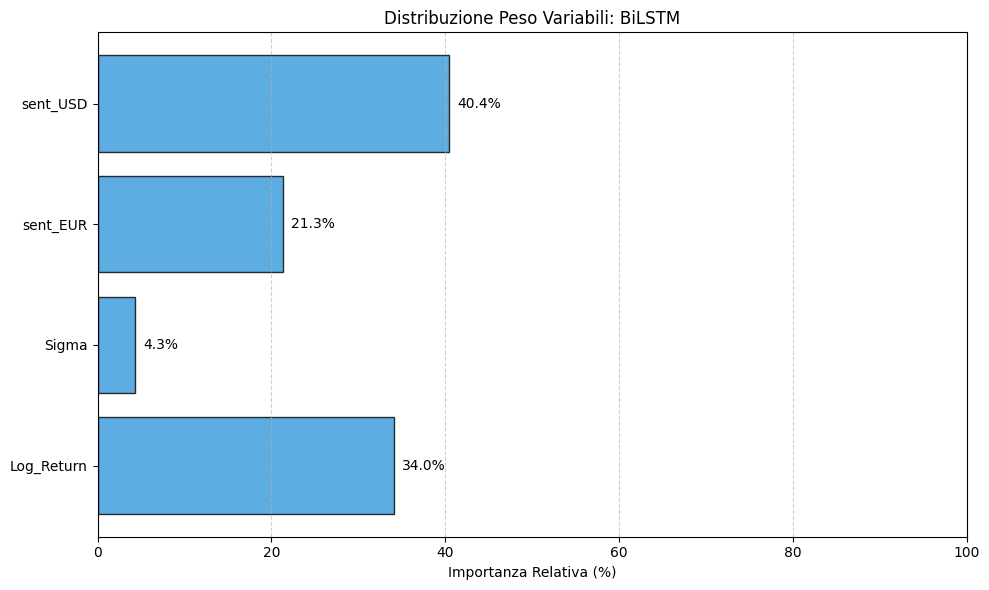

Analisi stabilità per LSTM...


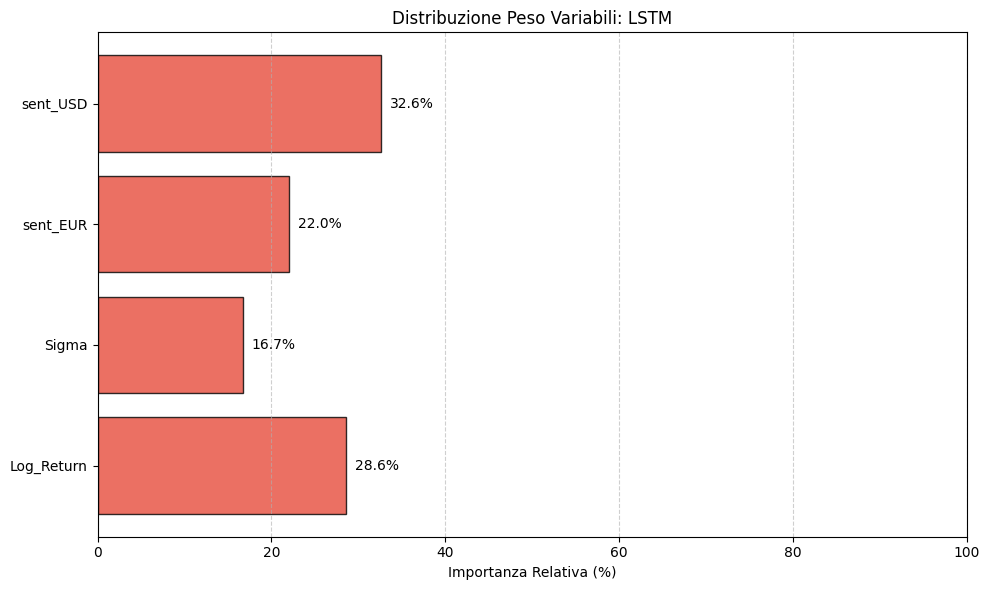

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_importance_percentage(model, X_test, y_test, features, title, n_repeats=15):
    # Accuratezza base
    _, baseline_acc = model.evaluate(X_test, y_test, verbose=0)
    importances = []

    print(f"Analisi stabilità per {title}...")

    for i in range(len(features)):
        scores = []
        for r in range(n_repeats):
            np.random.seed(r)
            X_permuted = X_test.copy()
            col = X_permuted[:, :, i].copy()
            # Rimescolamento
            flat = col.flatten()
            np.random.shuffle(flat)
            X_permuted[:, :, i] = flat.reshape(col.shape)

            _, perm_acc = model.evaluate(X_permuted, y_test, verbose=0)
            # Calcolo calo (se negativo, mettiamo 0 per la percentuale)
            drop = max(0, baseline_acc - perm_acc)
            scores.append(drop)

        importances.append(np.mean(scores))

    # Trasformazione in percentuale
    total_importance = sum(importances)
    if total_importance == 0:
        percentages = [100/len(features)] * len(features) # Distribuzione equa se nulla è rilevante
    else:
        percentages = [(imp / total_importance) * 100 for imp in importances]

    # Grafico pulito
    plt.figure(figsize=(10, 6))
    colors = ['#3498db' if 'Bi' in title else '#e74c3c']
    bars = plt.barh(features, percentages, color=colors, edgecolor='black', alpha=0.8)

    plt.xlabel('Importanza Relativa (%)')
    plt.title(f'Distribuzione Peso Variabili: {title}')
    plt.xlim(0, 100)

    # Aggiungi etichette percentuali sulle barre
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Esecuzione
features_names = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
plot_importance_percentage(final_model, X_test_fin, y_test_fin, features_names, "BiLSTM")
plot_importance_percentage(final_modellstm, X_test_fin_lstm, y_test_fin_lstm, features_names, "LSTM")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


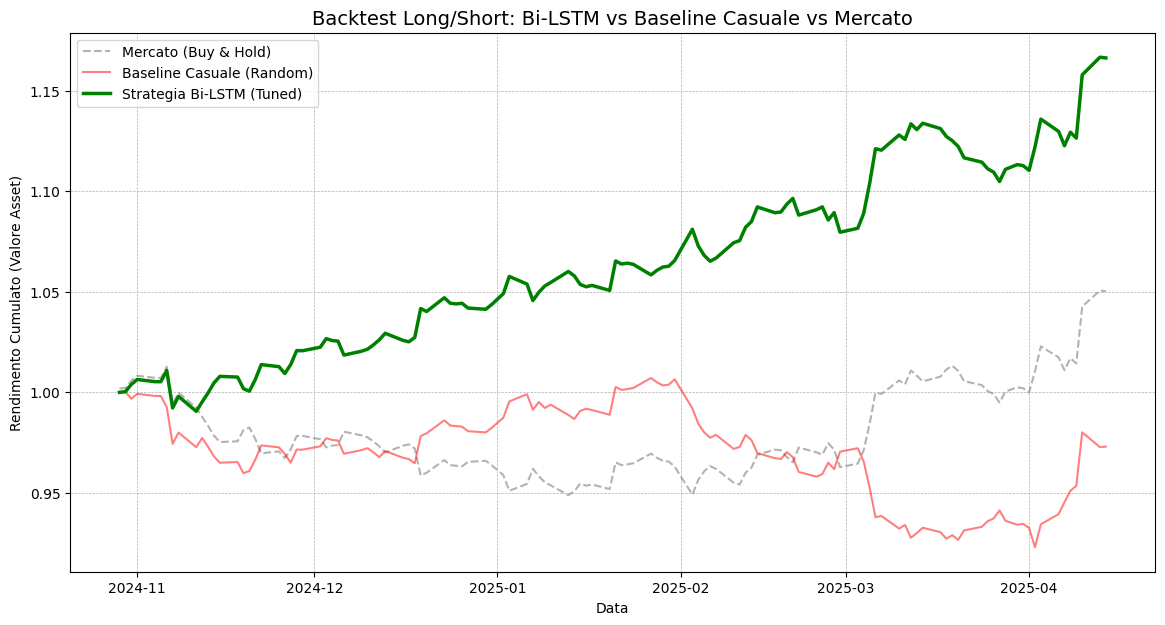

Rendimento Totale Bi-LSTM: 16.63%
Rendimento Totale Casuale: -2.69%
Rendimento Totale Mercato: 5.03%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


y_pred_probs = final_model.predict(X_test_fin)


window_size = best_params['window_size']

test_dates = test_final['Date'].iloc[window_size:].values

test_returns = test_final['Log_Return'].iloc[window_size:].values

backtest_df = pd.DataFrame({
    'Date': test_dates,
    'Actual_Return': test_returns,
    'Prob_Up': y_pred_probs.flatten()
})


soglia_mediana = backtest_df['Prob_Up'].median()
backtest_df['Pos_BiLSTM'] = np.where(backtest_df['Prob_Up'] > 0.5, 1, -1)


backtest_df['Ret_BiLSTM'] = backtest_df['Pos_BiLSTM'].shift(1) * backtest_df['Actual_Return']


np.random.seed(42)
backtest_df['Pos_Random'] = np.random.choice([1, -1], size=len(backtest_df))
backtest_df['Ret_Random'] = backtest_df['Pos_Random'].shift(1) * backtest_df['Actual_Return']


backtest_df['Equity_Market'] = np.exp(backtest_df['Actual_Return'].cumsum())
backtest_df['Equity_BiLSTM'] = np.exp(backtest_df['Ret_BiLSTM'].fillna(0).cumsum())
backtest_df['Equity_Random'] = np.exp(backtest_df['Ret_Random'].fillna(0).cumsum())


plt.figure(figsize=(14, 7))
plt.plot(backtest_df['Date'], backtest_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_df['Date'], backtest_df['Equity_Random'], label='Baseline Casuale (Random)', color='red', alpha=0.5)
plt.plot(backtest_df['Date'], backtest_df['Equity_BiLSTM'], label='Strategia Bi-LSTM (Tuned)', color='green', linewidth=2.5)

plt.title('Backtest Long/Short: Bi-LSTM vs Baseline Casuale vs Mercato', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


perf_bilstm = (backtest_df['Equity_BiLSTM'].iloc[-1] - 1) * 100
perf_random = (backtest_df['Equity_Random'].iloc[-1] - 1) * 100
perf_market = (backtest_df['Equity_Market'].iloc[-1] - 1) * 100

print(f"Rendimento Totale Bi-LSTM: {perf_bilstm:.2f}%")
print(f"Rendimento Totale Casuale: {perf_random:.2f}%")
print(f"Rendimento Totale Mercato: {perf_market:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


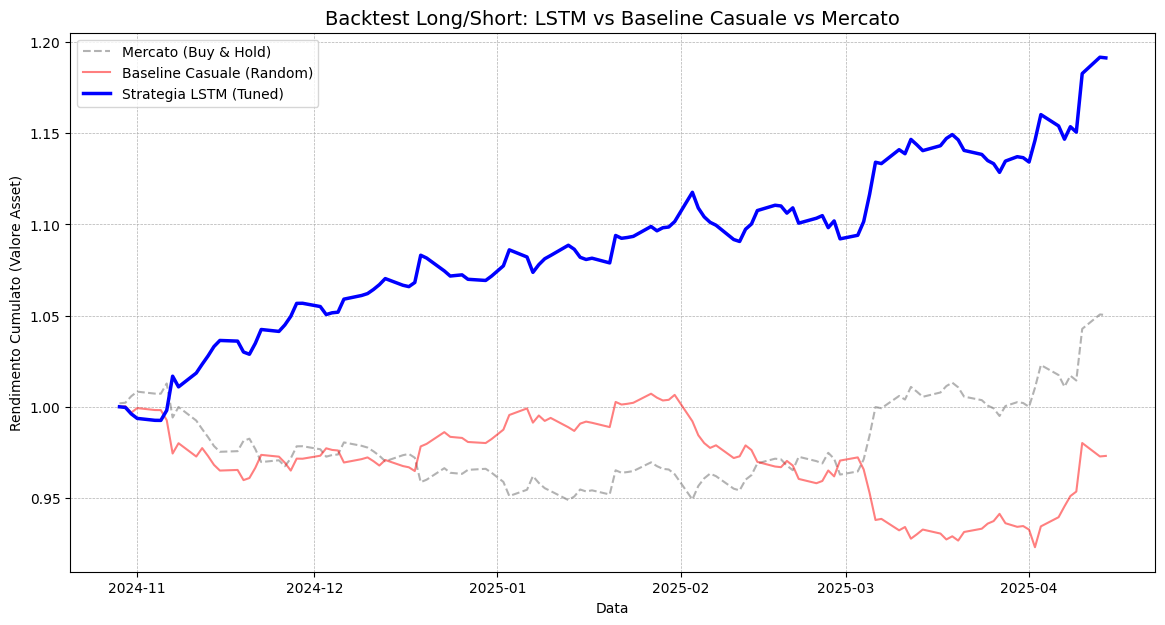

Rendimento Totale LSTM:    19.13%
Rendimento Totale Casuale: -2.69%
Rendimento Totale Mercato: 5.03%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs_lstm = final_modellstm.predict(X_test_fin_lstm)

window_size_lstm = best_params_lstm['window_size']

test_dates_lstm = test_final_lstm['Date'].iloc[window_size_lstm:].values
test_returns_lstm = test_final_lstm['Log_Return'].iloc[window_size_lstm:].values

backtest_lstm_df = pd.DataFrame({
    'Date': test_dates_lstm,
    'Actual_Return': test_returns_lstm,
    'Prob_Up': y_pred_probs_lstm.flatten()
})

soglia_mediana_lstm = backtest_lstm_df['Prob_Up'].median()
backtest_lstm_df['Pos_LSTM'] = np.where(backtest_lstm_df['Prob_Up'] > 0.5, 1, -1)

backtest_lstm_df['Ret_LSTM'] = backtest_lstm_df['Pos_LSTM'].shift(1) * backtest_lstm_df['Actual_Return']

np.random.seed(42)
backtest_lstm_df['Pos_Random'] = np.random.choice([1, -1], size=len(backtest_lstm_df))
backtest_lstm_df['Ret_Random'] = backtest_lstm_df['Pos_Random'].shift(1) * backtest_lstm_df['Actual_Return']

backtest_lstm_df['Equity_Market'] = np.exp(backtest_lstm_df['Actual_Return'].cumsum())
backtest_lstm_df['Equity_LSTM'] = np.exp(backtest_lstm_df['Ret_LSTM'].fillna(0).cumsum())
backtest_lstm_df['Equity_Random'] = np.exp(backtest_lstm_df['Ret_Random'].fillna(0).cumsum())

plt.figure(figsize=(14, 7))
plt.plot(backtest_lstm_df['Date'], backtest_lstm_df['Equity_Market'], label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_lstm_df['Date'], backtest_lstm_df['Equity_Random'], label='Baseline Casuale (Random)', color='red', alpha=0.5)
plt.plot(backtest_lstm_df['Date'], backtest_lstm_df['Equity_LSTM'], label='Strategia LSTM (Tuned)', color='blue', linewidth=2.5)

plt.title('Backtest Long/Short: LSTM vs Baseline Casuale vs Mercato', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

perf_lstm   = (backtest_lstm_df['Equity_LSTM'].iloc[-1] - 1) * 100
perf_random = (backtest_lstm_df['Equity_Random'].iloc[-1] - 1) * 100
perf_market = (backtest_lstm_df['Equity_Market'].iloc[-1] - 1) * 100

print(f"Rendimento Totale LSTM:    {perf_lstm:.2f}%")
print(f"Rendimento Totale Casuale: {perf_random:.2f}%")
print(f"Rendimento Totale Mercato: {perf_market:.2f}%")

In [ ]:
# --- SHUFFLE TEST ---
# Mischiamo a caso le previsioni.
# Se il profitto scompare, allora il modello stava davvero leggendo dei pattern.
previsioni_shuffled = backtest_lstm_df['Pos_LSTM'].sample(frac=1, random_state=123).values
ret_shuffled = previsioni_shuffled * backtest_lstm_df['Actual_Return']

sharpe_random = calcola_sharpe(ret_shuffled.dropna())
print(f"SHARPE CON PREVISIONI CASUALI: {sharpe_random:.4f}")

SHARPE CON PREVISIONI CASUALI: 0.5294


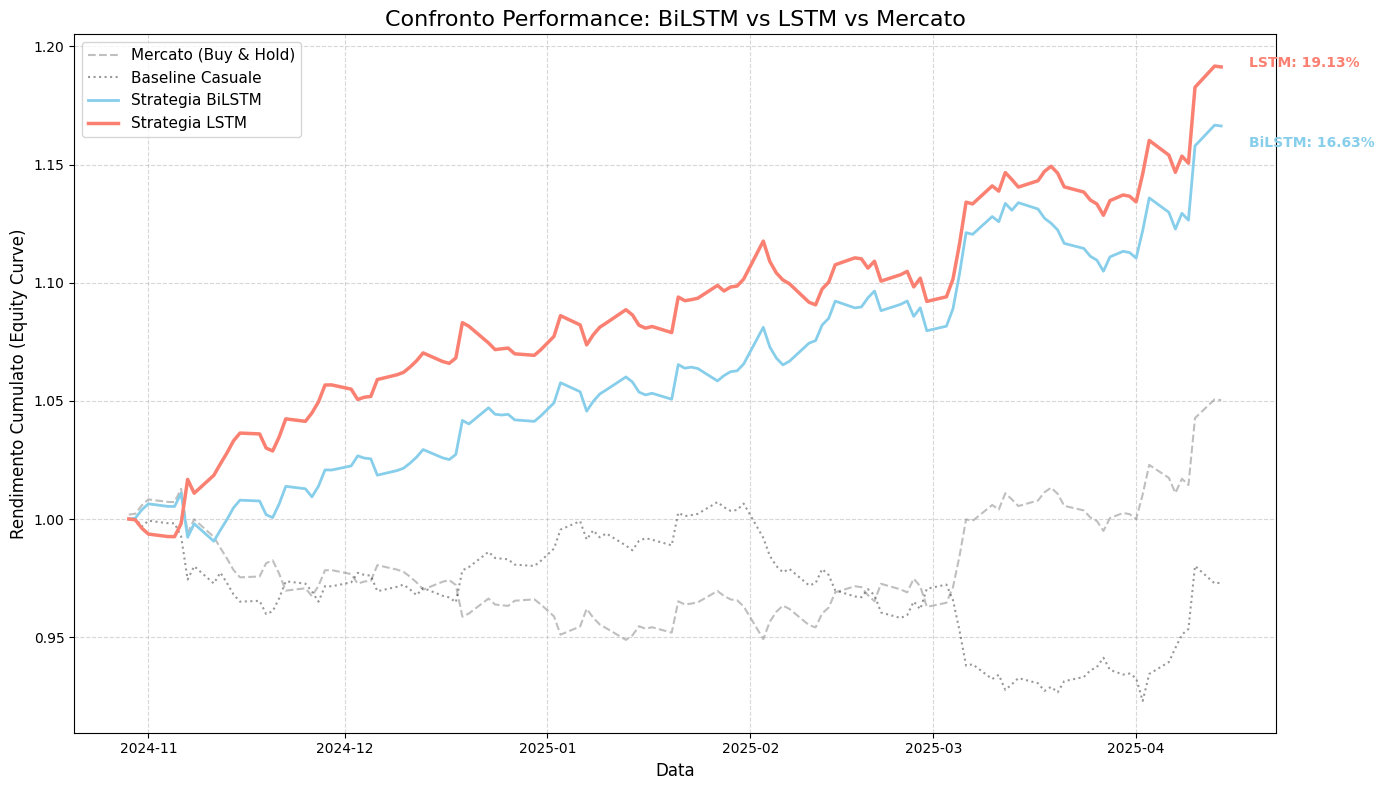

In [ ]:
import matplotlib.pyplot as plt

# Creiamo un nuovo grafico di confronto
plt.figure(figsize=(14, 8))

# 1. Benchmark: Mercato (Buy & Hold) - Usiamo i dati della BiLSTM come riferimento (sono uguali)
plt.plot(backtest_df['Date'], backtest_df['Equity_Market'],
         label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.5)

# 2. Benchmark: Baseline Casuale (Random)
plt.plot(backtest_df['Date'], backtest_df['Equity_Random'],
         label='Baseline Casuale', color='black', linestyle=':', alpha=0.4)

# 3. Strategia BiLSTM (Modello Bidirezionale)
plt.plot(backtest_df['Date'], backtest_df['Equity_BiLSTM'],
         label='Strategia BiLSTM', color='skyblue', linewidth=2)

# 4. Strategia LSTM (Modello Unidirezionale)
plt.plot(backtest_lstm_df['Date'], backtest_lstm_df['Equity_LSTM'],
         label='Strategia LSTM', color='salmon', linewidth=2.5)

# Formattazione grafica
plt.title('Confronto Performance: BiLSTM vs LSTM vs Mercato', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Rendimento Cumulato (Equity Curve)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Aggiungiamo un'annotazione per il rendimento finale
final_val_bilstm = backtest_df['Equity_BiLSTM'].iloc[-1]
final_val_lstm = backtest_lstm_df['Equity_LSTM'].iloc[-1]

plt.annotate(f'LSTM: {perf_lstm:.2f}%',
             xy=(backtest_lstm_df['Date'].iloc[-1], final_val_lstm),
             xytext=(20, 0), textcoords='offset points', color='salmon', fontweight='bold')

plt.annotate(f'BiLSTM: {perf_bilstm:.2f}%',
             xy=(backtest_df['Date'].iloc[-1], final_val_bilstm),
             xytext=(20, -15), textcoords='offset points', color='skyblue', fontweight='bold')

plt.tight_layout()
plt.show()


--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---
                     Rendimento Totale (%)  Sharpe Ratio  Max Drawdown (%)
Bi-LSTM (Tuned)                      16.63          3.54             -2.56
Mercato (Benchmark)                   5.03          1.10             -6.31
Casuale (Baseline)                   -2.69         -0.61             -8.36


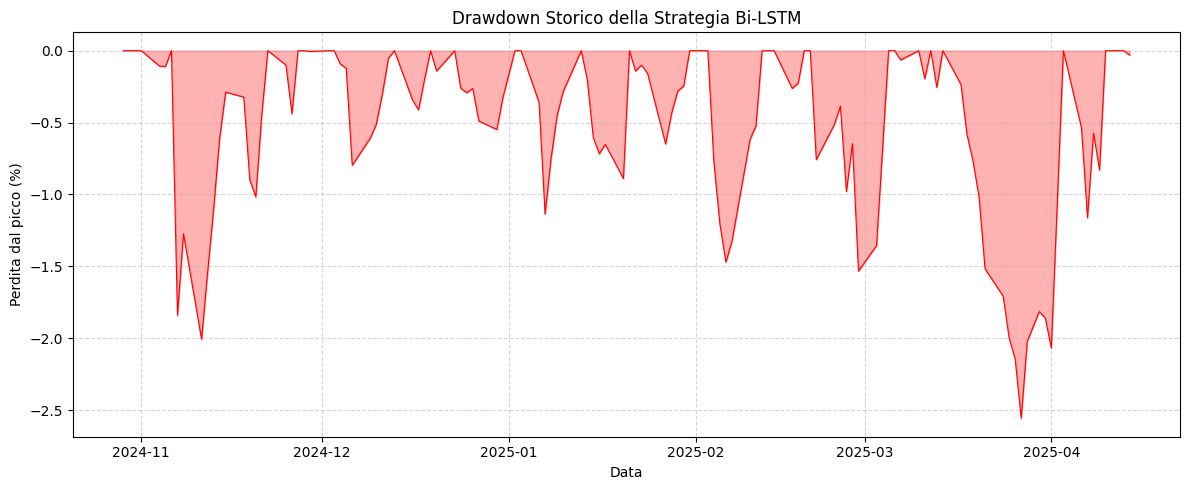

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_metrics(log_returns, name="Strategia"):

    total_return = (np.exp(np.sum(log_returns)) - 1) * 100


    avg_return = np.mean(log_returns)
    std_return = np.std(log_returns)

    if std_return != 0:

        sharpe = (avg_return / std_return) * np.sqrt(252)
    else:
        sharpe = 0


    cumulative = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(cumulative)

    drawdown = (cumulative - peak) / np.where(peak == 0, 1, peak)
    max_drawdown = np.min(drawdown) * 100

    return {
        "Rendimento Totale (%)": round(total_return, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_drawdown, 2)
    }


metrics_bilstm = calculate_metrics(backtest_df['Ret_BiLSTM'].fillna(0), "Bi-LSTM")
metrics_market = calculate_metrics(backtest_df['Actual_Return'], "Mercato")
metrics_random = calculate_metrics(backtest_df['Ret_Random'].fillna(0), "Casuale")


summary_table = pd.DataFrame([metrics_bilstm, metrics_market, metrics_random],
                             index=['Bi-LSTM (Tuned)', 'Mercato (Benchmark)', 'Casuale (Baseline)'])

print("\n--- TABELLA RIASSUNTIVA DELLE PERFORMANCE (LOG-RETURN BASED) ---")
print(summary_table)


plt.figure(figsize=(12, 5))

cumulative_bilstm = np.exp(np.cumsum(backtest_df['Ret_BiLSTM'].fillna(0)))
peak_bilstm = np.maximum.accumulate(cumulative_bilstm)
drawdown_bilstm = (cumulative_bilstm - peak_bilstm) / np.where(peak_bilstm == 0, 1, peak_bilstm)

plt.fill_between(backtest_df['Date'], drawdown_bilstm * 100, 0, color='red', alpha=0.3)
plt.plot(backtest_df['Date'], drawdown_bilstm * 100, color='red', linewidth=0.8)

plt.title('Drawdown Storico della Strategia Bi-LSTM', fontsize=12)
plt.ylabel('Perdita dal picco (%)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- TABELLA PERFORMANCE LSTM (LOG-RETURN BASED) ---
                     Rendimento Totale (%)  Sharpe Ratio  Max Drawdown (%)
LSTM (Tuned)                         19.13          4.06             -2.41
Mercato (Benchmark)                   5.03          1.10             -6.31
Casuale (Baseline)                   -2.69         -0.61             -8.36


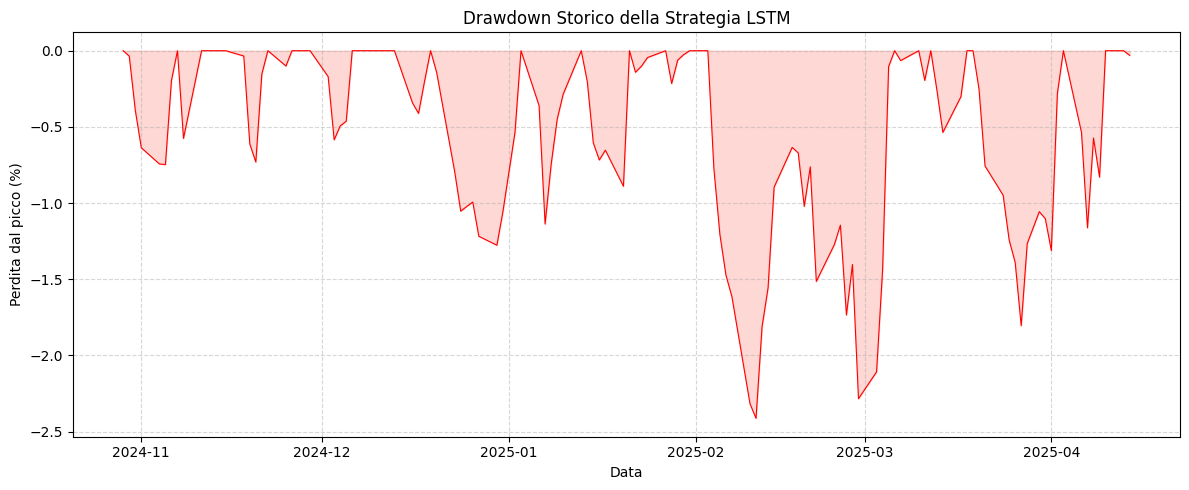

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_metrics_lstm(log_returns, name="Strategia"):
    # Rendimento totale logaritmico convertito in semplice
    total_return = (np.exp(np.sum(log_returns)) - 1) * 100

    # Sharpe Ratio (annualizzato assumendo 252 giorni di trading)
    avg_return = np.mean(log_returns)
    std_return = np.std(log_returns)

    if std_return != 0:
        sharpe = (avg_return / std_return) * np.sqrt(252)
    else:
        sharpe = 0

    # Calcolo del Massimo Drawdown
    cumulative = np.exp(np.cumsum(log_returns))
    peak = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - peak) / np.where(peak == 0, 1, peak)
    max_drawdown = np.min(drawdown) * 100

    return {
        "Rendimento Totale (%)": round(total_return, 2),
        "Sharpe Ratio": round(sharpe, 2),
        "Max Drawdown (%)": round(max_drawdown, 2)
    }

# --- CALCOLO METRICHE PER LSTM ---
# Utilizziamo il dataframe backtest_lstm_df creato precedentemente
metrics_lstm_final = calculate_metrics_lstm(backtest_lstm_df['Ret_LSTM'].fillna(0), "LSTM")
metrics_market_lstm = calculate_metrics_lstm(backtest_lstm_df['Actual_Return'], "Mercato")
metrics_random_lstm = calculate_metrics_lstm(backtest_lstm_df['Ret_Random'].fillna(0), "Casuale")

# Creazione Tabella Riassuntiva
summary_table_lstm = pd.DataFrame([metrics_lstm_final, metrics_market_lstm, metrics_random_lstm],
                                 index=['LSTM (Tuned)', 'Mercato (Benchmark)', 'Casuale (Baseline)'])

print("\n--- TABELLA PERFORMANCE LSTM (LOG-RETURN BASED) ---")
print(summary_table_lstm)

# --- GRAFICO DEL DRAWDOWN LSTM ---
plt.figure(figsize=(12, 5))

cumulative_lstm = np.exp(np.cumsum(backtest_lstm_df['Ret_LSTM'].fillna(0)))
peak_lstm = np.maximum.accumulate(cumulative_lstm)
drawdown_series_lstm = (cumulative_lstm - peak_lstm) / np.where(peak_lstm == 0, 1, peak_lstm)

plt.fill_between(backtest_lstm_df['Date'], drawdown_series_lstm * 100, 0, color='salmon', alpha=0.3)
plt.plot(backtest_lstm_df['Date'], drawdown_series_lstm * 100, color='red', linewidth=0.8)

plt.title('Drawdown Storico della Strategia LSTM', fontsize=12)
plt.ylabel('Perdita dal picco (%)')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


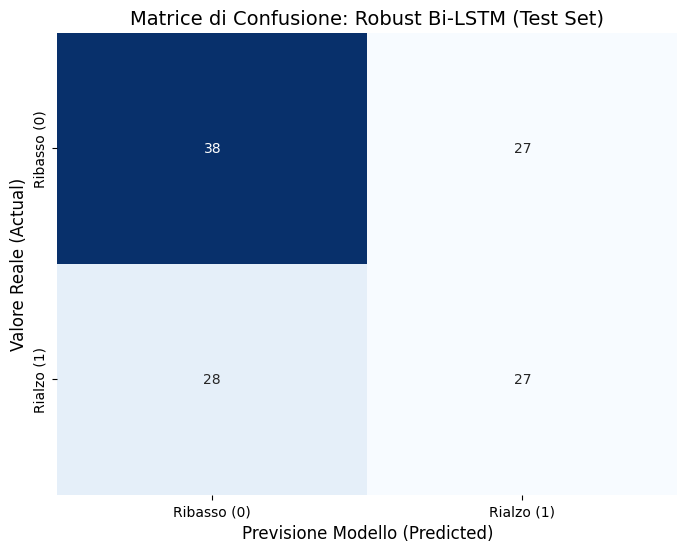


--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

 Ribasso (0)       0.58      0.58      0.58        65
  Rialzo (1)       0.50      0.49      0.50        55

    accuracy                           0.54       120
   macro avg       0.54      0.54      0.54       120
weighted avg       0.54      0.54      0.54       120



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_probs = final_model.predict(X_test_fin)
y_pred = (y_pred_probs > 0.5).astype(int)


cm = confusion_matrix(y_test_fin, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ribasso (0)', 'Rialzo (1)'],
            yticklabels=['Ribasso (0)', 'Rialzo (1)'],
            cbar=False)

plt.xlabel('Previsione Modello (Predicted)', fontsize=12)
plt.ylabel('Valore Reale (Actual)', fontsize=12)
plt.title('Matrice di Confusione: Robust Bi-LSTM (Test Set)', fontsize=14)
plt.show()


print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test_fin, y_pred, target_names=['Ribasso (0)', 'Rialzo (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


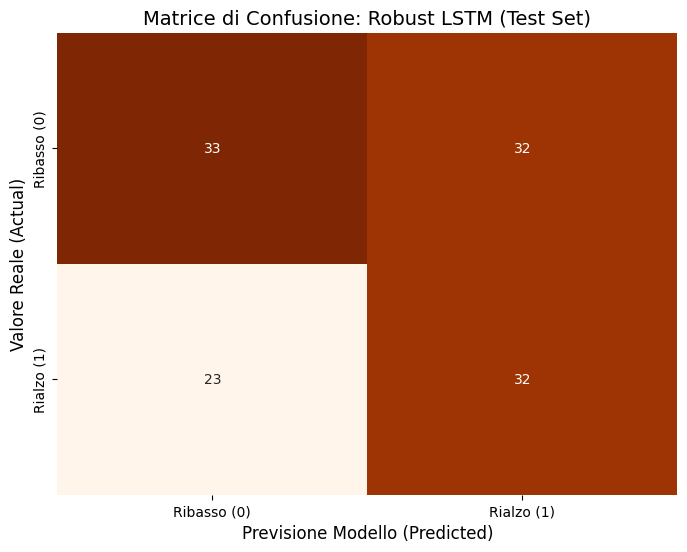


--- REPORT DI CLASSIFICAZIONE LSTM ---
              precision    recall  f1-score   support

 Ribasso (0)       0.59      0.51      0.55        65
  Rialzo (1)       0.50      0.58      0.54        55

    accuracy                           0.54       120
   macro avg       0.54      0.54      0.54       120
weighted avg       0.55      0.54      0.54       120



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcolo delle previsioni per il modello LSTM
# Usiamo la soglia classica dello 0.5 per la classificazione binaria
y_pred_probs_lstm = final_modellstm.predict(X_test_fin_lstm)
y_pred_lstm = (y_pred_probs_lstm > 0.5).astype(int)

# 2. Generazione della Matrice di Confusione
cm_lstm = confusion_matrix(y_test_fin_lstm, y_pred_lstm)

# 3. Visualizzazione Grafica con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges', # Colore diverso per distinguerla dalla Bi-LSTM
            xticklabels=['Ribasso (0)', 'Rialzo (1)'],
            yticklabels=['Ribasso (0)', 'Rialzo (1)'],
            cbar=False)

plt.xlabel('Previsione Modello (Predicted)', fontsize=12)
plt.ylabel('Valore Reale (Actual)', fontsize=12)
plt.title('Matrice di Confusione: Robust LSTM (Test Set)', fontsize=14)
plt.show()

# 4. Report di Classificazione (Precision, Recall, F1-Score)
print("\n--- REPORT DI CLASSIFICAZIONE LSTM ---")
print(classification_report(y_test_fin_lstm, y_pred_lstm, target_names=['Ribasso (0)', 'Rialzo (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
AUC Score: 0.5871
Soglia Ottimale calcolata (Youden): 0.4938


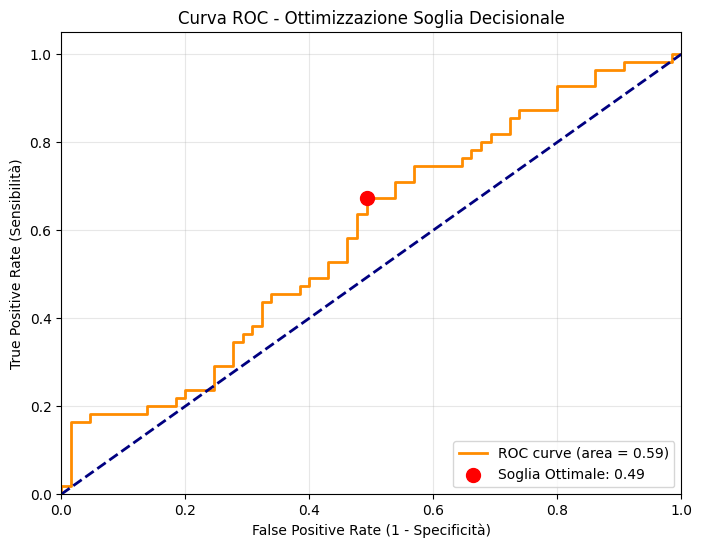

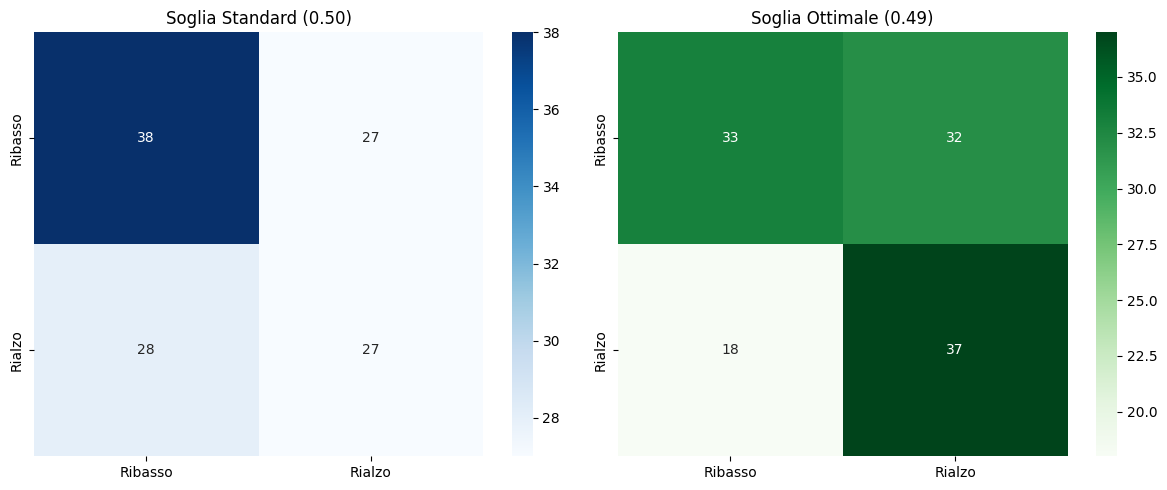


--- REPORT CON SOGLIA OTTIMIZZATA ---
              precision    recall  f1-score   support

 Ribasso (0)       0.65      0.51      0.57        65
  Rialzo (1)       0.54      0.67      0.60        55

    accuracy                           0.58       120
   macro avg       0.59      0.59      0.58       120
weighted avg       0.60      0.58      0.58       120

Brier Score: 0.2469


In [ ]:
from sklearn.metrics import roc_curve, auc, brier_score_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


y_probs = final_model.predict(X_test_fin).ravel()
fpr, tpr, thresholds = roc_curve(y_test_fin, y_probs)
roc_auc = auc(fpr, tpr)


optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"AUC Score: {roc_auc:.4f}")
print(f"Soglia Ottimale calcolata (Youden): {optimal_threshold:.4f}")


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100,
            label=f'Soglia Ottimale: {optimal_threshold:.2f}', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Curva ROC - Ottimizzazione Soglia Decisionale')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


y_pred_std = (y_probs >= 0.5).astype(int)
y_pred_opt = (y_probs >= optimal_threshold).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


sns.heatmap(confusion_matrix(y_test_fin, y_pred_std), annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[0].set_title('Soglia Standard (0.50)')


sns.heatmap(confusion_matrix(y_test_fin, y_pred_opt), annot=True, fmt='d', cmap='Greens', ax=ax[1],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[1].set_title(f'Soglia Ottimale ({optimal_threshold:.2f})')

plt.tight_layout()
plt.show()

print("\n--- REPORT CON SOGLIA OTTIMIZZATA ---")
print(classification_report(y_test_fin, y_pred_opt, target_names=['Ribasso (0)', 'Rialzo (1)']))


bs = brier_score_loss(y_test_fin, y_probs)
print(f"Brier Score: {bs:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
--- METRICHE AVANZATE LSTM ---
AUC Score LSTM: 0.5371
Soglia Ottimale LSTM (Youden): 0.5061


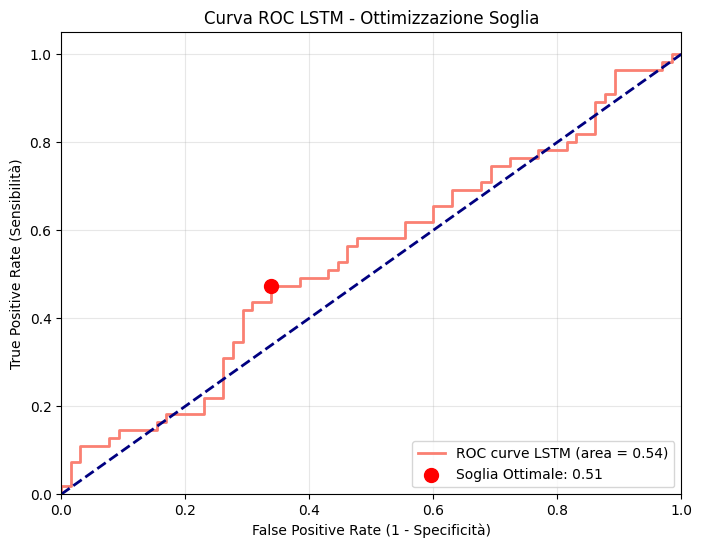

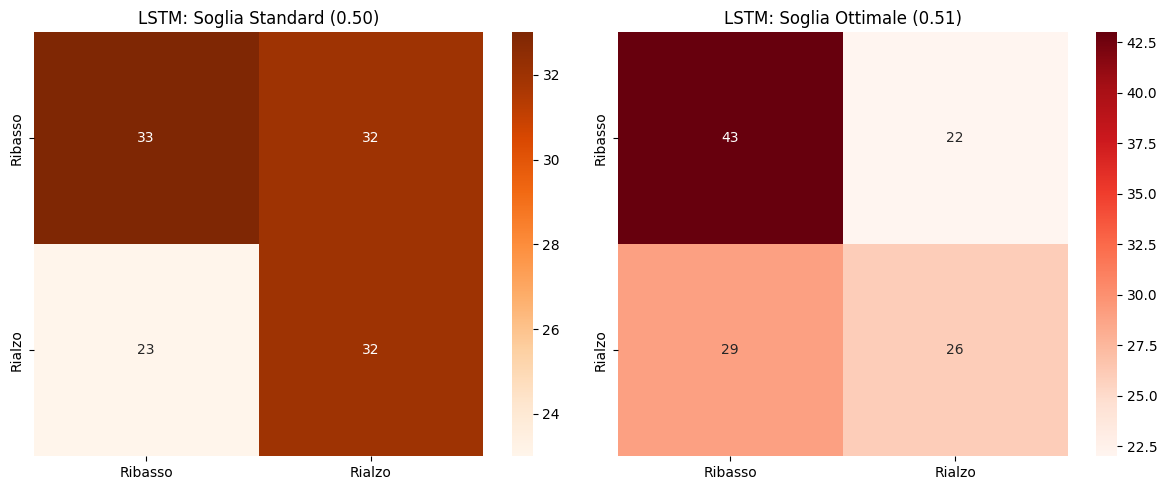


--- REPORT LSTM CON SOGLIA OTTIMIZZATA ---
              precision    recall  f1-score   support

 Ribasso (0)       0.60      0.66      0.63        65
  Rialzo (1)       0.54      0.47      0.50        55

    accuracy                           0.57       120
   macro avg       0.57      0.57      0.57       120
weighted avg       0.57      0.57      0.57       120

Brier Score LSTM: 0.2495


In [ ]:
from sklearn.metrics import roc_curve, auc, brier_score_loss, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calcolo delle probabilità per il modello LSTM
y_probs_lstm = final_modellstm.predict(X_test_fin_lstm).ravel()

# 2. Calcolo della curva ROC e dell'area sottostante (AUC)
fpr_lstm, tpr_lstm, thresholds_lstm = roc_curve(y_test_fin_lstm, y_probs_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# 3. Calcolo della Soglia Ottimale (Indice di Youden: max(TPR - FPR))
optimal_idx_lstm = np.argmax(tpr_lstm - fpr_lstm)
optimal_threshold_lstm = thresholds_lstm[optimal_idx_lstm]

print(f"--- METRICHE AVANZATE LSTM ---")
print(f"AUC Score LSTM: {roc_auc_lstm:.4f}")
print(f"Soglia Ottimale LSTM (Youden): {optimal_threshold_lstm:.4f}")

# 4. Grafico Curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_lstm, tpr_lstm, color='salmon', lw=2, label=f'ROC curve LSTM (area = {roc_auc_lstm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr_lstm[optimal_idx_lstm], tpr_lstm[optimal_idx_lstm], color='red', s=100,
            label=f'Soglia Ottimale: {optimal_threshold_lstm:.2f}', zorder=5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Curva ROC LSTM - Ottimizzazione Soglia')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. Confronto Matrici di Confusione (Standard vs Ottimale)
y_pred_std_lstm = (y_probs_lstm >= 0.5).astype(int)
y_pred_opt_lstm = (y_probs_lstm >= optimal_threshold_lstm).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matrice Standard
sns.heatmap(confusion_matrix(y_test_fin_lstm, y_pred_std_lstm), annot=True, fmt='d', cmap='Oranges', ax=ax[0],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[0].set_title('LSTM: Soglia Standard (0.50)')

# Matrice Ottimizzata
sns.heatmap(confusion_matrix(y_test_fin_lstm, y_pred_opt_lstm), annot=True, fmt='d', cmap='Reds', ax=ax[1],
            xticklabels=['Ribasso', 'Rialzo'], yticklabels=['Ribasso', 'Rialzo'])
ax[1].set_title(f'LSTM: Soglia Ottimale ({optimal_threshold_lstm:.2f})')

plt.tight_layout()
plt.show()

# 6. Report Finale e Brier Score
print("\n--- REPORT LSTM CON SOGLIA OTTIMIZZATA ---")
print(classification_report(y_test_fin_lstm, y_pred_opt_lstm, target_names=['Ribasso (0)', 'Rialzo (1)']))

bs_lstm = brier_score_loss(y_test_fin_lstm, y_probs_lstm)
print(f"Brier Score LSTM: {bs_lstm:.4f}")

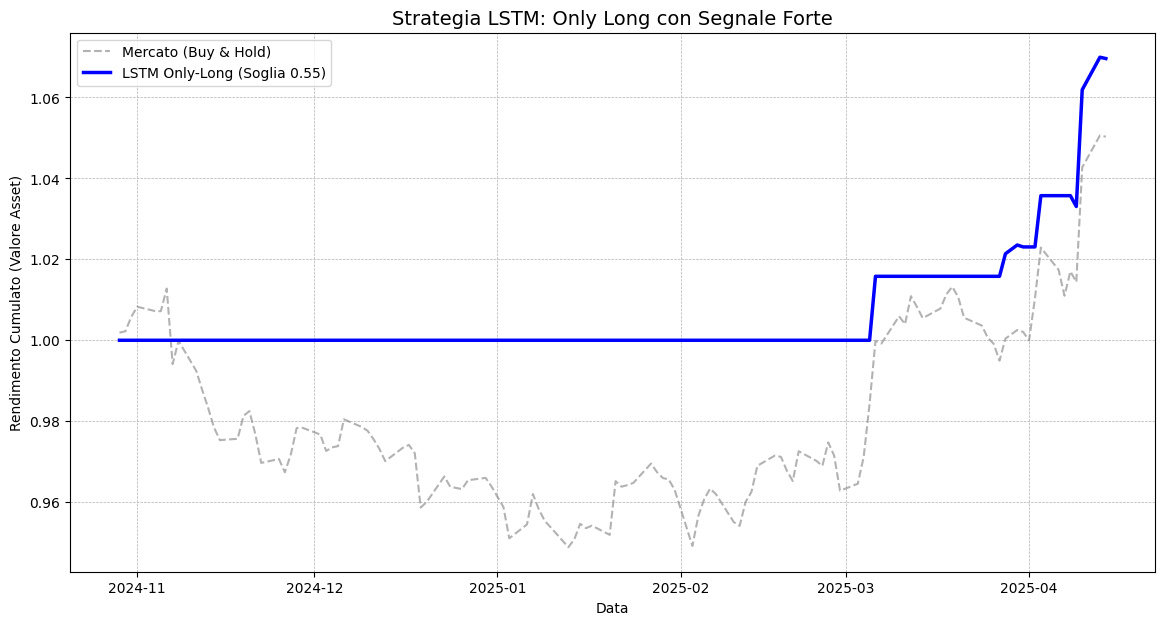

--- RISULTATI ONLY LONG (Soglia 0.55) ---
Rendimento Totale:              6.96%
Sharpe Ratio:                   2.78
Tempo di esposizione al mercato: 8.33%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SOGLIA_STRONG_LONG = 0.55

backtest_long_only_df = pd.DataFrame({
    'Date': test_dates_lstm,
    'Actual_Return': test_returns_lstm,
    'Prob_Up': y_pred_probs_lstm.flatten()
})

backtest_long_only_df['Pos_Long_Only'] = np.where(backtest_long_only_df['Prob_Up'] > SOGLIA_STRONG_LONG, 1, 0)

backtest_long_only_df['Ret_Long_Only'] = backtest_long_only_df['Pos_Long_Only'].shift(1) * backtest_long_only_df['Actual_Return']

backtest_long_only_df['Equity_Market']    = np.exp(backtest_long_only_df['Actual_Return'].cumsum())
backtest_long_only_df['Equity_Long_Only'] = np.exp(backtest_long_only_df['Ret_Long_Only'].fillna(0).cumsum())

plt.figure(figsize=(14, 7))
plt.plot(backtest_long_only_df['Date'], backtest_long_only_df['Equity_Market'],
         label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_long_only_df['Date'], backtest_long_only_df['Equity_Long_Only'],
         label=f'LSTM Only-Long (Soglia {SOGLIA_STRONG_LONG})', color='blue', linewidth=2.5)

plt.title('Strategia LSTM: Only Long con Segnale Forte', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

def calcola_sharpe(returns, periods=252):
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods)

ret_long   = backtest_long_only_df['Ret_Long_Only'].fillna(0)
perf_long  = (backtest_long_only_df['Equity_Long_Only'].iloc[-1] - 1) * 100
sharpe_long = calcola_sharpe(ret_long)
exposure    = (backtest_long_only_df['Pos_Long_Only'] == 1).mean() * 100

print(f"--- RISULTATI ONLY LONG (Soglia {SOGLIA_STRONG_LONG}) ---")
print(f"Rendimento Totale:              {perf_long:.2f}%")
print(f"Sharpe Ratio:                   {sharpe_long:.2f}")
print(f"Tempo di esposizione al mercato: {exposure:.2f}%")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparazione Dati (Assicuriamoci di avere la Sigma nel df)
# Usiamo i dati della LSTM già allineati
backtest_adv_df = backtest_opt_lstm_df.copy()
# Recuperiamo la Sigma dai dati di test originali (allineata)
backtest_adv_df['Sigma'] = test_final_lstm['Sigma'].iloc[window_size_lstm:].values

# --- FUNZIONE DI STRATEGIA AVANZATA ---
def advanced_long_only_logic(probs, sigma, s_enter, s_exit, vol_limit):
    pos = 0
    positions = []
    for p, s in zip(probs, sigma):
        # Filtro Volatilità: Se il mercato è troppo nervoso, restiamo flat
        if s > vol_limit:
            pos = 0
        else:
            # Logica Isteresi (Entrata ed Uscita differenziate)
            if pos == 0 and p > s_enter:
                pos = 1  # Entra Long
            elif pos == 1 and p < s_exit:
                pos = 0  # Esci dalla posizione
        positions.append(pos)
    return positions

# --- OTTIMIZZAZIONE SOGLIE ---
best_sharpe = -1
results = []

# Testiamo diverse combinazioni
# s_enter: quanto deve essere forte il segnale per entrare
# vol_limit: limite massimo di volatilità ammessa
for s_enter in np.linspace(0.51, 0.56, 10):
    for vol_limit in np.linspace(backtest_adv_df['Sigma'].mean(), backtest_adv_df['Sigma'].max(), 5):

        # Applichiamo la logica (s_exit fissata a 0.50 per mantenere il trend)
        posizioni = advanced_long_only_logic(backtest_adv_df['Prob_Up'],
                                             backtest_adv_df['Sigma'],
                                             s_enter, 0.50, vol_limit)

        # Calcolo Rendimenti
        ret = np.array(posizioni[:-1]) * backtest_adv_df['Actual_Return'].values[1:]

        # Calcolo Sharpe
        if np.std(ret) > 0:
            sharpe = (np.mean(ret) / np.std(ret)) * np.sqrt(252)
        else:
            sharpe = 0

        results.append((s_enter, vol_limit, sharpe))

        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_params_adv = (s_enter, vol_limit)

# --- APPLICAZIONE DEI MIGLIORI PARAMETRI TROVATI ---
s_opt, vol_opt = best_params_adv
print(f"Parametri Ottimali: Entrata > {s_opt:.3f}, Volatilità Max < {vol_opt:.5f}")

backtest_adv_df['Pos_Final'] = advanced_long_only_logic(backtest_adv_df['Prob_Up'],
                                                       backtest_adv_df['Sigma'],
                                                       s_opt, 0.50, vol_opt)

backtest_adv_df['Ret_Final'] = backtest_adv_df['Pos_Final'].shift(1) * backtest_adv_df['Actual_Return']
backtest_adv_df['Equity_Final'] = np.exp(backtest_adv_df['Ret_Final'].fillna(0).cumsum())

# --- VISUALIZZAZIONE ---
plt.figure(figsize=(14, 7))
plt.plot(backtest_adv_df['Date'], backtest_adv_df['Equity_Market'], label='Mercato', color='gray', alpha=0.4)
plt.plot(backtest_adv_df['Date'], backtest_adv_df['Equity_Final'], label='LSTM Adv (Optimized)', color='darkblue', linewidth=2.5)
plt.title(f'Strategia Ottimizzata: Soglia {s_opt:.3f} + Filtro Volatilità', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

final_perf, final_sharpe = quick_metrics(backtest_adv_df['Ret_Final'].fillna(0))
print(f"Rendimento Totale: {final_perf:.2f}%")
print(f"Sharpe Ratio finale: {final_sharpe:.2f}")

In [ ]:
_>...................def analyze_trades(df_backtest, name="Strategia"):

    trades = df_backtest['Pos_BiLSTM'].diff().abs().fillna(0).sum() / 2 # /2 perché un cambio +1 a -1 è un'operazione completa


    total_switches = df_backtest['Pos_BiLSTM'].diff().iloc[1:].ne(0).sum()

    print(f"--- Analisi Operatività: {name} ---")
    print(f"Numero totale di inversioni di rotta (Trade): {total_switches}")
    print(f"Media operazioni a settimana: {round(total_switches / (len(df_backtest)/5), 2)}")
    print(f"Permanenza media in una posizione (giorni): {round(len(df_backtest) / (total_switches + 1), 2)}")
    print("-" * 40)
    return total_switches


switches_050 = analyze_trades(backtest_df, "Soglia 0.50 (Standard)")


switches_040 = analyze_trades(backtest_opt_df, "Soglia 0.40 (Ottimizzata)")


diff = switches_040 - switches_050
print(f"\nRisultato: La soglia 0.40 effettua {diff} operazioni in {'più' if diff > 0 else 'meno'} rispetto alla soglia 0.50.")

--- Analisi Operatività: Soglia 0.50 (Standard) ---
Numero totale di inversioni di rotta (Trade): 14
Media operazioni a settimana: 0.58
Permanenza media in una posizione (giorni): 8.0
----------------------------------------
--- Analisi Operatività: Soglia 0.40 (Ottimizzata) ---
Numero totale di inversioni di rotta (Trade): 12
Media operazioni a settimana: 0.5
Permanenza media in una posizione (giorni): 9.23
----------------------------------------

Risultato: La soglia 0.40 effettua -2 operazioni in meno rispetto alla soglia 0.50.


Ultimo Prezzo agganciato (Reale al 15/04/2025): 1.129267
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


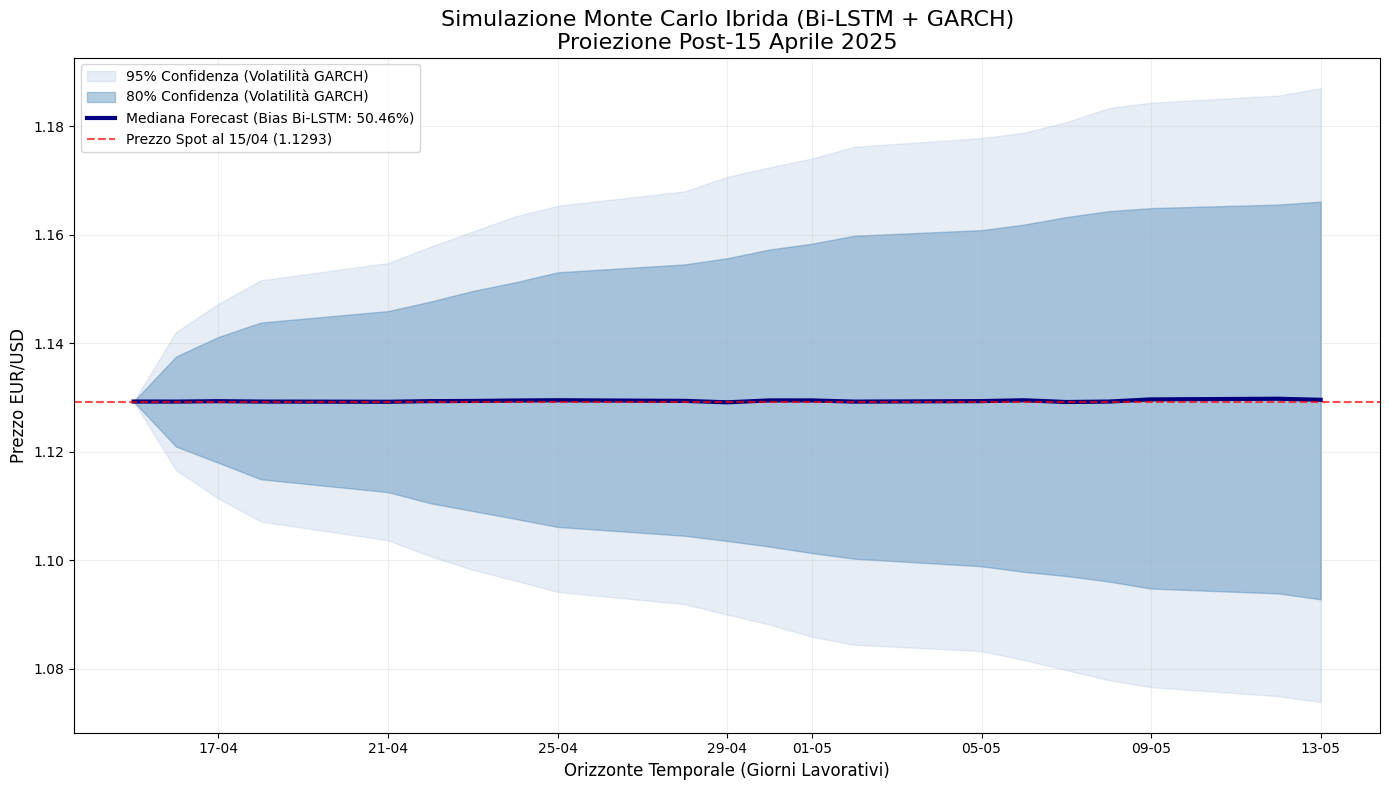

--- RISULTATI ANALISI ---
Probabilità prevista Bi-LSTM per il 16/04: 0.5046
Direzione suggerita: Rialzista
Volatilità attesa (Sigma): 0.005712


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


N_SCENARI = 10000
N_GIORNI_FUTURI = 20
np.random.seed(42)


dati_15_aprile = {
    'Date': pd.to_datetime('2025-04-15'),
    'Prezzo': 1.129267,
    'Sigma': 0.005711679,
    'sent_EUR': 0.02373299,
    'sent_USD': -0.01144999,
    'Log_Return': -0.004152990 # log(1.129267 / 1.133967)
}


df_previsione = df.copy()

df_previsione = pd.concat([df_previsione, pd.DataFrame([dati_15_aprile])], ignore_index=True)


LATEST_PRICE = dati_15_aprile['Prezzo']
LAST_DATE = dati_15_aprile['Date']

print(f"Ultimo Prezzo agganciato (Reale al {LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")


latest_data_idx = -best_params['window_size']
latest_raw_data = df_previsione[features].iloc[latest_data_idx:].values


latest_scaled_data = final_scaler.transform(latest_raw_data)
latest_sequence = latest_scaled_data.reshape(1, best_params['window_size'], len(features))


predicted_prob = final_model.predict(latest_sequence)[0][0]


latest_sigma = dati_15_aprile['Sigma']


random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))


predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift


simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)


final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])


median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)


future_dates = pd.date_range(start=LAST_DATE, periods=N_GIORNI_FUTURI + 1, freq='B')

plt.figure(figsize=(14, 8))


plt.fill_between(future_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.3, label='95% Confidenza (Volatilità GARCH)')
plt.fill_between(future_dates, lower_80, upper_80, color='#4682B4', alpha=0.4, label='80% Confidenza (Volatilità GARCH)')


plt.plot(future_dates, median_forecast, color='#000080', linewidth=3,
         label=f'Mediana Forecast (Bias Bi-LSTM: {predicted_prob:.2%})')


plt.axhline(y=LATEST_PRICE, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Prezzo Spot al 15/04 ({LATEST_PRICE:.4f})')

plt.title(f'Simulazione Monte Carlo Ibrida (Bi-LSTM + GARCH)\nProiezione Post-15 Aprile 2025', fontsize=16)
plt.ylabel('Prezzo EUR/USD', fontsize=12)
plt.xlabel('Orizzonte Temporale (Giorni Lavorativi)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- RISULTATI ANALISI ---")
print(f"Probabilità prevista Bi-LSTM per il 16/04: {predicted_prob:.4f}")
print(f"Direzione suggerita: {'Rialzista' if predicted_prob > 0.5 else 'Ribassista'}")
print(f"Volatilità attesa (Sigma): {latest_sigma:.6f}")

/tmp/ipykernel_8059/3308392875.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)
[*********************100%***********************]  1 of 1 completed


Punto di aggancio reale (15/04/2025): 1.129267


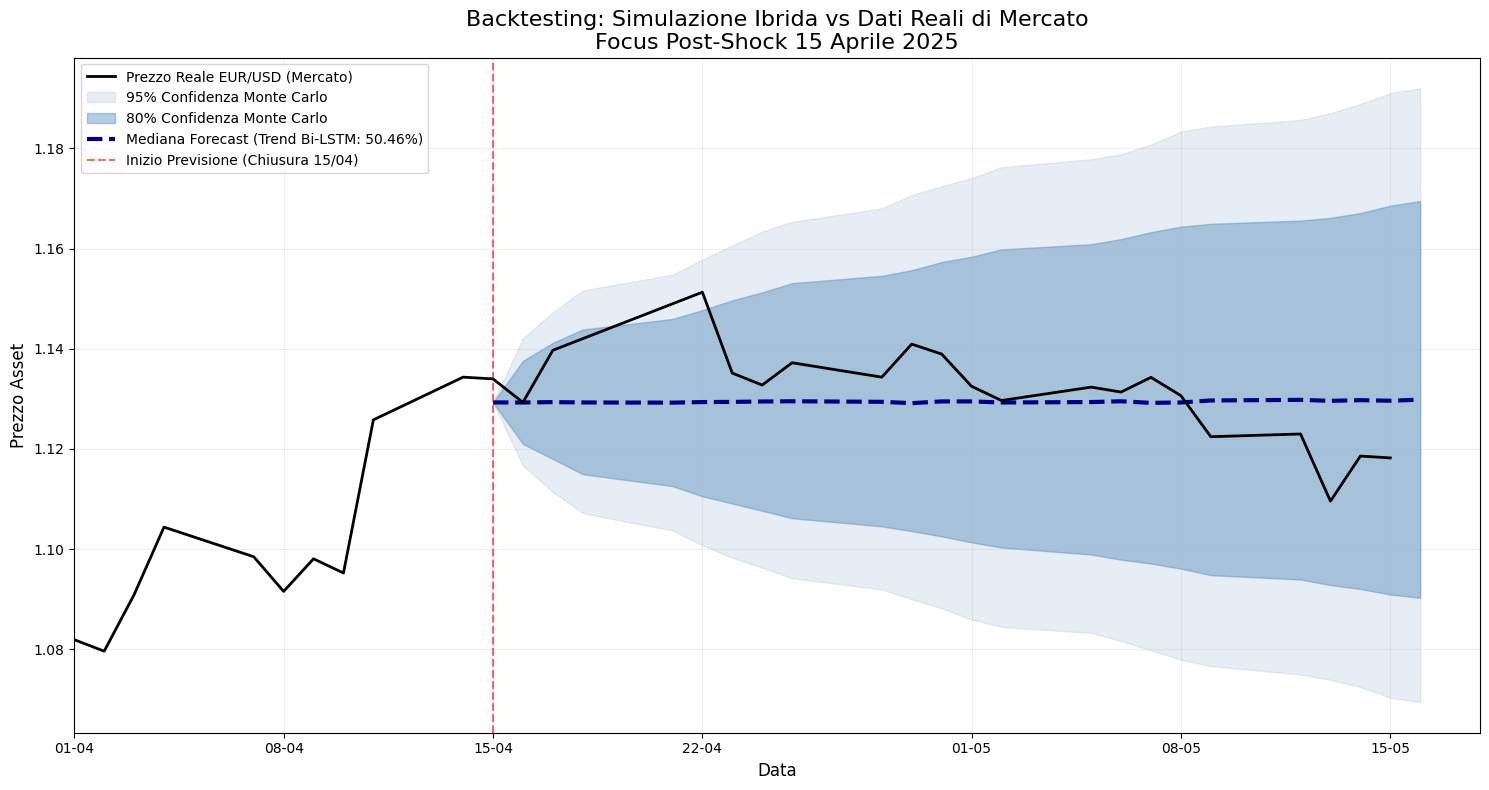

--- REPORT BACKTESTING ---
Probabilità Bi-LSTM (Input 15/04): 0.5046
Prezzo iniziale (15/04): 1.129267
Orizzonte simulato: 23 giorni lavorativi


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf


LAST_HISTORICAL_DATE = "2025-04-15"
START_FORECAST = "2025-04-16"
END_FORECAST = "2025-05-16"


ticker = "EURUSD=X"

real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)

if isinstance(real_data.columns, pd.MultiIndex):
    real_data.columns = real_data.columns.get_level_values(0)


LATEST_PRICE = 1.129267
LAST_DATE = pd.to_datetime(LAST_HISTORICAL_DATE)

print(f"Punto di aggancio reale ({LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")


N_SCENARI = 10000
np.random.seed(42)


latest_sigma = 0.005711679
predicted_prob = 0.5046


future_dates = pd.date_range(start=START_FORECAST, end=END_FORECAST, freq='B')
N_GIORNI_FUTURI = len(future_dates)


random_returns = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))


predicted_drift_intensity = (predicted_prob - 0.5) * 2
avg_historical_drift = 0.0005
adjusted_drift = predicted_drift_intensity * avg_historical_drift


simulated_log_returns = random_returns + adjusted_drift
cumulative_log_returns = simulated_log_returns.cumsum(axis=0)
simulated_prices = LATEST_PRICE * np.exp(cumulative_log_returns)


final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])

plot_dates = [LAST_DATE] + list(future_dates)


median_forecast = np.median(final_sim_prices, axis=1)
lower_80 = np.percentile(final_sim_prices, 10, axis=1)
upper_80 = np.percentile(final_sim_prices, 90, axis=1)
lower_95 = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95 = np.percentile(final_sim_prices, 97.5, axis=1)


plt.figure(figsize=(15, 8))


plt.plot(real_data.index, real_data['Close'], color='black', linewidth=2, label='Prezzo Reale EUR/USD (Mercato)', zorder=5)


plt.fill_between(plot_dates, lower_95, upper_95, color='#B0C4DE', alpha=0.3, label='95% Confidenza Monte Carlo')
plt.fill_between(plot_dates, lower_80, upper_80, color='#4682B4', alpha=0.4, label='80% Confidenza Monte Carlo')


plt.plot(plot_dates, median_forecast, color='#000080', linewidth=3, linestyle='--',
         label=f'Mediana Forecast (Trend Bi-LSTM: {predicted_prob:.2%})')


plt.axvline(x=LAST_DATE, color='red', linestyle='--', alpha=0.6, label='Inizio Previsione (Chiusura 15/04)')

plt.title(f'Backtesting: Simulazione Ibrida vs Dati Reali di Mercato\nFocus Post-Shock 15 Aprile 2025', fontsize=16)
plt.ylabel('Prezzo Asset', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')


plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime(END_FORECAST) + pd.Timedelta(days=2))

plt.tight_layout()
plt.show()

print(f"--- REPORT BACKTESTING ---")
print(f"Probabilità Bi-LSTM (Input 15/04): {predicted_prob:.4f}")
print(f"Prezzo iniziale (15/04): {LATEST_PRICE}")
print(f"Orizzonte simulato: {N_GIORNI_FUTURI} giorni lavorativi")

In [ ]:
print(df.tail(1))

          Date    Prezzo     Sigma  Realized  sent_EUR  sent_USD  Log_Return  \
646 2025-04-14  1.133967  0.005861 -0.000306 -0.407379 -0.537141   -0.000306   

     Target  
646       0  


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional # Aggiunto Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# Caricamento dati
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

features = ['Log_Return', 'Sigma', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# SPLIT 70/30 — il test non viene mai toccato fino alla fine
# ----------------------------------------------------------------
split_idx = int(len(df) * 0.70)
df_trainval = df.iloc[:split_idx].reset_index(drop=True)
df_test     = df.iloc[split_idx:].reset_index(drop=True)

print(f"Dati train+val: {len(df_trainval)} giorni")
print(f"Dati test OOS:  {len(df_test)} giorni")

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

param_grid = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials = 6
tscv = TimeSeriesSplit(n_splits=3)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params = {}

print(f"\nInizio Robust Tuning su {len(param_list)} combinazioni (BiLSTM, CV su trainval)...")

for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_trainval):
        train_fold = df_trainval.iloc[train_idx]
        val_fold   = df_trainval.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])
        val_scaled   = scaler.transform(val_fold[features])

        X_tr, y_tr   = create_sequences(train_scaled, train_fold[target_col].values, current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled,   val_fold[target_col].values,   current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        # --- MODELLO BiLSTM ---
        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            Bidirectional(LSTM(current_params['lstm_units'], return_sequences=True)),
            Dropout(current_params['dropout_rate']),
            Bidirectional(LSTM(int(current_params['lstm_units'] / 2))),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        model.fit(X_tr, y_tr,
                  epochs=50,
                  batch_size=current_params['batch_size'],
                  validation_data=(X_val, y_val),
                  callbacks=[
                      EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
                  ],
                  verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI ---\n{best_params}")

# ----------------------------------------------------------------
# TRAINING FINALE — Solo su df_trainval
# ----------------------------------------------------------------

final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(df_trainval[features])
X_test_scaled     = final_scaler.transform(df_test[features])

X_trainval_seq, y_trainval_seq = create_sequences(X_trainval_scaled, df_trainval[target_col].values, best_params['window_size'])
X_test_seq, y_test_seq = create_sequences(X_test_scaled, df_test[target_col].values, best_params['window_size'])

# Validazione interna per EarlyStopping (10% finale di trainval)
val_size = int(len(X_trainval_seq) * 0.10)
X_tr_es  = X_trainval_seq[:-val_size]
y_tr_es  = y_trainval_seq[:-val_size]
X_val_es = X_trainval_seq[-val_size:]
y_val_es = y_trainval_seq[-val_size:]

# Modello finale BiLSTM
tf.keras.backend.clear_session()
set_reproducibility(42)

final_model_bilstm = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    Bidirectional(LSTM(int(best_params['lstm_units'] / 2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model_bilstm.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining finale in corso (BiLSTM)...")
final_model_bilstm.fit(
    X_tr_es, y_tr_es,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_es, y_val_es),
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
    verbose=1
)

loss, accuracy = final_model_bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET (OOS): {accuracy:.4f}")

Dati train+val: 1388 giorni
Dati test OOS:  595 giorni

Inizio Robust Tuning su 6 combinazioni (BiLSTM, CV su trainval)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.4985, Std: 0.0106, Score: 0.4774
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.4954, Std: 0.0198, Score: 0.4558
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5005, Std: 0.0104, Score: 0.4797
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5005, Std: 0.0028, Score: 0.4949
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5066, Std: 0.0052, Score: 0.4962
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.

In [ ]:
# ----------------------------------------------------------------
# TRAINING FINALE — solo su df_trainval, test mai toccato
# ----------------------------------------------------------------

# Scaler fittato solo sul trainval (già separato dal test all'inizio)
final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(df_trainval[features])
X_test_scaled     = final_scaler.transform(df_test[features])  # transform, non fit

# Creazione sequenze per trainval e test finale
X_trainval_seq, y_trainval_seq = create_sequences(
    X_trainval_scaled,
    df_trainval[target_col].values,
    best_params['window_size']
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    df_test[target_col].values,
    best_params['window_size']
)

# Validation interna per EarlyStopping — ultimi 10% del trainval
# In questo modo il test OOS rimane "vergine" e non influenza il training
val_size = int(len(X_trainval_seq) * 0.10)
X_tr_es  = X_trainval_seq[:-val_size]
y_tr_es  = y_trainval_seq[:-val_size]
X_val_es = X_trainval_seq[-val_size:]
y_val_es = y_trainval_seq[-val_size:]

print(f"Dati per training:   {len(X_tr_es)}")
print(f"Dati per EarlyStopping (val interna): {len(X_val_es)}")
print(f"Dati per test OOS:   {len(X_test_seq)}")

# Modello finale BiLSTM
tf.keras.backend.clear_session()
set_reproducibility(42)

final_model_bilstm = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    # Primo layer BiLSTM
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    # Secondo layer BiLSTM
    Bidirectional(LSTM(int(best_params['lstm_units'] / 2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model_bilstm.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining finale in corso (BiLSTM)...")
history = final_model_bilstm.fit(
    X_tr_es, y_tr_es,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_es, y_val_es),
    callbacks=[
        # Monitoriamo la val_loss interna per decidere quando fermarci
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=1
)

# Valutazione finale sul test set OOS (completamente fuori dal processo di training)
loss_test, acc_test = final_model_bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)

print("-" * 30)
print(f"RISULTATI FINALI (BiLSTM):")
print(f"Accuracy sul Training: {history.history['accuracy'][-1]:.4f}")
print(f"Accuracy sulla Val Interna: {history.history['val_accuracy'][-1]:.4f}")
print(f"ACCURACY SUL TEST SET OOS (VERO): {acc_test:.4f}")
print("-" * 30)

Dati per training:   1232
Dati per EarlyStopping (val interna): 136
Dati per test OOS:   575

Training finale in corso (BiLSTM)...
Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.5041 - loss: 0.6937 - val_accuracy: 0.5147 - val_loss: 0.6935 - learning_rate: 5.0000e-04
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5294 - val_loss: 0.6932 - learning_rate: 5.0000e-04
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5065 - loss: 0.6916 - val_accuracy: 0.5074 - val_loss: 0.6923 - learning_rate: 5.0000e-04
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5244 - loss: 0.6919 - val_accuracy: 0.5221 - val_loss: 0.6917 - learning_rate: 5.0000e-04
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5081 - loss: 0.6931 - val_accuracy: 0.5368 - val_loss: 0.6912 - learning_rate: 5.0000e-04
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5219 - loss: 0.6899 - 

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_reproducibility(42)

# ----------------------------------------------------------------
# CARICAMENTO E FILTRO DATI (DAL 2023 IN POI)
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Filtro netto: solo dati dal 2023 in poi
df = df[df['Date'] >= '2023-01-01'].copy()

df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dati totali dal 2023: {len(df)} giorni")

features = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# SPLIT 70/30
# ----------------------------------------------------------------
split_idx = int(len(df) * 0.70)
df_trainval = df.iloc[:split_idx].reset_index(drop=True)
df_test     = df.iloc[split_idx:].reset_index(drop=True)

print(f"Dati train+val: {len(df_trainval)} giorni")
print(f"Dati test OOS:  {len(df_test)} giorni")

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# ----------------------------------------------------------------
# TUNING PARAMETRI
# ----------------------------------------------------------------
param_grid = {
    'window_size': [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units': [32, 64],
    'dropout_rate': [0.3, 0.4],
    'batch_size': [32]
}

num_trials = 6
tscv = TimeSeriesSplit(n_splits=3)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params = {}

print(f"\nInizio Robust Tuning su {len(param_list)} combinazioni (BiLSTM, CV su dati post-2023)...")

for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_trainval):
        train_fold = df_trainval.iloc[train_idx]
        val_fold   = df_trainval.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])
        val_scaled   = scaler.transform(val_fold[features])

        X_tr, y_tr   = create_sequences(train_scaled, train_fold[target_col].values, current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled,   val_fold[target_col].values,   current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        # Modello BiLSTM
        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            Bidirectional(LSTM(current_params['lstm_units'], return_sequences=True)),
            Dropout(current_params['dropout_rate']),
            Bidirectional(LSTM(int(current_params['lstm_units'] / 2))),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(optimizer=Adam(learning_rate=current_params['learning_rate']),
                      loss='binary_crossentropy', metrics=['accuracy'])

        model.fit(X_tr, y_tr,
                  epochs=50,
                  batch_size=current_params['batch_size'],
                  validation_data=(X_val, y_val),
                  callbacks=[
                      EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
                      ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
                  ],
                  verbose=0)

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> Avg Acc: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params = current_params

print(f"\n--- MIGLIORI PARAMETRI TROVATI ---\n{best_params}")

# ----------------------------------------------------------------
# TRAINING FINALE
# ----------------------------------------------------------------
final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(df_trainval[features])
X_test_scaled     = final_scaler.transform(df_test[features])

X_trainval_seq, y_trainval_seq = create_sequences(X_trainval_scaled, df_trainval[target_col].values, best_params['window_size'])
X_test_seq, y_test_seq = create_sequences(X_test_scaled, df_test[target_col].values, best_params['window_size'])

val_size = int(len(X_trainval_seq) * 0.10)
X_tr_es  = X_trainval_seq[:-val_size]
y_tr_es  = y_trainval_seq[:-val_size]
X_val_es = X_trainval_seq[-val_size:]
y_val_es = y_trainval_seq[-val_size:]

tf.keras.backend.clear_session()
set_reproducibility(42)

final_model_bilstm = Sequential([
    Input(shape=(best_params['window_size'], len(features))),
    Bidirectional(LSTM(best_params['lstm_units'], return_sequences=True)),
    Dropout(best_params['dropout_rate']),
    Bidirectional(LSTM(int(best_params['lstm_units'] / 2))),
    Dropout(best_params['dropout_rate']),
    Dense(1, activation='sigmoid')
])

final_model_bilstm.compile(
    optimizer=Adam(learning_rate=best_params['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nTraining finale in corso (BiLSTM su dati 2023-2024)...")
final_model_bilstm.fit(
    X_tr_es, y_tr_es,
    epochs=100,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_es, y_val_es),
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)],
    verbose=1
)

loss, accuracy = final_model_bilstm.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"\nACCURACY FINALE SUL TEST SET (OOS Post-2023): {accuracy:.4f}")

Dati totali dal 2023: 594 giorni
Dati train+val: 415 giorni
Dati test OOS:  179 giorni

Inizio Robust Tuning su 6 combinazioni (BiLSTM, CV su dati post-2023)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5090, Std: 0.0221, Score: 0.4648
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5060, Std: 0.0197, Score: 0.4667
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg Acc: 0.5221, Std: 0.0114, Score: 0.4994
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5161, Std: 0.0088, Score: 0.4986
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg Acc: 0.5100, Std: 0.0301, Score: 0.4499
Trial 6: {'window_size': 20, 'lstm_units': 64, 'lea

Inizio Rolling Walk-Forward dal 2023 | Fold totali: 11
Fold 1/11 | Fine Test: 2020-03-05 | Accuracy: 0.4524
Fold 2/11 | Fine Test: 2020-08-27 | Accuracy: 0.6111


Fold 3/11 | Fine Test: 2021-02-23 | Accuracy: 0.5397
Fold 4/11 | Fine Test: 2021-08-17 | Accuracy: 0.4841
Fold 5/11 | Fine Test: 2022-02-14 | Accuracy: 0.5079
Fold 6/11 | Fine Test: 2022-08-08 | Accuracy: 0.3889
Fold 7/11 | Fine Test: 2023-02-01 | Accuracy: 0.5556
Fold 8/11 | Fine Test: 2023-07-26 | Accuracy: 0.4683
Fold 9/11 | Fine Test: 2024-01-22 | Accuracy: 0.5238
Fold 10/11 | Fine Test: 2024-07-15 | Accuracy: 0.5079
Fold 11/11 | Fine Test: 2025-01-10 | Accuracy: 0.5000

RISULTATI ROLLING WALK-FORWARD
Accuracy Media Fold: 0.5036
Accuracy Globale OOS: 0.5040


ValueError: x and y must have same first dimension, but have shapes (1385,) and (1384,)

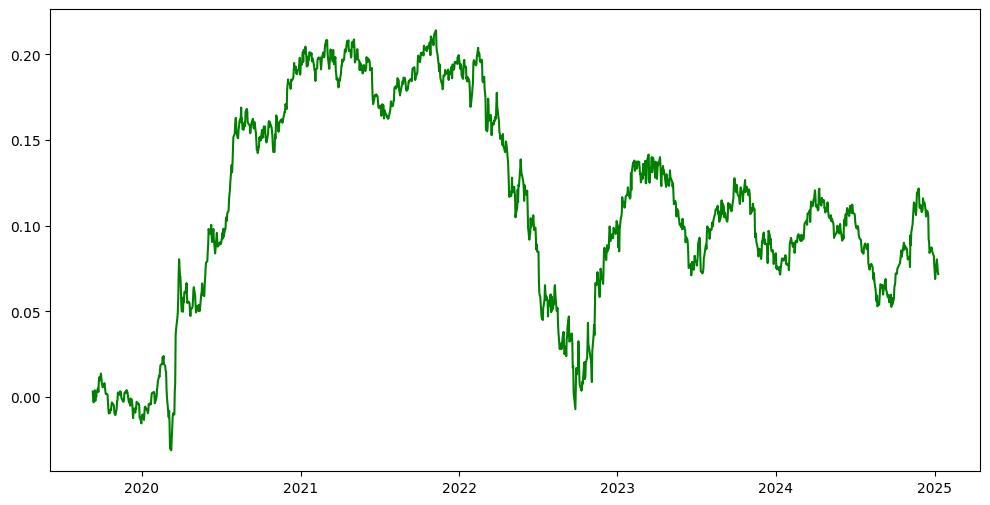

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Filtro 2023
df = df[df['Date'] >= '2019-01-01'].reset_index(drop=True)

# Usiamo i migliori parametri medi trovati dal tuo tuning statico
BEST_PARAMS = {
    'window_size': 20,
    'learning_rate': 0.0005,
    'lstm_units': 64,
    'dropout_rate': 0.4,
    'batch_size': 32
}

features = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# CONFIGURAZIONE ROLLING ROBUSTA
# ----------------------------------------------------------------
# Per avere "abbastanza dati", partiamo con 9 mesi di training (circa 180gg)
# e testiamo su blocchi di 6 mesi (126gg) per avere significatività statistica.
MIN_TRAIN_SIZE = 180
TEST_SIZE      = 126

n_folds = (len(df) - MIN_TRAIN_SIZE) // TEST_SIZE
if n_folds < 1: n_folds = 1

print(f"Inizio Rolling Walk-Forward dal 2023 | Fold totali: {n_folds}")

results_list = []
fold_accuracies = []

for fold in range(n_folds):
    # Finestra ESPANSIVA: il training parte sempre dall'inizio del 2023
    train_end  = MIN_TRAIN_SIZE + (fold * TEST_SIZE)
    test_start = train_end
    test_end   = test_start + TEST_SIZE

    if test_end > len(df): test_end = len(df)
    if test_start >= len(df) - 5: break

    train_fold = df.iloc[:train_end].copy()
    test_fold  = df.iloc[test_start:test_end].copy()

    # Scaling (Fit solo su train per evitare leakage)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_fold[features])

    # Context per non rompere le sequenze tra train e test
    context = train_fold.iloc[-BEST_PARAMS['window_size']:].copy()
    test_with_context = pd.concat([context, test_fold], ignore_index=True)
    test_scaled = scaler.transform(test_with_context[features])

    X_tr, y_tr = create_sequences(train_scaled, train_fold[target_col].values, BEST_PARAMS['window_size'])
    X_te, y_te = create_sequences(test_scaled, test_with_context[target_col].values, BEST_PARAMS['window_size'])

    # Validazione interna (ultimo 15% del training attuale)
    val_split = max(1, int(len(X_tr) * 0.15))
    X_tr_f, y_tr_f = X_tr[:-val_split], y_tr[:-val_split]
    X_val, y_val   = X_tr[-val_split:], y_tr[-val_split:]

    tf.keras.backend.clear_session()
    set_reproducibility(42 + fold)

    # Architettura BiLSTM (la stessa che ti ha dato 0.54)
    model = Sequential([
        Input(shape=(BEST_PARAMS['window_size'], len(features))),
        Bidirectional(LSTM(BEST_PARAMS['lstm_units'], return_sequences=True)),
        Dropout(BEST_PARAMS['dropout_rate']),
        Bidirectional(LSTM(int(BEST_PARAMS['lstm_units'] / 2))),
        Dropout(BEST_PARAMS['dropout_rate']),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(BEST_PARAMS['learning_rate']),
                  loss='binary_crossentropy', metrics=['accuracy'])

    # Callback per evitare overfitting durante la rolling
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6)
    ]

    model.fit(X_tr_f, y_tr_f, epochs=100, batch_size=BEST_PARAMS['batch_size'],
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)

    # Predizioni Out-Of-Sample
    proba = model.predict(X_te, verbose=0).flatten()
    preds = (proba >= 0.5).astype(int)

    fold_acc = (preds == y_te).mean()
    fold_accuracies.append(fold_acc)

    print(f"Fold {fold+1}/{n_folds} | Fine Test: {test_fold['Date'].max().date()} | Accuracy: {fold_acc:.4f}")

    results_list.append(pd.DataFrame({
        'Date': test_fold['Date'].values,
        'True': y_te,
        'Pred': preds,
        'Log_Return': test_fold['Log_Return'].values
    }))

# ----------------------------------------------------------------
# BACKTEST E PERFORMANCE
# ----------------------------------------------------------------
if results_list:
    full_results = pd.concat(results_list).reset_index(drop=True)
    full_results['Strategy_Return'] = np.where(full_results['Pred'] == 1,
                                                full_results['Log_Return'].shift(-1),
                                               -full_results['Log_Return'].shift(-1))
    full_results.dropna(inplace=True)

    print("\n" + "="*40)
    print(f"RISULTATI ROLLING WALK-FORWARD")
    print(f"Accuracy Media Fold: {np.mean(fold_accuracies):.4f}")
    print(f"Accuracy Globale OOS: {(full_results['Pred'] == full_results['True']).mean():.4f}")
    print("="*40)

    plt.figure(figsize=(12, 6))
    plt.plot(full_results['Date'], full_results['Strategy_Return'].cumsum(), label='BiLSTM Rolling Strategy', color='green')
    plt.plot(full_results['Date'], full_results['Log_Return'].shift(-1).dropna().cumsum(), label='Market (Benchmark)', color='red', alpha=0.5)
    plt.title('Rolling Walk-Forward dal 2023 (Folds 6 mesi)')
    plt.legend()
    plt.grid(True)
    plt.show()


PERIODO: dal_2019 (dal 2019-01-01)
  Fold 1: Acc=0.4524 | LogRet=50.0% | Sigma=37.5% | EUR=0.0% | USD=12.5%
  Fold 2: Acc=0.5714 | LogRet=0.0% | Sigma=66.7% | EUR=20.0% | USD=13.3%
  Fold 3: Acc=0.5317 | LogRet=66.7% | Sigma=0.0% | EUR=0.0% | USD=33.3%
  Fold 4: Acc=0.4921 | LogRet=38.6% | Sigma=12.3% | EUR=7.0% | USD=42.1%
  Fold 5: Acc=0.5635 | LogRet=32.6% | Sigma=4.3% | EUR=26.2% | USD=36.9%
  Fold 6: Acc=0.4048 | LogRet=8.7% | Sigma=0.0% | EUR=34.8% | USD=56.5%
  Fold 7: Acc=0.5397 | LogRet=100.0% | Sigma=0.0% | EUR=0.0% | USD=0.0%
  Fold 8: Acc=0.4762 | LogRet=11.0% | Sigma=0.0% | EUR=79.3% | USD=9.8%
  Fold 9: Acc=0.4921 | LogRet=78.3% | Sigma=2.2% | EUR=19.6% | USD=0.0%
  Fold 10: Acc=0.4603 | LogRet=18.8% | Sigma=43.7% | EUR=12.5% | USD=25.0%
  Fold 11: Acc=0.5635 | LogRet=26.7% | Sigma=17.4% | EUR=55.8% | USD=0.0%

--- RIEPILOGO dal_2019 ---
Accuracy media: 0.5043
Importanza media feature:
  Log_Return     : 39.2%
  sent_EUR       : 23.2%
  sent_USD       : 20.9%
  Sigma    

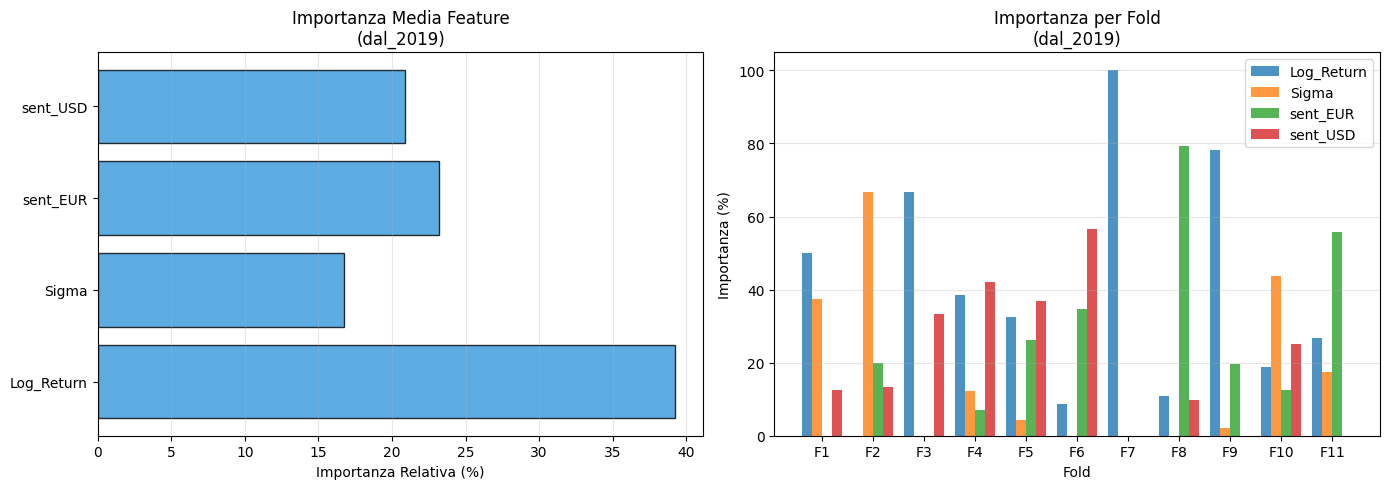


PERIODO: dal_2023 (dal 2023-01-01)
  Fold 1: Acc=0.4762 | LogRet=6.2% | Sigma=0.0% | EUR=18.7% | USD=75.0%
  Fold 2: Acc=0.5079 | LogRet=19.3% | Sigma=10.5% | EUR=7.0% | USD=63.2%
  Fold 3: Acc=0.4683 | LogRet=26.3% | Sigma=41.0% | EUR=13.5% | USD=19.2%

--- RIEPILOGO dal_2023 ---
Accuracy media: 0.4841
Importanza media feature:
  sent_USD       : 52.5%
  Log_Return     : 17.3%
  Sigma          : 17.2%
  sent_EUR       : 13.1%


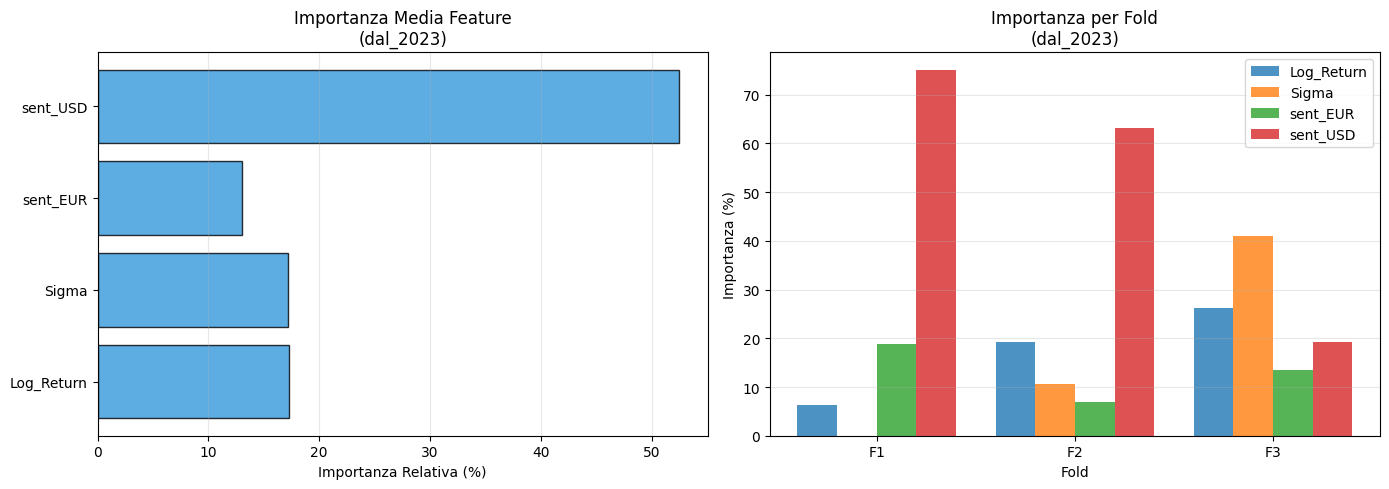


Done.


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

def permutation_importance(model, X_test, y_test, feature_names, n_repeats=10):
    """
    Calcola la permutation importance per ogni feature.
    Restituisce un dict con importanza relativa percentuale.
    """
    baseline_acc = (
        (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int) == y_test
    ).mean()

    importances = []
    for i in range(len(feature_names)):
        drops = []
        for r in range(n_repeats):
            np.random.seed(r)
            X_perm = X_test.copy()
            col = X_perm[:, :, i].flatten()
            np.random.shuffle(col)
            X_perm[:, :, i] = col.reshape(X_test.shape[0], X_test.shape[1])
            perm_acc = (
                (model.predict(X_perm, verbose=0).flatten() >= 0.5).astype(int) == y_test
            ).mean()
            drops.append(max(0, baseline_acc - perm_acc))
        importances.append(np.mean(drops))

    total = sum(importances) if sum(importances) > 0 else 1
    percentages = [imp / total * 100 for imp in importances]
    return dict(zip(feature_names, percentages))

# ----------------------------------------------------------------
# CONFIGURAZIONE
# ----------------------------------------------------------------
BEST_PARAMS = {
    'window_size':   20,
    'learning_rate': 0.0005,
    'lstm_units':    64,
    'dropout_rate':  0.4,
    'batch_size':    32
}

features   = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# Testa entrambi i periodi
periodi = {
    'dal_2019': '2019-01-01',
    'dal_2023': '2023-01-01'
}

for periodo_nome, data_inizio in periodi.items():

    print(f"\n{'='*55}")
    print(f"PERIODO: {periodo_nome} (dal {data_inizio})")
    print(f"{'='*55}")

    df = pd.read_csv('input_per_bilstm_final5.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values('Date', inplace=True)
    df = df[df['Date'] >= data_inizio].reset_index(drop=True)

    MIN_TRAIN_SIZE = 180
    TEST_SIZE      = 126
    n_folds        = (len(df) - MIN_TRAIN_SIZE) // TEST_SIZE
    if n_folds < 1:
        print("Dati insufficienti per questo periodo, skipping.")
        continue

    # Importanze aggregate su tutti i fold
    all_importances = {f: [] for f in features}
    fold_accuracies = []

    for fold in range(n_folds):
        train_end  = MIN_TRAIN_SIZE + (fold * TEST_SIZE)
        test_start = train_end
        test_end   = min(test_start + TEST_SIZE, len(df))

        if test_start >= len(df) - 5:
            break

        train_fold = df.iloc[:train_end].copy()
        test_fold  = df.iloc[test_start:test_end].copy()

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])

        context           = train_fold.iloc[-BEST_PARAMS['window_size']:].copy()
        test_with_context = pd.concat([context, test_fold], ignore_index=True)
        test_scaled       = scaler.transform(test_with_context[features])

        X_tr, y_tr = create_sequences(train_scaled,
                                       train_fold[target_col].values,
                                       BEST_PARAMS['window_size'])
        X_te, y_te = create_sequences(test_scaled,
                                       test_with_context[target_col].values,
                                       BEST_PARAMS['window_size'])

        val_split  = max(1, int(len(X_tr) * 0.15))
        X_tr_f     = X_tr[:-val_split]
        y_tr_f     = y_tr[:-val_split]
        X_val      = X_tr[-val_split:]
        y_val      = y_tr[-val_split:]

        tf.keras.backend.clear_session()
        set_reproducibility(42 + fold)

        model = Sequential([
            Input(shape=(BEST_PARAMS['window_size'], len(features))),
            LSTM(BEST_PARAMS['lstm_units'], return_sequences=True),
            Dropout(BEST_PARAMS['dropout_rate']),
            LSTM(BEST_PARAMS['lstm_units'] // 2),
            Dropout(BEST_PARAMS['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=Adam(BEST_PARAMS['learning_rate']),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_tr_f, y_tr_f,
            epochs=100,
            batch_size=BEST_PARAMS['batch_size'],
            validation_data=(X_val, y_val),
            callbacks=[EarlyStopping(monitor='val_loss', patience=12,
                                     restore_best_weights=True)],
            verbose=0
        )

        acc = (
            (model.predict(X_te, verbose=0).flatten() >= 0.5).astype(int) == y_te
        ).mean()
        fold_accuracies.append(acc)

        # Permutation importance per questo fold
        imp = permutation_importance(model, X_te, y_te, features, n_repeats=10)
        for f in features:
            all_importances[f].append(imp[f])

        print(f"  Fold {fold+1}: Acc={acc:.4f} | "
              f"LogRet={imp['Log_Return']:.1f}% | "
              f"Sigma={imp['Sigma']:.1f}% | "
              f"EUR={imp['sent_EUR']:.1f}% | "
              f"USD={imp['sent_USD']:.1f}%")

    # Importanze medie su tutti i fold
    mean_imp = {f: np.mean(vals) for f, vals in all_importances.items()
                if len(vals) > 0}
    total    = sum(mean_imp.values()) if sum(mean_imp.values()) > 0 else 1
    mean_imp_pct = {f: v / total * 100 for f, v in mean_imp.items()}

    print(f"\n--- RIEPILOGO {periodo_nome} ---")
    print(f"Accuracy media: {np.mean(fold_accuracies):.4f}")
    print("Importanza media feature:")
    for f, v in sorted(mean_imp_pct.items(), key=lambda x: -x[1]):
        print(f"  {f:<15}: {v:.1f}%")

    # Grafico importanze medie
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Importanza media
    axes[0].barh(list(mean_imp_pct.keys()),
                 list(mean_imp_pct.values()),
                 color='#3498db', edgecolor='black', alpha=0.8)
    axes[0].set_title(f'Importanza Media Feature\n({periodo_nome})')
    axes[0].set_xlabel('Importanza Relativa (%)')
    axes[0].grid(axis='x', alpha=0.3)

    # Importanza per fold
    x = np.arange(len(fold_accuracies))
    width = 0.2
    for idx, f in enumerate(features):
        vals = all_importances[f][:len(fold_accuracies)]
        axes[1].bar(x + idx * width, vals, width,
                    label=f, alpha=0.8)
    axes[1].set_title(f'Importanza per Fold\n({periodo_nome})')
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('Importanza (%)')
    axes[1].set_xticks(x + width * 1.5)
    axes[1].set_xticklabels([f'F{i+1}' for i in range(len(fold_accuracies))])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'feature_importance_{periodo_nome}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nDone.")

In [ ]:
# Verifica correlazione tra presenza/assenza sent_EUR e target
df['sent_EUR_presente'] = (df['sent_EUR'] != 0).astype(int)
print(df.groupby('sent_EUR_presente')['Target'].mean())

sent_EUR_presente
0    0.455621
1    0.491765
Name: Target, dtype: float64


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
        BACKTEST RISULTATI FINALI
Metrica                       LSTM   Market
---------------------------------------------
Sharpe Ratio               -0.3532   0.2442
Max Drawdown               -15.20%   -8.84%
Hit Rate                    49.48%
Rendimento Totale           -5.63%    4.09%
Sharpe Random               0.4911
N osservazioni                 574
IC 95% Sharpe             [-1.69, 0.99]


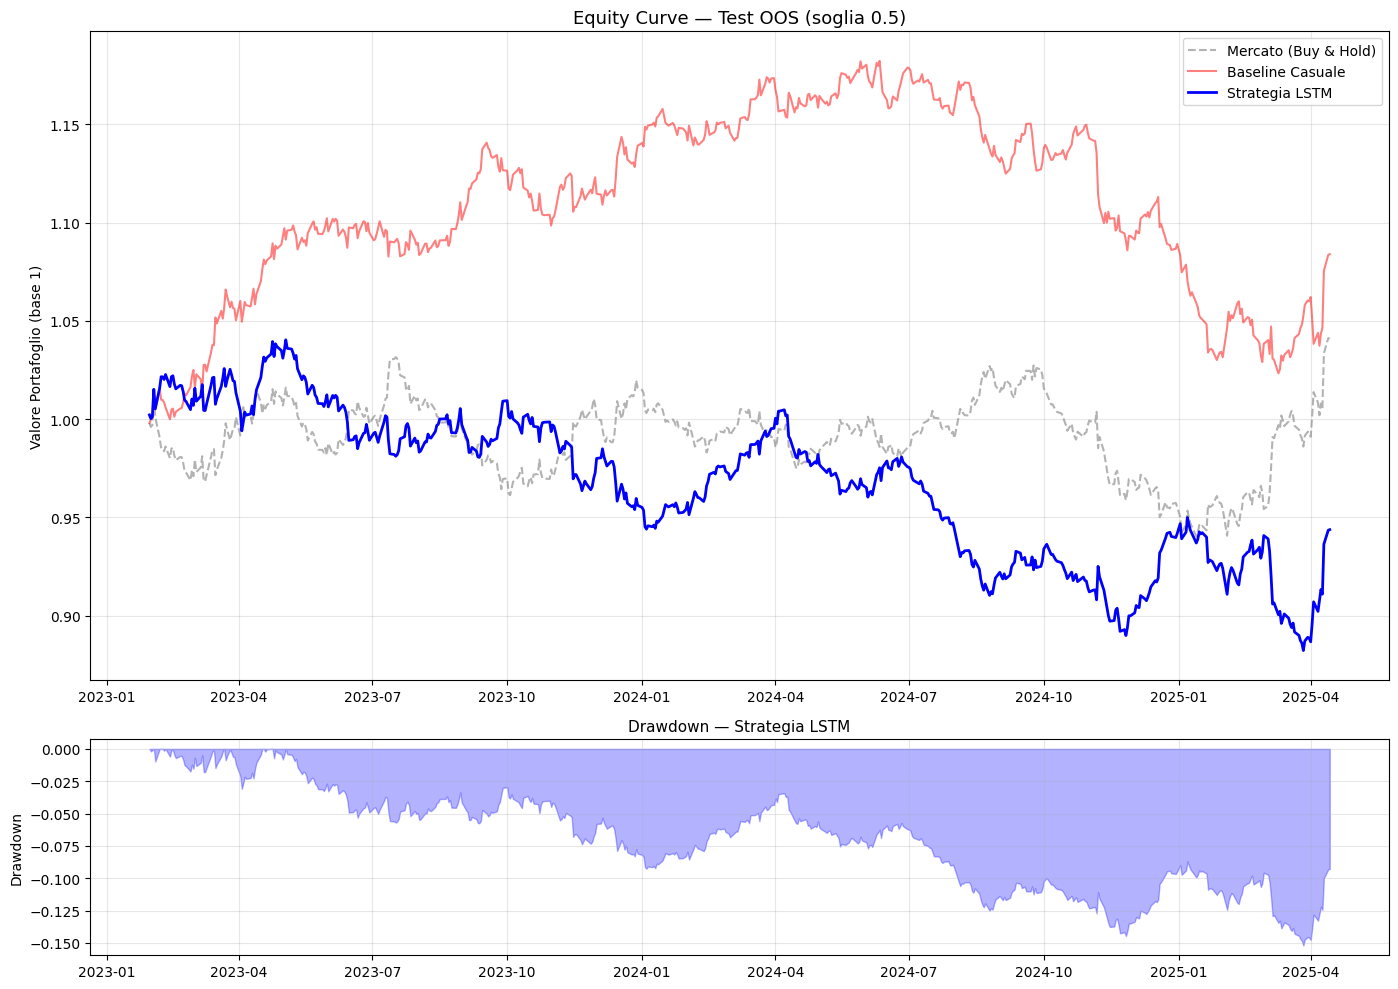

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Probabilità sul test OOS
y_pred_probs = final_model_bilstm.predict(X_test_seq)
window_size  = best_params['window_size']

# 2. Allineamento date e rendimenti
test_dates   = df_test['Date'].iloc[window_size:].values
test_returns = df_test['Log_Return'].iloc[window_size:].values

# 3. DataFrame backtest
backtest_df = pd.DataFrame({
    'Date':          test_dates,
    'Actual_Return': test_returns,
    'Prob_Up':       y_pred_probs.flatten()
})

# 4. Soglia fissa 0.5
backtest_df['Pos_LSTM'] = np.where(backtest_df['Prob_Up'] > 0.5, 1, -1)

# 5. Posizione di T applicata al rendimento di T+1
backtest_df['Ret_LSTM'] = backtest_df['Pos_LSTM'].shift(1) * backtest_df['Actual_Return']

# 6. Baseline casuale
np.random.seed(42)
backtest_df['Pos_Random'] = np.random.choice([1, -1], size=len(backtest_df))
backtest_df['Ret_Random'] = backtest_df['Pos_Random'].shift(1) * backtest_df['Actual_Return']

# 7. Pulizia NaN da shift
backtest_df.dropna(subset=['Ret_LSTM', 'Ret_Random'], inplace=True)

# 8. Equity curve
backtest_df['Equity_Market'] = np.exp(backtest_df['Actual_Return'].cumsum())
backtest_df['Equity_LSTM']   = np.exp(backtest_df['Ret_LSTM'].cumsum())
backtest_df['Equity_Random'] = np.exp(backtest_df['Ret_Random'].cumsum())

# 9. Metriche
def calcola_sharpe(returns, periods=252):
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods)

def calcola_max_drawdown(equity):
    rolling_max = equity.cummax()
    return ((equity - rolling_max) / rolling_max).min()

def calcola_hit_rate(returns):
    return (returns > 0).mean()

sharpe_lstm   = calcola_sharpe(backtest_df['Ret_LSTM'])
sharpe_random = calcola_sharpe(backtest_df['Ret_Random'])
sharpe_market = calcola_sharpe(backtest_df['Actual_Return'])

mdd_lstm   = calcola_max_drawdown(backtest_df['Equity_LSTM'])
mdd_market = calcola_max_drawdown(backtest_df['Equity_Market'])

hit_lstm   = calcola_hit_rate(backtest_df['Ret_LSTM'])

ret_tot_lstm   = (backtest_df['Equity_LSTM'].iloc[-1] - 1) * 100
ret_tot_market = (backtest_df['Equity_Market'].iloc[-1] - 1) * 100

# Intervallo di confidenza Sharpe
T = len(backtest_df)
se_sharpe = np.sqrt((1 + (sharpe_lstm**2) / 2) / T) * np.sqrt(252)

print("=" * 45)
print("        BACKTEST RISULTATI FINALI")
print("=" * 45)
print(f"{'Metrica':<25} {'LSTM':>8} {'Market':>8}")
print("-" * 45)
print(f"{'Sharpe Ratio':<25} {sharpe_lstm:>8.4f} {sharpe_market:>8.4f}")
print(f"{'Max Drawdown':<25} {mdd_lstm:>8.2%} {mdd_market:>8.2%}")
print(f"{'Hit Rate':<25} {hit_lstm:>8.2%}")
print(f"{'Rendimento Totale':<25} {ret_tot_lstm:>7.2f}% {ret_tot_market:>7.2f}%")
print(f"{'Sharpe Random':<25} {sharpe_random:>8.4f}")
print(f"{'N osservazioni':<25} {T:>8}")
print(f"{'IC 95% Sharpe':<25} [{sharpe_lstm - 1.96*se_sharpe:.2f}, {sharpe_lstm + 1.96*se_sharpe:.2f}]")
print("=" * 45)

# 10. Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(backtest_df['Date'], backtest_df['Equity_Market'],
         label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
ax1.plot(backtest_df['Date'], backtest_df['Equity_Random'],
         label='Baseline Casuale', color='red', alpha=0.5)
ax1.plot(backtest_df['Date'], backtest_df['Equity_LSTM'],
         label='Strategia LSTM', color='blue', linewidth=2)
ax1.set_title('Equity Curve — Test OOS (soglia 0.5)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylabel('Valore Portafoglio (base 1)')

rolling_max = backtest_df['Equity_LSTM'].cummax()
drawdown    = (backtest_df['Equity_LSTM'] - rolling_max) / rolling_max

ax2 = axes[1]
ax2.fill_between(backtest_df['Date'], drawdown, 0, color='blue', alpha=0.3)
ax2.set_title('Drawdown — Strategia LSTM', fontsize=11)
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Analisi stabilità per LSTM...


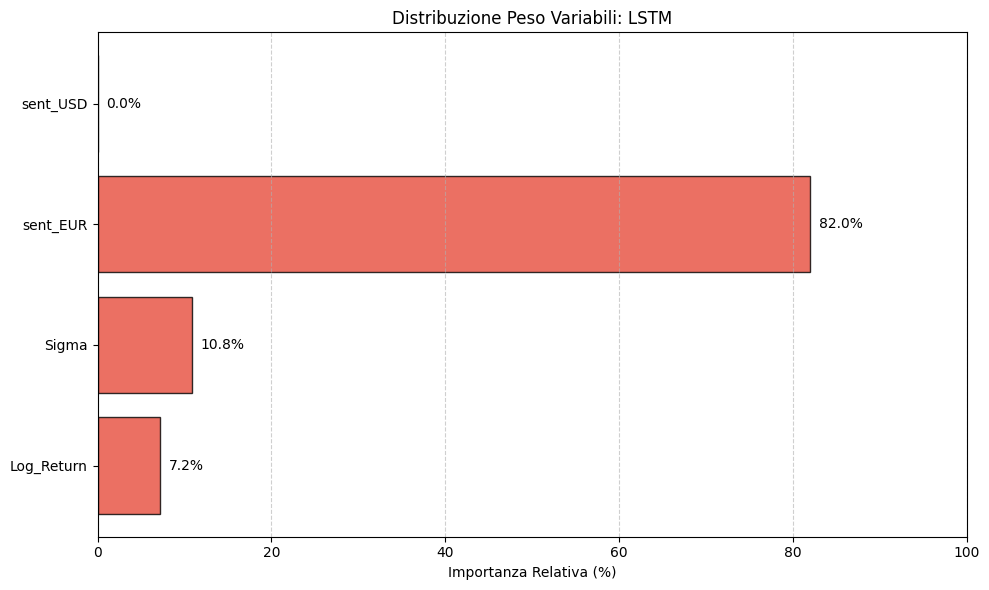

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_importance_percentage(model, X_test, y_test, features, title, n_repeats=15):
    _, baseline_acc = model.evaluate(X_test, y_test, verbose=0)
    importances = []

    print(f"Analisi stabilità per {title}...")

    for i in range(len(features)):
        scores = []
        for r in range(n_repeats):
            np.random.seed(r)
            X_permuted = X_test.copy()
            col = X_permuted[:, :, i].copy()
            flat = col.flatten()
            np.random.shuffle(flat)
            X_permuted[:, :, i] = flat.reshape(col.shape)

            _, perm_acc = model.evaluate(X_permuted, y_test, verbose=0)
            drop = max(0, baseline_acc - perm_acc)
            scores.append(drop)

        importances.append(np.mean(scores))

    total_importance = sum(importances)
    if total_importance == 0:
        percentages = [100/len(features)] * len(features)
    else:
        percentages = [(imp / total_importance) * 100 for imp in importances]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(features, percentages, color='#e74c3c', edgecolor='black', alpha=0.8)

    plt.xlabel('Importanza Relativa (%)')
    plt.title(f'Distribuzione Peso Variabili: {title}')
    plt.xlim(0, 100)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Esecuzione
features_names = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
plot_importance_percentage(final_model_lstm, X_test_seq, y_test_seq, features_names, "LSTM")

Tuning su 6 combinazioni...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5045, Std: 0.0121, Score: 0.4802
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5117, Std: 0.0153, Score: 0.4812
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5138, Std: 0.0109, Score: 0.4920
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg: 0.5173, Std: 0.0133, Score: 0.4906
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg: 0.5036, Std: 0.0138, Score: 0.4761
Trial 6: {'window_size': 20, 'lstm_units': 64, 'learning_rate': 0.001, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg: 0.5087, Std: 0.0187, Score: 0.4712

Migliori parametri: {'window_size': 20, 'lstm_unit

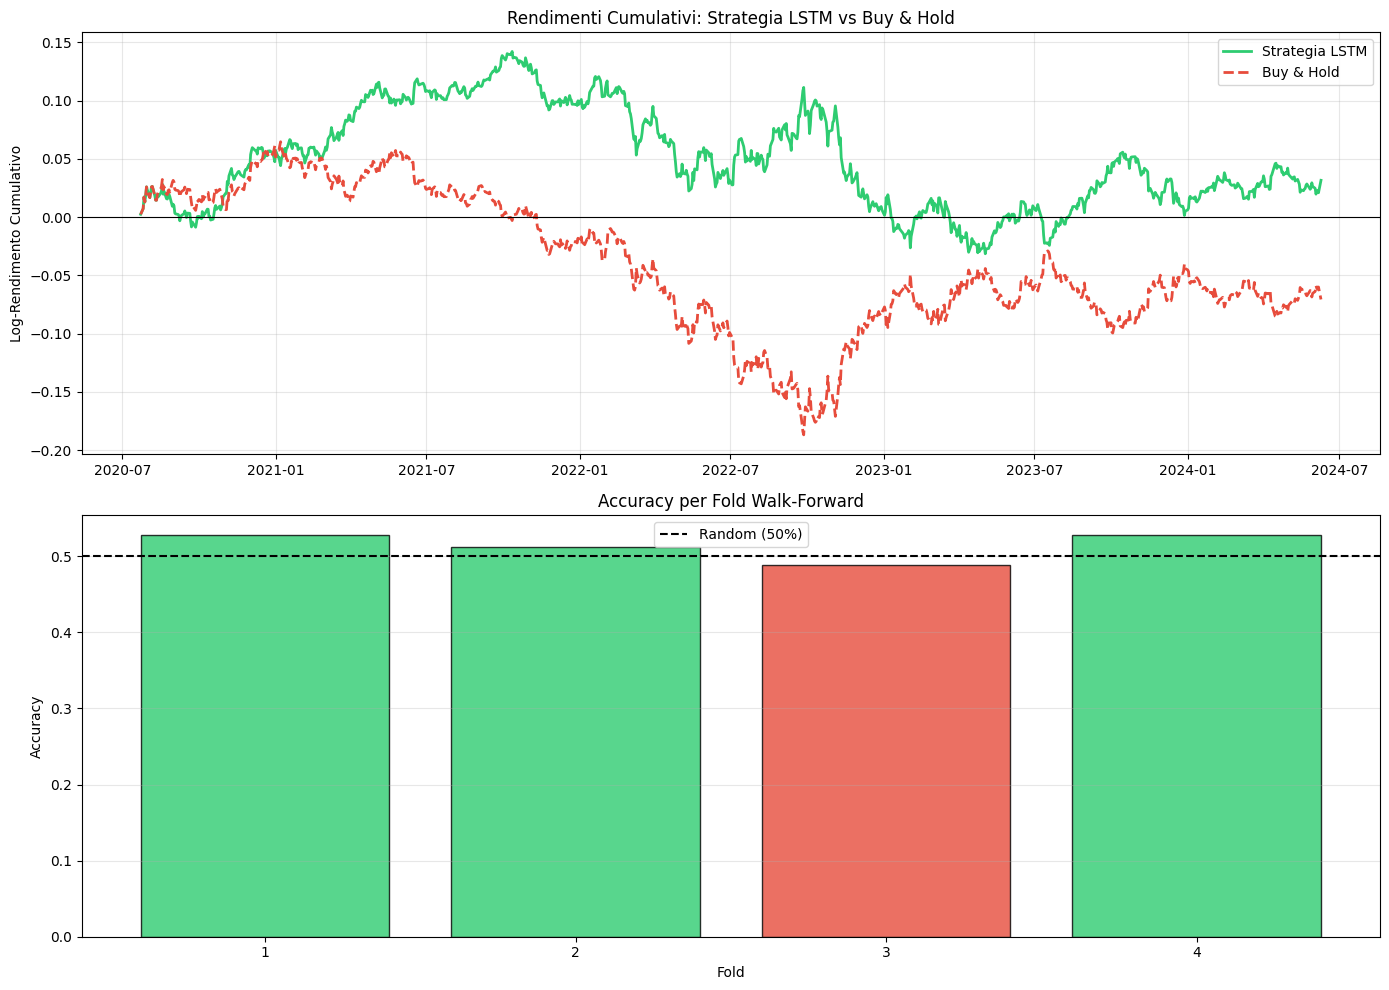


File salvati: 'backtest_results.csv', 'backtest_walkforward.png'


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

features   = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# TUNING — eseguito UNA VOLTA su tutto il dataset prima della WF
# ----------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler

param_grid = {
    'window_size':   [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units':    [32, 64],
    'dropout_rate':  [0.3, 0.4],
    'batch_size':    [32]
}

num_trials   = 6
tscv         = TimeSeriesSplit(n_splits=3)
param_list   = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

# Split 70% per tuning, 30% rimane vergine per walk-forward
split_tune = int(len(df) * 0.70)
df_tune    = df.iloc[:split_tune].reset_index(drop=True)

best_robust_score = -np.inf
best_params       = {}

print(f"Tuning su {len(param_list)} combinazioni...")

for trial, params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_tune):
        train_fold_t = df_tune.iloc[train_idx]
        val_fold_t   = df_tune.iloc[val_idx]

        scaler_t = StandardScaler()
        train_sc = scaler_t.fit_transform(train_fold_t[features])
        val_sc   = scaler_t.transform(val_fold_t[features])

        X_tr_t, y_tr_t = create_sequences(train_sc, train_fold_t[target_col].values, params['window_size'])
        X_vl_t, y_vl_t = create_sequences(val_sc,   val_fold_t[target_col].values,   params['window_size'])

        if len(X_tr_t) < 10 or len(X_vl_t) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        m = Sequential([
            Input(shape=(params['window_size'], len(features))),
            LSTM(params['lstm_units'], return_sequences=True),
            Dropout(params['dropout_rate']),
            LSTM(params['lstm_units'] // 2),
            Dropout(params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])
        m.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                  loss='binary_crossentropy', metrics=['accuracy'])
        m.fit(X_tr_t, y_tr_t, epochs=50, batch_size=params['batch_size'],
              validation_data=(X_vl_t, y_vl_t),
              callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                                       restore_best_weights=True)],
              verbose=0)

        _, acc = m.evaluate(X_vl_t, y_vl_t, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {params} -> Avg: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params       = params

print(f"\nMigliori parametri: {best_params}")

# ----------------------------------------------------------------
# WALK-FORWARD CON CONTESTO
# ----------------------------------------------------------------
WINDOW_SIZE   = best_params['window_size']
LSTM_UNITS    = best_params['lstm_units']
DROPOUT_RATE  = best_params['dropout_rate']
LEARNING_RATE = best_params['learning_rate']
BATCH_SIZE    = best_params['batch_size']

TRAIN_SIZE = 756   # ~3 anni
TEST_SIZE  = 252   # ~1 anno

n_folds = (len(df) - TRAIN_SIZE) // TEST_SIZE
print(f"\nDati totali: {len(df)} giorni")
print(f"Walk-forward: {n_folds} fold (Train: {TRAIN_SIZE}gg, Test: {TEST_SIZE}gg)")

all_dates       = []
all_true        = []
all_pred_proba  = []
all_pred_binary = []
fold_accuracies = []

for fold in range(n_folds):
    train_start = fold * TEST_SIZE
    train_end   = train_start + TRAIN_SIZE
    test_start  = train_end
    test_end    = test_start + TEST_SIZE

    if test_end > len(df):
        test_end = len(df)

    train_fold = df.iloc[train_start:train_end].copy()
    test_fold  = df.iloc[test_start:test_end].copy()

    if len(test_fold) < WINDOW_SIZE + 1:
        break

    print(f"\n[Fold {fold+1}/{n_folds}]")
    print(f"  Train: {train_fold['Date'].min().date()} -> {train_fold['Date'].max().date()} ({len(train_fold)} giorni)")
    print(f"  Test:  {test_fold['Date'].min().date()} -> {test_fold['Date'].max().date()} ({len(test_fold)} giorni)")

    # Scaler fittato solo sul train
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_fold[features])

    # *** CORREZIONE CHIAVE: aggiungi contesto del train al test ***
    context               = train_fold.iloc[-WINDOW_SIZE:].copy()
    test_with_context     = pd.concat([context, test_fold], ignore_index=True)
    test_context_scaled   = scaler.transform(test_with_context[features])

    X_tr, y_tr = create_sequences(train_scaled,       train_fold[target_col].values,        WINDOW_SIZE)
    X_te, y_te = create_sequences(test_context_scaled, test_with_context[target_col].values, WINDOW_SIZE)

    # Le prime sequenze di X_te ora hanno contesto reale dal training
    # y_te corrisponde esattamente ai giorni del test_fold
    assert len(X_te) == len(test_fold), \
        f"Mismatch sequenze: {len(X_te)} vs {len(test_fold)}"

    if len(X_tr) < 10 or len(X_te) < 5:
        print(f"  Fold {fold+1} saltato: sequenze insufficienti")
        continue

    # Validation interna — ultimi 15% del train
    val_split = int(len(X_tr) * 0.15)
    X_tr_es   = X_tr[:-val_split]
    y_tr_es   = y_tr[:-val_split]
    X_val_es  = X_tr[-val_split:]
    y_val_es  = y_tr[-val_split:]

    # Modello riaddestrato da zero ad ogni fold
    tf.keras.backend.clear_session()
    set_reproducibility(fold)

    model = Sequential([
        Input(shape=(WINDOW_SIZE, len(features))),
        LSTM(LSTM_UNITS, return_sequences=True),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS // 2),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_tr_es, y_tr_es,
        epochs=100,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_es, y_val_es),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                 restore_best_weights=True)],
        verbose=0
    )

    proba  = model.predict(X_te, verbose=0).flatten()
    binary = (proba >= 0.5).astype(int)
    acc    = (binary == y_te).mean()

    fold_accuracies.append(acc)
    all_dates.extend(test_fold['Date'].values)
    all_true.extend(y_te.tolist())
    all_pred_proba.extend(proba.tolist())
    all_pred_binary.extend(binary.tolist())

    print(f"  Accuracy fold {fold+1}: {acc:.4f}")

# ----------------------------------------------------------------
# RISULTATI AGGREGATI
# ----------------------------------------------------------------
print(f"\n--- RISULTATI WALK-FORWARD ---")
print(f"Fold completati: {len(fold_accuracies)}")
print(f"Accuracy media:  {np.mean(fold_accuracies):.4f}")
print(f"Accuracy std:    {np.std(fold_accuracies):.4f}")
print(f"Accuracy min:    {np.min(fold_accuracies):.4f}")
print(f"Accuracy max:    {np.max(fold_accuracies):.4f}")

# ----------------------------------------------------------------
# DATAFRAME RISULTATI
# ----------------------------------------------------------------
results_wf = pd.DataFrame({
    'Date':       pd.to_datetime(all_dates),
    'True':       all_true,
    'Pred_proba': all_pred_proba,
    'Pred':       all_pred_binary
}).sort_values('Date').reset_index(drop=True)

print(f"\nPeriodo coperto: {results_wf['Date'].min().date()} -> {results_wf['Date'].max().date()}")
print(f"Giorni totali con previsione: {len(results_wf)}")
print(f"\nDistribuzione previsioni:\n{results_wf['Pred'].value_counts()}")

results_wf.to_csv('risultati_walk_forward.csv', index=False)

# ----------------------------------------------------------------
# BACKTEST
# ----------------------------------------------------------------
backtest = results_wf.merge(
    df[['Date', 'Log_Return', 'Prezzo']],
    on='Date',
    how='left'
)

backtest['Strategy_Return']     = np.where(backtest['Pred'] == 1,
                                            backtest['Log_Return'],
                                           -backtest['Log_Return'])
backtest['BuyHold_Return']      = backtest['Log_Return']
backtest['Cumulative_Strategy'] = backtest['Strategy_Return'].cumsum()
backtest['Cumulative_BuyHold']  = backtest['BuyHold_Return'].cumsum()

ann_factor      = 252
ret_strategy    = backtest['Strategy_Return'].mean() * ann_factor
ret_buyhold     = backtest['BuyHold_Return'].mean()  * ann_factor
vol_strategy    = backtest['Strategy_Return'].std()  * np.sqrt(ann_factor)
vol_buyhold     = backtest['BuyHold_Return'].std()   * np.sqrt(ann_factor)
sharpe_strategy = ret_strategy / vol_strategy if vol_strategy > 0 else 0
sharpe_buyhold  = ret_buyhold  / vol_buyhold  if vol_buyhold  > 0 else 0

def max_drawdown(cumret):
    return (cumret - cumret.cummax()).min()

mdd_strategy = max_drawdown(backtest['Cumulative_Strategy'])
mdd_buyhold  = max_drawdown(backtest['Cumulative_BuyHold'])
win_rate     = (backtest['Strategy_Return'] > 0).mean()
hit_rate     = (backtest['Pred'] == backtest['True']).mean()

print("\n" + "=" * 55)
print("REPORT BACKTEST WALK-FORWARD")
print("=" * 55)
print(f"Periodo: {backtest['Date'].min().date()} -> {backtest['Date'].max().date()}")
print(f"Giorni totali: {len(backtest)}")
print()
print(f"{'Metrica':<30} {'Strategia':>12} {'Buy&Hold':>12}")
print("-" * 55)
print(f"{'Rendimento annualizzato':<30} {ret_strategy:>11.2%} {ret_buyhold:>11.2%}")
print(f"{'Volatilità annualizzata':<30} {vol_strategy:>11.2%} {vol_buyhold:>11.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_strategy:>12.4f} {sharpe_buyhold:>12.4f}")
print(f"{'Max Drawdown':<30} {mdd_strategy:>11.2%} {mdd_buyhold:>11.2%}")
print(f"{'Win Rate':<30} {win_rate:>11.2%}")
print(f"{'Hit Rate (accuracy)':<30} {hit_rate:>11.2%}")

# ----------------------------------------------------------------
# GRAFICI
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(backtest['Date'], backtest['Cumulative_Strategy'],
             label='Strategia LSTM', color='#2ecc71', linewidth=2)
axes[0].plot(backtest['Date'], backtest['Cumulative_BuyHold'],
             label='Buy & Hold', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Rendimenti Cumulativi: Strategia LSTM vs Buy & Hold')
axes[0].set_ylabel('Log-Rendimento Cumulativo')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)

axes[1].bar(
    range(1, len(fold_accuracies)+1),
    fold_accuracies,
    color=['#2ecc71' if a > 0.5 else '#e74c3c' for a in fold_accuracies],
    edgecolor='black', alpha=0.8
)
axes[1].axhline(y=0.5, color='black', linewidth=1.5,
                linestyle='--', label='Random (50%)')
axes[1].set_title('Accuracy per Fold Walk-Forward')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, len(fold_accuracies)+1))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()

backtest.to_csv('backtest_results.csv', index=False)
print("\nFile salvati: 'backtest_results.csv', 'backtest_walkforward.png'")

Inizio Rolling Walk-Forward dal 2023: 14 fold previsti.
Fold 1/14 | Fine Test: 2023-02-28 | Acc: 0.7143
Fold 2/14 | Fine Test: 2023-04-26 | Acc: 0.5238
Fold 3/14 | Fine Test: 2023-06-25 | Acc: 0.3810
Fold 4/14 | Fine Test: 2023-08-22 | Acc: 0.5238
Fold 5/14 | Fine Test: 2023-10-19 | Acc: 0.5238
Fold 6/14 | Fine Test: 2023-12-19 | Acc: 0.4524
Fold 7/14 | Fine Test: 2024-02-16 | Acc: 0.5476
Fold 8/14 | Fine Test: 2024-04-15 | Acc: 0.3571
Fold 9/14 | Fine Test: 2024-06-12 | Acc: 0.5000
Fold 10/14 | Fine Test: 2024-08-11 | Acc: 0.4286
Fold 11/14 | Fine Test: 2024-10-09 | Acc: 0.5000
Fold 12/14 | Fine Test: 2024-12-09 | Acc: 0.4762
Fold 13/14 | Fine Test: 2025-02-06 | Acc: 0.4286
Fold 14/14 | Fine Test: 2025-04-06 | Acc: 0.4524

RISULTATI ROLLING DAL 2023
Accuracy Media: 0.4864


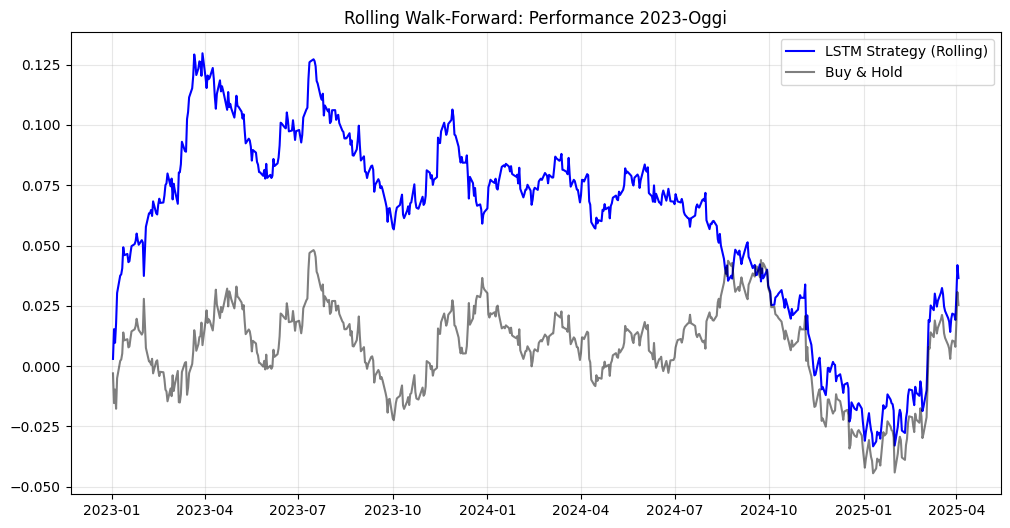

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Filtro per iniziare il TEST dal 2023, ma teniamo i dati precedenti per il primo TRAIN
START_DATE_TEST = pd.to_datetime('2023-01-01')

features   = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

# ----------------------------------------------------------------
# CONFIGURAZIONE ROLLING WINDOW
# ----------------------------------------------------------------
WINDOW_SIZE   = 20
TRAIN_SIZE    = 252  # Il modello impara sempre dall'ultimo anno (circa 252gg)
TEST_SIZE     = 42   # Testiamo 2 mesi alla volta per avere molti fold e adattamento rapido

# Trova l'indice di partenza del 2023
first_test_idx = df[df['Date'] >= START_DATE_TEST].index[0]

# Numero di fold necessari per coprire dal 2023 a oggi
n_folds = (len(df) - first_test_idx) // TEST_SIZE
print(f"Inizio Rolling Walk-Forward dal 2023: {n_folds} fold previsti.")

# ----------------------------------------------------------------
# LOOP ROLLING
# ----------------------------------------------------------------
results_list = []
fold_accuracies = []

for fold in range(n_folds):
    # ROLLING: Sia l'inizio che la fine si spostano in avanti
    test_start  = first_test_idx + (fold * TEST_SIZE)
    test_end    = test_start + TEST_SIZE
    train_start = test_start - TRAIN_SIZE
    train_end   = test_start

    if test_end > len(df): test_end = len(df)
    if train_start < 0: train_start = 0 # Sicurezza per i primi dati

    train_fold = df.iloc[train_start:train_end].copy()
    test_fold  = df.iloc[test_start:test_end].copy()

    # Scaling fit solo su train
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_fold[features])

    # Context per continuità sequenze
    context = train_fold.iloc[-WINDOW_SIZE:].copy()
    test_with_context = pd.concat([context, test_fold], ignore_index=True)
    test_scaled = scaler.transform(test_with_context[features])

    X_tr, y_tr = create_sequences(train_scaled, train_fold[target_col].values, WINDOW_SIZE)
    X_te, y_te = create_sequences(test_scaled, test_with_context[target_col].values, WINDOW_SIZE)

    # Validation
    val_split = max(1, int(len(X_tr) * 0.15))
    X_tr_f, y_tr_f = X_tr[:-val_split], y_tr[:-val_split]
    X_val, y_val   = X_tr[-val_split:], y_tr[-val_split:]

    tf.keras.backend.clear_session()
    set_reproducibility(42 + fold)

    model = Sequential([
        Input(shape=(WINDOW_SIZE, len(features))),
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(25),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]

    model.fit(X_tr_f, y_tr_f, epochs=70, batch_size=32,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)

    # Predizioni
    proba = model.predict(X_te, verbose=0).flatten()
    preds = (proba >= 0.5).astype(int)

    fold_acc = (preds == y_te).mean()
    fold_accuracies.append(fold_acc)

    print(f"Fold {fold+1}/{n_folds} | Fine Test: {test_fold['Date'].max().date()} | Acc: {fold_acc:.4f}")

    results_list.append(pd.DataFrame({
        'Date': test_fold['Date'].values,
        'True': y_te,
        'Pred': preds,
        'Log_Return': test_fold['Log_Return'].values
    }))

# ----------------------------------------------------------------
# BACKTEST FINALE
# ----------------------------------------------------------------
full_results = pd.concat(results_list).reset_index(drop=True)
full_results['Next_Log_Return'] = full_results['Log_Return'].shift(-1)
full_results['Strategy_Return'] = np.where(full_results['Pred'] == 1,
                                            full_results['Next_Log_Return'],
                                           -full_results['Next_Log_Return'])
full_results.dropna(inplace=True)

print("\n" + "="*40)
print(f"RISULTATI ROLLING DAL 2023")
print(f"Accuracy Media: {np.mean(fold_accuracies):.4f}")
print("="*40)

plt.figure(figsize=(12, 6))
plt.plot(full_results['Date'], full_results['Strategy_Return'].cumsum(), label='LSTM Strategy (Rolling)', color='blue')
plt.plot(full_results['Date'], full_results['Next_Log_Return'].cumsum(), label='Buy & Hold', color='black', alpha=0.5)
plt.title('Rolling Walk-Forward: Performance 2023-Oggi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Analisi Feature Importance: LSTM Finale ---
Baseline Accuracy: 0.5459
Feature: Log_Return   | Avg Drop Accuracy: 0.0025
Feature: Sigma        | Avg Drop Accuracy: 0.0000
Feature: sent_EUR     | Avg Drop Accuracy: 0.0086
Feature: sent_USD     | Avg Drop Accuracy: 0.0032


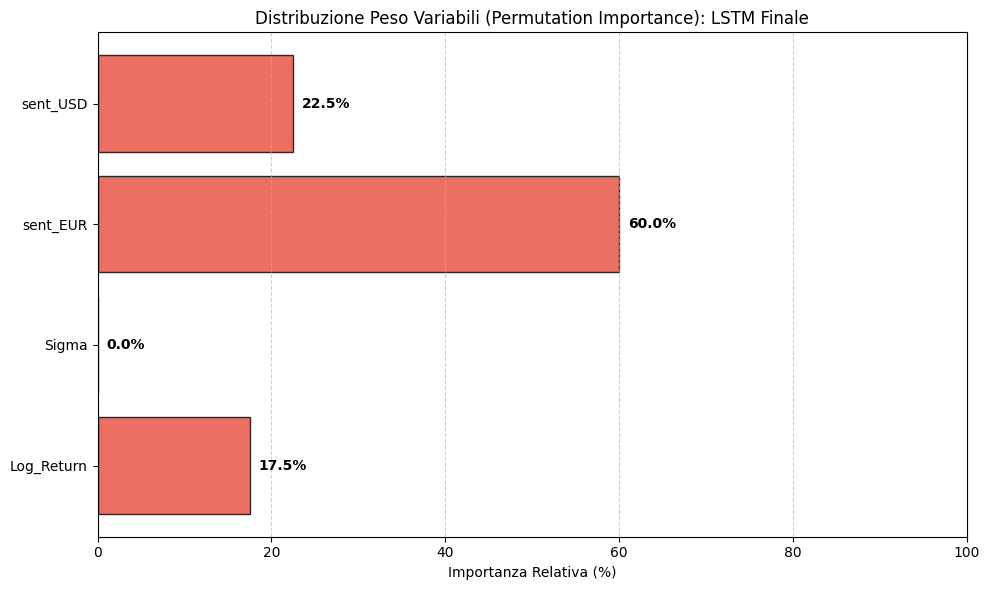

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_importance_percentage(model, X_test, y_test, features, title, n_repeats=15):
    """
    Calcola e visualizza l'importanza delle feature basata sul drop dell'accuratezza
    dopo la permutazione delle colonne (Permutation Importance).
    """
    # Calcolo accuratezza base
    _, baseline_acc = model.evaluate(X_test, y_test, verbose=0)
    importances = []

    print(f"--- Analisi Feature Importance: {title} ---")
    print(f"Baseline Accuracy: {baseline_acc:.4f}")

    for i in range(len(features)):
        scores = []
        for r in range(n_repeats):
            # Impostiamo un seed per la riproducibilità della permutazione
            np.random.seed(r)

            # Creiamo una copia per non sporcare i dati originali
            X_permuted = X_test.copy()

            # Estraiamo la feature specifica (tutte le sequenze, tutti i timesteps, feature i)
            col = X_permuted[:, :, i].copy()
            flat = col.flatten()

            # Mescoliamo i dati della feature
            np.random.shuffle(flat)

            # Reinseriamo i dati mescolati nella struttura originale
            X_permuted[:, :, i] = flat.reshape(col.shape)

            # Valutiamo il modello sui dati "corrotti"
            _, perm_acc = model.evaluate(X_permuted, y_test, verbose=0)

            # Misuriamo quanto è peggiorata l'accuratezza
            drop = max(0, baseline_acc - perm_acc)
            scores.append(drop)

        # Media dei drop su n_repeats
        avg_drop = np.mean(scores)
        importances.append(avg_drop)
        print(f"Feature: {features[i]:<12} | Avg Drop Accuracy: {avg_drop:.4f}")

    # Calcolo dei pesi percentuali relativi
    total_importance = sum(importances)
    if total_importance == 0:
        percentages = [100/len(features)] * len(features)
    else:
        percentages = [(imp / total_importance) * 100 for imp in importances]

    # Grafico
    plt.figure(figsize=(10, 6))
    bars = plt.barh(features, percentages, color='#e74c3c', edgecolor='black', alpha=0.8)

    plt.xlabel('Importanza Relativa (%)')
    plt.title(f'Distribuzione Peso Variabili (Permutation Importance): {title}')
    plt.xlim(0, 100)

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center', fontweight='bold')

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Esecuzione (Assicurati che i nomi coincidano con quelli del tuo ultimo training)
features_names = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
plot_importance_percentage(model, X_test_seq, y_test_seq, features_names, "LSTM Finale")

Dati caricati: 1983 giorni
Periodo: 2017-08-27 -> 2025-04-14
Distribuzione target:
Target
0    1001
1     982
Name: count, dtype: int64

Walk-forward: 4 fold
Train: 756 giorni | Test: 252 giorni

[Fold 1/4]
  Train: 2017-08-27 -> 2020-07-22 (756 giorni)
  Test:  2020-07-23 -> 2021-07-12 (252 giorni)
  Accuracy fold 1: 0.5119

[Fold 2/4]
  Train: 2018-08-15 -> 2021-07-12 (756 giorni)
  Test:  2021-07-13 -> 2022-07-03 (252 giorni)
  Accuracy fold 2: 0.4802

[Fold 3/4]
  Train: 2019-08-05 -> 2022-07-03 (756 giorni)
  Test:  2022-07-04 -> 2023-06-20 (252 giorni)
  Accuracy fold 3: 0.5556

[Fold 4/4]
  Train: 2020-07-23 -> 2023-06-20 (756 giorni)
  Test:  2023-06-21 -> 2024-06-09 (252 giorni)
  Accuracy fold 4: 0.5040

--- RISULTATI WALK-FORWARD ---
Fold completati: 4
Accuracy media:  0.5129
Accuracy std:    0.0273
Accuracy min:    0.4802
Accuracy max:    0.5556

Periodo coperto: 2020-07-23 -> 2024-06-09
Giorni totali con previsione: 1008

Distribuzione previsioni:
Pred
1    509
0    499
Na

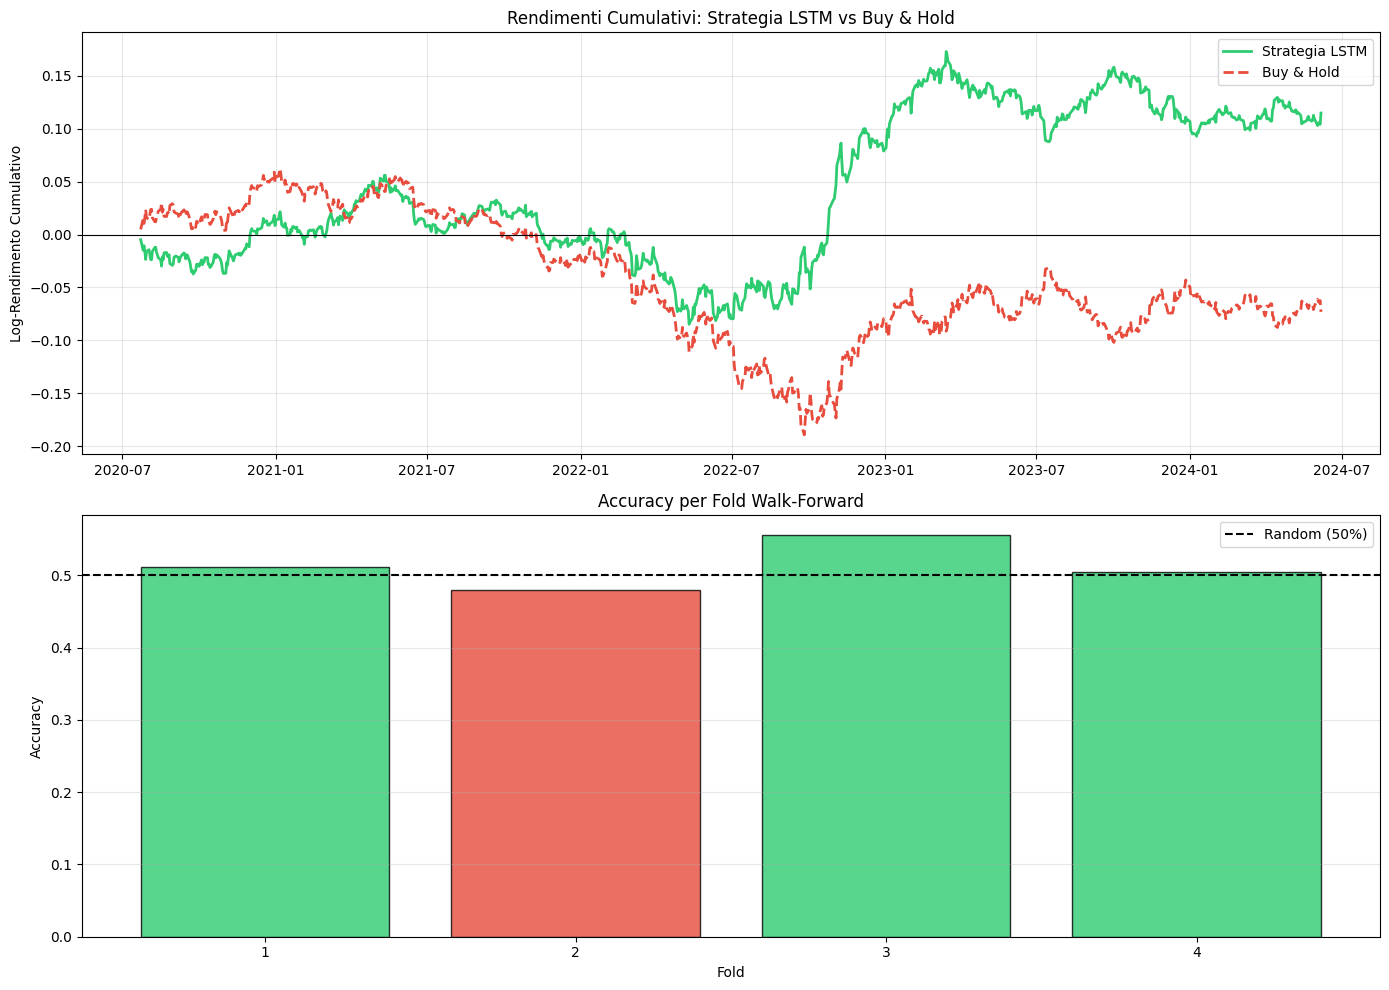


File salvati: 'backtest_results.csv', 'backtest_walkforward.png', 'risultati_walk_forward.csv'


In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

features   = ['Log_Return', 'Sigma', 'sent_EUR', 'sent_USD']
target_col = 'Target'

print(f"Dati caricati: {len(df)} giorni")
print(f"Periodo: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Distribuzione target:\n{df[target_col].value_counts()}")

# ----------------------------------------------------------------
# PARAMETRI FISSI
# ----------------------------------------------------------------
WINDOW_SIZE   = 20
LSTM_UNITS    = 64
DROPOUT_RATE  = 0.3
LEARNING_RATE = 0.001
BATCH_SIZE    = 32
TRAIN_SIZE    = 756   # ~3 anni
TEST_SIZE     = 252   # ~1 anno

n_folds = (len(df) - TRAIN_SIZE) // TEST_SIZE
print(f"\nWalk-forward: {n_folds} fold")
print(f"Train: {TRAIN_SIZE} giorni | Test: {TEST_SIZE} giorni")

# ----------------------------------------------------------------
# WALK-FORWARD LOOP
# ----------------------------------------------------------------
all_dates       = []
all_true        = []
all_pred_proba  = []
all_pred_binary = []
fold_accuracies = []

for fold in range(n_folds):
    train_start = fold * TEST_SIZE
    train_end   = train_start + TRAIN_SIZE
    test_start  = train_end
    test_end    = test_start + TEST_SIZE

    if test_end > len(df):
        test_end = len(df)

    train_fold = df.iloc[train_start:train_end].copy()
    test_fold  = df.iloc[test_start:test_end].copy()

    if len(test_fold) < WINDOW_SIZE + 1:
        break

    print(f"\n[Fold {fold+1}/{n_folds}]")
    print(f"  Train: {train_fold['Date'].min().date()} -> {train_fold['Date'].max().date()} ({len(train_fold)} giorni)")
    print(f"  Test:  {test_fold['Date'].min().date()} -> {test_fold['Date'].max().date()} ({len(test_fold)} giorni)")

    # Scaler fittato solo sul train
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_fold[features])

    # Aggiungi contesto del train al test per le sequenze
    context             = train_fold.iloc[-WINDOW_SIZE:].copy()
    test_with_context   = pd.concat([context, test_fold], ignore_index=True)
    test_context_scaled = scaler.transform(test_with_context[features])

    X_tr, y_tr = create_sequences(train_scaled,
                                   train_fold[target_col].values,
                                   WINDOW_SIZE)
    X_te, y_te = create_sequences(test_context_scaled,
                                   test_with_context[target_col].values,
                                   WINDOW_SIZE)

    # Verifica allineamento
    assert len(X_te) == len(test_fold), \
        f"Mismatch: {len(X_te)} sequenze vs {len(test_fold)} giorni test"

    if len(X_tr) < 10 or len(X_te) < 5:
        print(f"  Fold {fold+1} saltato: sequenze insufficienti")
        continue

    # Validation interna — ultimi 15% del train
    val_split = int(len(X_tr) * 0.15)
    X_tr_es   = X_tr[:-val_split]
    y_tr_es   = y_tr[:-val_split]
    X_val_es  = X_tr[-val_split:]
    y_val_es  = y_tr[-val_split:]

    # Modello riaddestrato da zero ad ogni fold
    tf.keras.backend.clear_session()
    set_reproducibility(fold)

    model = Sequential([
        Input(shape=(WINDOW_SIZE, len(features))),
        LSTM(LSTM_UNITS, return_sequences=True),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS // 2),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_tr_es, y_tr_es,
        epochs=100,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_es, y_val_es),
        callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                 restore_best_weights=True)],
        verbose=0
    )

    proba  = model.predict(X_te, verbose=0).flatten()
    binary = (proba >= 0.5).astype(int)
    acc    = (binary == y_te).mean()

    fold_accuracies.append(acc)
    all_dates.extend(test_fold['Date'].values)
    all_true.extend(y_te.tolist())
    all_pred_proba.extend(proba.tolist())
    all_pred_binary.extend(binary.tolist())

    print(f"  Accuracy fold {fold+1}: {acc:.4f}")

# ----------------------------------------------------------------
# RISULTATI AGGREGATI
# ----------------------------------------------------------------
print(f"\n--- RISULTATI WALK-FORWARD ---")
print(f"Fold completati: {len(fold_accuracies)}")
print(f"Accuracy media:  {np.mean(fold_accuracies):.4f}")
print(f"Accuracy std:    {np.std(fold_accuracies):.4f}")
print(f"Accuracy min:    {np.min(fold_accuracies):.4f}")
print(f"Accuracy max:    {np.max(fold_accuracies):.4f}")

# ----------------------------------------------------------------
# DATAFRAME RISULTATI
# ----------------------------------------------------------------
results_wf = pd.DataFrame({
    'Date':       pd.to_datetime(all_dates),
    'True':       all_true,
    'Pred_proba': all_pred_proba,
    'Pred':       all_pred_binary
}).sort_values('Date').reset_index(drop=True)

print(f"\nPeriodo coperto: {results_wf['Date'].min().date()} -> {results_wf['Date'].max().date()}")
print(f"Giorni totali con previsione: {len(results_wf)}")
print(f"\nDistribuzione previsioni:\n{results_wf['Pred'].value_counts()}")

# ----------------------------------------------------------------
# BACKTEST — CORRETTO: usa Log_Return del giorno SUCCESSIVO
# ----------------------------------------------------------------
backtest = results_wf.merge(
    df[['Date', 'Log_Return', 'Prezzo']],
    on='Date',
    how='left'
)

# Il modello prevede la direzione di t+1, quindi il rendimento
# da catturare è quello del giorno successivo
backtest['Log_Return_Next'] = backtest['Log_Return'].shift(-1)

backtest['Strategy_Return'] = np.where(
    backtest['Pred'] == 1,
     backtest['Log_Return_Next'],
    -backtest['Log_Return_Next']
)
backtest['BuyHold_Return'] = backtest['Log_Return_Next']

# Rimuovi ultima riga senza Log_Return_Next
backtest = backtest.dropna(subset=['Log_Return_Next']).reset_index(drop=True)

backtest['Cumulative_Strategy'] = backtest['Strategy_Return'].cumsum()
backtest['Cumulative_BuyHold']  = backtest['BuyHold_Return'].cumsum()

# ----------------------------------------------------------------
# METRICHE
# ----------------------------------------------------------------
ann_factor      = 252
ret_strategy    = backtest['Strategy_Return'].mean() * ann_factor
ret_buyhold     = backtest['BuyHold_Return'].mean()  * ann_factor
vol_strategy    = backtest['Strategy_Return'].std()  * np.sqrt(ann_factor)
vol_buyhold     = backtest['BuyHold_Return'].std()   * np.sqrt(ann_factor)
sharpe_strategy = ret_strategy / vol_strategy if vol_strategy > 0 else 0
sharpe_buyhold  = ret_buyhold  / vol_buyhold  if vol_buyhold  > 0 else 0

def max_drawdown(cumret):
    return (cumret - cumret.cummax()).min()

mdd_strategy = max_drawdown(backtest['Cumulative_Strategy'])
mdd_buyhold  = max_drawdown(backtest['Cumulative_BuyHold'])
win_rate     = (backtest['Strategy_Return'] > 0).mean()
hit_rate     = (backtest['Pred'] == backtest['True']).mean()

print("\n" + "=" * 55)
print("REPORT BACKTEST WALK-FORWARD")
print("=" * 55)
print(f"Periodo: {backtest['Date'].min().date()} -> {backtest['Date'].max().date()}")
print(f"Giorni totali: {len(backtest)}")
print()
print(f"{'Metrica':<30} {'Strategia':>12} {'Buy&Hold':>12}")
print("-" * 55)
print(f"{'Rendimento annualizzato':<30} {ret_strategy:>11.2%} {ret_buyhold:>11.2%}")
print(f"{'Volatilità annualizzata':<30} {vol_strategy:>11.2%} {vol_buyhold:>11.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_strategy:>12.4f} {sharpe_buyhold:>12.4f}")
print(f"{'Max Drawdown':<30} {mdd_strategy:>11.2%} {mdd_buyhold:>11.2%}")
print(f"{'Win Rate':<30} {win_rate:>11.2%}")
print(f"{'Hit Rate (accuracy)':<30} {hit_rate:>11.2%}")

# ----------------------------------------------------------------
# GRAFICI
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(backtest['Date'], backtest['Cumulative_Strategy'],
             label='Strategia LSTM', color='#2ecc71', linewidth=2)
axes[0].plot(backtest['Date'], backtest['Cumulative_BuyHold'],
             label='Buy & Hold', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Rendimenti Cumulativi: Strategia LSTM vs Buy & Hold')
axes[0].set_ylabel('Log-Rendimento Cumulativo')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)

axes[1].bar(
    range(1, len(fold_accuracies)+1),
    fold_accuracies,
    color=['#2ecc71' if a > 0.5 else '#e74c3c' for a in fold_accuracies],
    edgecolor='black', alpha=0.8
)
axes[1].axhline(y=0.5, color='black', linewidth=1.5,
                linestyle='--', label='Random (50%)')
axes[1].set_title('Accuracy per Fold Walk-Forward')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, len(fold_accuracies)+1))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()

backtest.to_csv('backtest_results.csv', index=False)
results_wf.to_csv('risultati_walk_forward.csv', index=False)
print("\nFile salvati: 'backtest_results.csv', 'backtest_walkforward.png', 'risultati_walk_forward.csv'")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


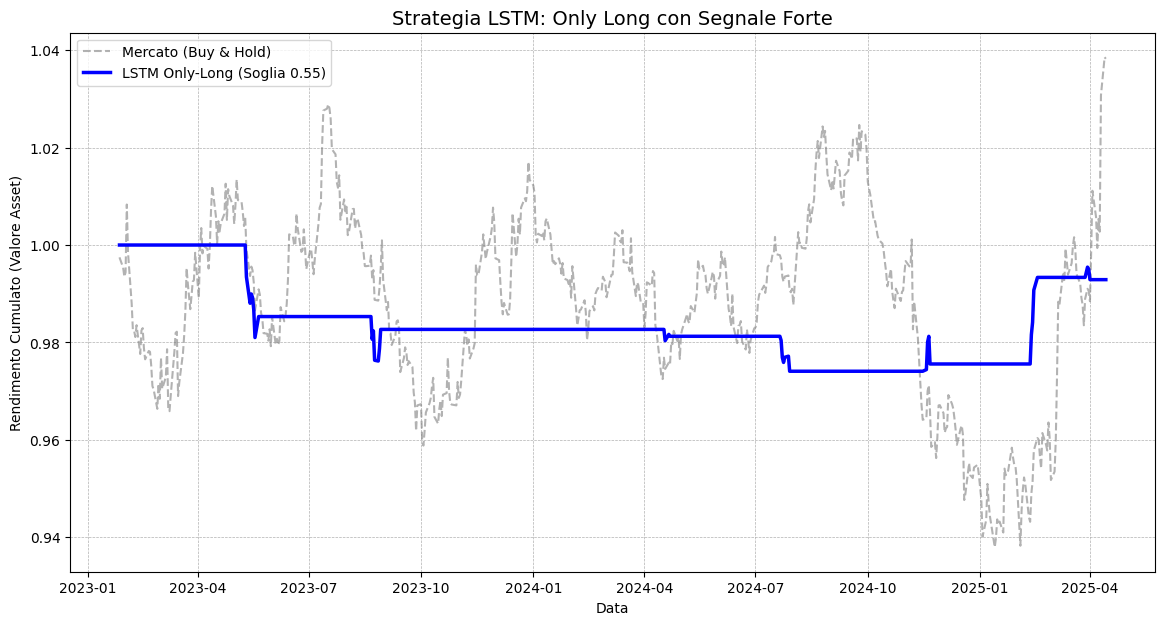

--- RISULTATI ONLY LONG (Soglia 0.55) ---
Rendimento Totale:               -0.71%
Sharpe Ratio:                    -0.23
Tempo di esposizione al mercato: 5.74%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SOGLIA_STRONG_LONG = 0.55

# Variabili aggiornate coerenti con il nuovo tuning
y_pred_probs = final_model_lstm.predict(X_test_seq)
window_size  = best_params['window_size']

test_dates   = df_test['Date'].iloc[window_size:].values
test_returns = df_test['Log_Return'].iloc[window_size:].values

backtest_long_only_df = pd.DataFrame({
    'Date':          test_dates,
    'Actual_Return': test_returns,
    'Prob_Up':       y_pred_probs.flatten()
})

backtest_long_only_df['Pos_Long_Only'] = np.where(backtest_long_only_df['Prob_Up'] > SOGLIA_STRONG_LONG, 1, 0)

backtest_long_only_df['Ret_Long_Only'] = backtest_long_only_df['Pos_Long_Only'].shift(1) * backtest_long_only_df['Actual_Return']

backtest_long_only_df['Equity_Market']    = np.exp(backtest_long_only_df['Actual_Return'].cumsum())
backtest_long_only_df['Equity_Long_Only'] = np.exp(backtest_long_only_df['Ret_Long_Only'].fillna(0).cumsum())

plt.figure(figsize=(14, 7))
plt.plot(backtest_long_only_df['Date'], backtest_long_only_df['Equity_Market'],
         label='Mercato (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)
plt.plot(backtest_long_only_df['Date'], backtest_long_only_df['Equity_Long_Only'],
         label=f'LSTM Only-Long (Soglia {SOGLIA_STRONG_LONG})', color='blue', linewidth=2.5)

plt.title('Strategia LSTM: Only Long con Segnale Forte', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Rendimento Cumulato (Valore Asset)')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

def calcola_sharpe(returns, periods=252):
    if returns.std() == 0:
        return np.nan
    return (returns.mean() / returns.std()) * np.sqrt(periods)

ret_long    = backtest_long_only_df['Ret_Long_Only'].fillna(0)
perf_long   = (backtest_long_only_df['Equity_Long_Only'].iloc[-1] - 1) * 100
sharpe_long = calcola_sharpe(ret_long)
exposure    = (backtest_long_only_df['Pos_Long_Only'] == 1).mean() * 100

print(f"--- RISULTATI ONLY LONG (Soglia {SOGLIA_STRONG_LONG}) ---")
print(f"Rendimento Totale:               {perf_long:.2f}%")
print(f"Sharpe Ratio:                    {sharpe_long:.2f}")
print(f"Tempo di esposizione al mercato: {exposure:.2f}%")

/tmp/ipykernel_2412/1575419873.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)
[*********************100%***********************]  1 of 1 completed


Punto di aggancio reale (15/04/2025): 1.129267


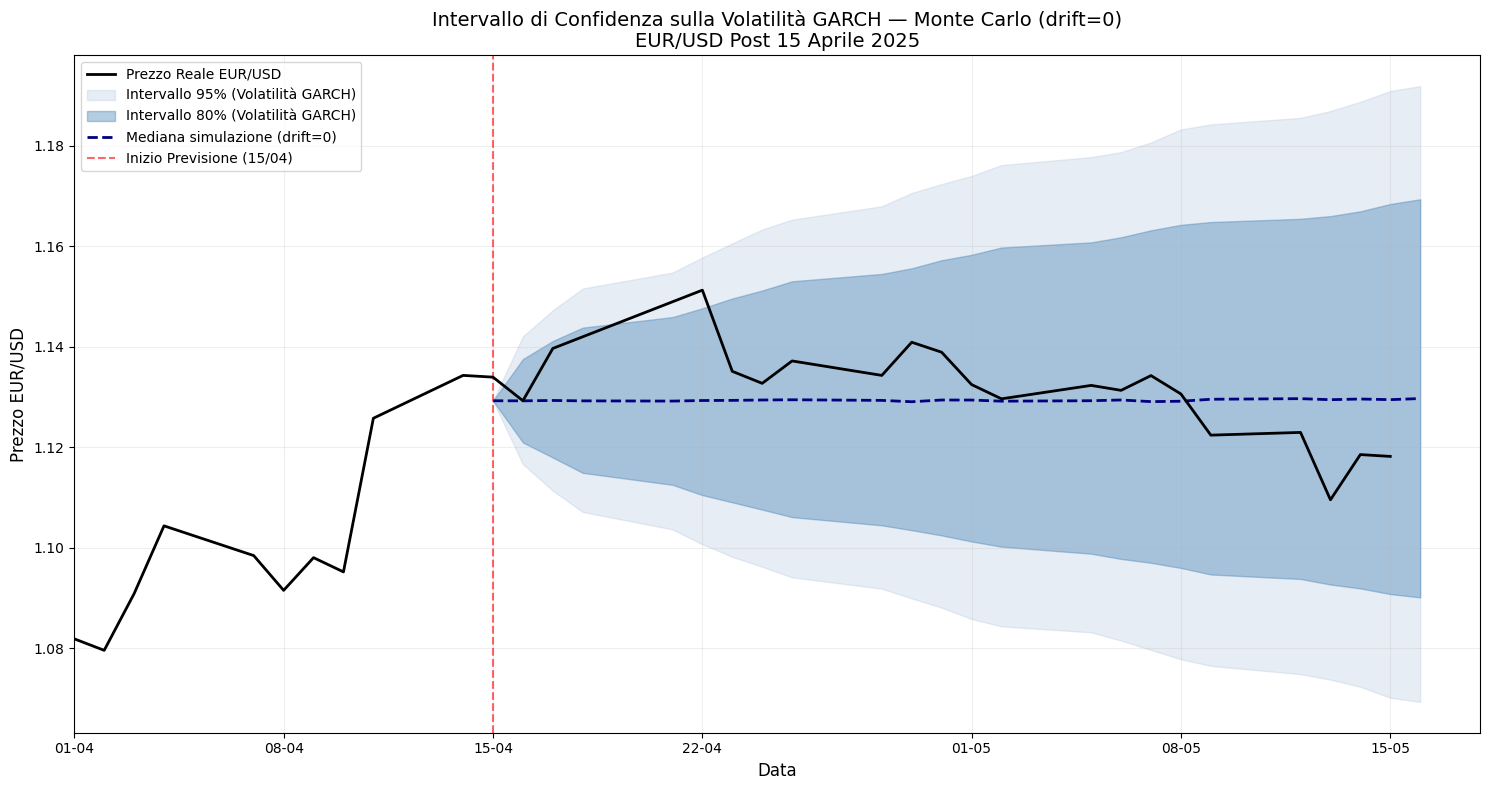

--- REPORT SIMULAZIONE ---
Sigma GARCH utilizzata:  0.005712
Prezzo iniziale (15/04): 1.129267
Drift applicato:         0 (rimosso)
Orizzonte simulato:      23 giorni lavorativi
Scenari simulati:        10,000


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

LAST_HISTORICAL_DATE = "2025-04-15"
START_FORECAST       = "2025-04-16"
END_FORECAST         = "2025-05-16"

ticker    = "EURUSD=X"
real_data = yf.download(ticker, start="2025-04-01", end=END_FORECAST)

if isinstance(real_data.columns, pd.MultiIndex):
    real_data.columns = real_data.columns.get_level_values(0)

LATEST_PRICE = 1.129267
LAST_DATE    = pd.to_datetime(LAST_HISTORICAL_DATE)

print(f"Punto di aggancio reale ({LAST_DATE.strftime('%d/%m/%Y')}): {LATEST_PRICE:.6f}")

N_SCENARI    = 10000
np.random.seed(42)
latest_sigma = 0.005711679

future_dates     = pd.date_range(start=START_FORECAST, end=END_FORECAST, freq='B')
N_GIORNI_FUTURI  = len(future_dates)

# Nessun drift — solo volatilità GARCH
random_returns        = np.random.normal(0, latest_sigma, (N_GIORNI_FUTURI, N_SCENARI))
cumulative_log_returns = random_returns.cumsum(axis=0)
simulated_prices      = LATEST_PRICE * np.exp(cumulative_log_returns)

final_sim_prices = np.vstack([np.full(N_SCENARI, LATEST_PRICE), simulated_prices])
plot_dates       = [LAST_DATE] + list(future_dates)

median_forecast = np.median(final_sim_prices, axis=1)
lower_80        = np.percentile(final_sim_prices, 10, axis=1)
upper_80        = np.percentile(final_sim_prices, 90, axis=1)
lower_95        = np.percentile(final_sim_prices, 2.5, axis=1)
upper_95        = np.percentile(final_sim_prices, 97.5, axis=1)

plt.figure(figsize=(15, 8))

plt.plot(real_data.index, real_data['Close'],
         color='black', linewidth=2,
         label='Prezzo Reale EUR/USD', zorder=5)

plt.fill_between(plot_dates, lower_95, upper_95,
                 color='#B0C4DE', alpha=0.3,
                 label='Intervallo 95% (Volatilità GARCH)')
plt.fill_between(plot_dates, lower_80, upper_80,
                 color='#4682B4', alpha=0.4,
                 label='Intervallo 80% (Volatilità GARCH)')

# Mediana centrata su LATEST_PRICE — con drift zero è quasi piatta
plt.plot(plot_dates, median_forecast,
         color='#000080', linewidth=2, linestyle='--',
         label='Mediana simulazione (drift=0)')

plt.axvline(x=LAST_DATE, color='red', linestyle='--', alpha=0.6,
            label='Inizio Previsione (15/04)')

plt.title('Intervallo di Confidenza sulla Volatilità GARCH — Monte Carlo (drift=0)\nEUR/USD Post 15 Aprile 2025', fontsize=14)
plt.ylabel('Prezzo EUR/USD', fontsize=12)
plt.xlabel('Data', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')
plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime(END_FORECAST) + pd.Timedelta(days=2))

plt.tight_layout()
plt.show()

print(f"--- REPORT SIMULAZIONE ---")
print(f"Sigma GARCH utilizzata:  {latest_sigma:.6f}")
print(f"Prezzo iniziale (15/04): {LATEST_PRICE}")
print(f"Drift applicato:         0 (rimosso)")
print(f"Orizzonte simulato:      {N_GIORNI_FUTURI} giorni lavorativi")
print(f"Scenari simulati:        {N_SCENARI:,}")

In [ ]:
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ----------------------------------------------------------------
# RIPRODUCIBILITÀ
# ----------------------------------------------------------------
def set_reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

def create_sequences(data, target, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)

set_reproducibility(42)

# ----------------------------------------------------------------
# CARICAMENTO DATI
# ----------------------------------------------------------------
df = pd.read_csv('input_per_bilstm_final5.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# sent_EUR rimosso — segnale degradato pre-2022 (47%+ zeri)
features   = ['Log_Return', 'Sigma', 'sent_USD']
target_col = 'Target'

print(f"Dati totali: {len(df)} giorni")
print(f"Periodo: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(f"Feature utilizzate: {features}")
print(f"Distribuzione target:\n{df[target_col].value_counts()}")

# ----------------------------------------------------------------
# WALK-FORWARD SETUP
# ----------------------------------------------------------------
TRAIN_SIZE = 756   # ~3 anni
TEST_SIZE  = 252   # ~1 anno

n_folds = (len(df) - TRAIN_SIZE) // TEST_SIZE
print(f"\nWalk-forward: {n_folds} fold")
print(f"Train: {TRAIN_SIZE} giorni | Test: {TEST_SIZE} giorni")

# ----------------------------------------------------------------
# TUNING — eseguito una volta sul primo fold di training
# per evitare di usare dati futuri nella scelta dei parametri
# ----------------------------------------------------------------
df_tune = df.iloc[:TRAIN_SIZE].reset_index(drop=True)

param_grid = {
    'window_size':   [10, 20],
    'learning_rate': [0.001, 0.0005],
    'lstm_units':    [32, 64],
    'dropout_rate':  [0.3, 0.4],
    'batch_size':    [32]
}

num_trials = 6
tscv       = TimeSeriesSplit(n_splits=3)
param_list = list(ParameterSampler(param_grid, n_iter=num_trials, random_state=42))

best_robust_score = -np.inf
best_params       = {}

print(f"\nTuning su {len(param_list)} combinazioni (solo sui primi {TRAIN_SIZE} giorni)...")

for trial, current_params in enumerate(param_list):
    fold_accs = []

    for train_idx, val_idx in tscv.split(df_tune):
        train_fold = df_tune.iloc[train_idx]
        val_fold   = df_tune.iloc[val_idx]

        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(train_fold[features])
        val_scaled   = scaler.transform(val_fold[features])

        X_tr, y_tr   = create_sequences(train_scaled,
                                         train_fold[target_col].values,
                                         current_params['window_size'])
        X_val, y_val = create_sequences(val_scaled,
                                         val_fold[target_col].values,
                                         current_params['window_size'])

        if len(X_tr) < 10 or len(X_val) < 10:
            continue

        tf.keras.backend.clear_session()
        set_reproducibility(42)

        model = Sequential([
            Input(shape=(current_params['window_size'], len(features))),
            LSTM(current_params['lstm_units'], return_sequences=True),
            Dropout(current_params['dropout_rate']),
            LSTM(current_params['lstm_units'] // 2),
            Dropout(current_params['dropout_rate']),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=Adam(learning_rate=current_params['learning_rate']),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_tr, y_tr,
            epochs=50,
            batch_size=current_params['batch_size'],
            validation_data=(X_val, y_val),
            callbacks=[
                EarlyStopping(monitor='val_loss', patience=8,
                              restore_best_weights=True),
                ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
            ],
            verbose=0
        )

        _, acc = model.evaluate(X_val, y_val, verbose=0)
        fold_accs.append(acc)

    if len(fold_accs) == 0:
        continue

    avg_acc      = np.mean(fold_accs)
    std_acc      = np.std(fold_accs)
    robust_score = avg_acc - (2 * std_acc)

    print(f"Trial {trial+1}: {current_params} -> "
          f"Avg: {avg_acc:.4f}, Std: {std_acc:.4f}, Score: {robust_score:.4f}")

    if robust_score > best_robust_score:
        best_robust_score = robust_score
        best_params       = current_params

print(f"\nMigliori parametri: {best_params}")

WINDOW_SIZE   = best_params['window_size']
LSTM_UNITS    = best_params['lstm_units']
DROPOUT_RATE  = best_params['dropout_rate']
LEARNING_RATE = best_params['learning_rate']
BATCH_SIZE    = best_params['batch_size']

# ----------------------------------------------------------------
# WALK-FORWARD LOOP
# ----------------------------------------------------------------
all_dates       = []
all_true        = []
all_pred_proba  = []
all_pred_binary = []
fold_accuracies = []

for fold in range(n_folds):
    train_start = fold * TEST_SIZE
    train_end   = train_start + TRAIN_SIZE
    test_start  = train_end
    test_end    = test_start + TEST_SIZE

    if test_end > len(df):
        test_end = len(df)

    train_fold = df.iloc[train_start:train_end].copy()
    test_fold  = df.iloc[test_start:test_end].copy()

    if len(test_fold) < WINDOW_SIZE + 1:
        break

    print(f"\n[Fold {fold+1}/{n_folds}]")
    print(f"  Train: {train_fold['Date'].min().date()} -> "
          f"{train_fold['Date'].max().date()} ({len(train_fold)} giorni)")
    print(f"  Test:  {test_fold['Date'].min().date()} -> "
          f"{test_fold['Date'].max().date()} ({len(test_fold)} giorni)")

    # Scaler fittato solo sul train fold
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_fold[features])

    # Contesto: ultimi WINDOW_SIZE giorni del train aggiunti al test
    context           = train_fold.iloc[-WINDOW_SIZE:].copy()
    test_with_context = pd.concat([context, test_fold], ignore_index=True)
    test_scaled       = scaler.transform(test_with_context[features])

    X_tr, y_tr = create_sequences(train_scaled,
                                   train_fold[target_col].values,
                                   WINDOW_SIZE)
    X_te, y_te = create_sequences(test_scaled,
                                   test_with_context[target_col].values,
                                   WINDOW_SIZE)

    assert len(X_te) == len(test_fold), \
        f"Mismatch: {len(X_te)} vs {len(test_fold)}"

    if len(X_tr) < 10 or len(X_te) < 5:
        print(f"  Fold {fold+1} saltato: sequenze insufficienti")
        continue

    # Validation interna — ultimi 15% del train
    val_split = int(len(X_tr) * 0.15)
    X_tr_es   = X_tr[:-val_split]
    y_tr_es   = y_tr[:-val_split]
    X_val_es  = X_tr[-val_split:]
    y_val_es  = y_tr[-val_split:]

    # Modello riaddestrato da zero ad ogni fold
    tf.keras.backend.clear_session()
    set_reproducibility(fold)

    model = Sequential([
        Input(shape=(WINDOW_SIZE, len(features))),
        LSTM(LSTM_UNITS, return_sequences=True),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS // 2),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_tr_es, y_tr_es,
        epochs=100,
        batch_size=BATCH_SIZE,
        validation_data=(X_val_es, y_val_es),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=10,
                          restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ],
        verbose=0
    )

    proba  = model.predict(X_te, verbose=0).flatten()
    binary = (proba >= 0.5).astype(int)
    acc    = (binary == y_te).mean()

    fold_accuracies.append(acc)
    all_dates.extend(test_fold['Date'].values)
    all_true.extend(y_te.tolist())
    all_pred_proba.extend(proba.tolist())
    all_pred_binary.extend(binary.tolist())

    print(f"  Accuracy fold {fold+1}: {acc:.4f}")

# ----------------------------------------------------------------
# RISULTATI AGGREGATI
# ----------------------------------------------------------------
print(f"\n--- RISULTATI WALK-FORWARD (senza sent_EUR) ---")
print(f"Fold completati: {len(fold_accuracies)}")
print(f"Accuracy media:  {np.mean(fold_accuracies):.4f}")
print(f"Accuracy std:    {np.std(fold_accuracies):.4f}")
print(f"Accuracy min:    {np.min(fold_accuracies):.4f}")
print(f"Accuracy max:    {np.max(fold_accuracies):.4f}")

# ----------------------------------------------------------------
# DATAFRAME RISULTATI
# ----------------------------------------------------------------
results_wf = pd.DataFrame({
    'Date':       pd.to_datetime(all_dates),
    'True':       all_true,
    'Pred_proba': all_pred_proba,
    'Pred':       all_pred_binary
}).sort_values('Date').reset_index(drop=True)

print(f"\nPeriodo coperto: {results_wf['Date'].min().date()} -> "
      f"{results_wf['Date'].max().date()}")
print(f"Giorni totali con previsione: {len(results_wf)}")

# ----------------------------------------------------------------
# BACKTEST — Log_Return_Next coerente con il target
# ----------------------------------------------------------------
backtest = results_wf.merge(
    df[['Date', 'Log_Return', 'Prezzo']],
    on='Date',
    how='left'
)

backtest['Log_Return_Next'] = backtest['Log_Return'].shift(-1)
backtest['Strategy_Return'] = np.where(
    backtest['Pred'] == 1,
     backtest['Log_Return_Next'],
    -backtest['Log_Return_Next']
)
backtest['BuyHold_Return'] = backtest['Log_Return_Next']
backtest = backtest.dropna(subset=['Log_Return_Next']).reset_index(drop=True)

backtest['Cumulative_Strategy'] = backtest['Strategy_Return'].cumsum()
backtest['Cumulative_BuyHold']  = backtest['BuyHold_Return'].cumsum()

ann_factor      = 252
ret_strategy    = backtest['Strategy_Return'].mean() * ann_factor
ret_buyhold     = backtest['BuyHold_Return'].mean()  * ann_factor
vol_strategy    = backtest['Strategy_Return'].std()  * np.sqrt(ann_factor)
vol_buyhold     = backtest['BuyHold_Return'].std()   * np.sqrt(ann_factor)
sharpe_strategy = ret_strategy / vol_strategy if vol_strategy > 0 else 0
sharpe_buyhold  = ret_buyhold  / vol_buyhold  if vol_buyhold  > 0 else 0

def max_drawdown(cumret):
    return (cumret - cumret.cummax()).min()

mdd_strategy = max_drawdown(backtest['Cumulative_Strategy'])
mdd_buyhold  = max_drawdown(backtest['Cumulative_BuyHold'])
win_rate     = (backtest['Strategy_Return'] > 0).mean()
hit_rate     = (backtest['Pred'] == backtest['True']).mean()

print("\n" + "=" * 55)
print("REPORT BACKTEST WALK-FORWARD (senza sent_EUR)")
print("=" * 55)
print(f"Periodo: {backtest['Date'].min().date()} -> {backtest['Date'].max().date()}")
print(f"Giorni totali: {len(backtest)}")
print()
print(f"{'Metrica':<30} {'Strategia':>12} {'Buy&Hold':>12}")
print("-" * 55)
print(f"{'Rendimento annualizzato':<30} {ret_strategy:>11.2%} {ret_buyhold:>11.2%}")
print(f"{'Volatilità annualizzata':<30} {vol_strategy:>11.2%} {vol_buyhold:>11.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe_strategy:>12.4f} {sharpe_buyhold:>12.4f}")
print(f"{'Max Drawdown':<30} {mdd_strategy:>11.2%} {mdd_buyhold:>11.2%}")
print(f"{'Win Rate':<30} {win_rate:>11.2%}")
print(f"{'Hit Rate (accuracy)':<30} {hit_rate:>11.2%}")

# ----------------------------------------------------------------
# GRAFICI
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(backtest['Date'], backtest['Cumulative_Strategy'],
             label='Strategia LSTM (no sent_EUR)', color='#2ecc71', linewidth=2)
axes[0].plot(backtest['Date'], backtest['Cumulative_BuyHold'],
             label='Buy & Hold', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Rendimenti Cumulativi — LSTM senza sent_EUR (dal 2017)')
axes[0].set_ylabel('Log-Rendimento Cumulativo')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)

axes[1].bar(
    range(1, len(fold_accuracies)+1),
    fold_accuracies,
    color=['#2ecc71' if a > 0.5 else '#e74c3c' for a in fold_accuracies],
    edgecolor='black', alpha=0.8
)
axes[1].axhline(y=0.5, color='black', linewidth=1.5,
                linestyle='--', label='Random (50%)')
axes[1].set_title('Accuracy per Fold Walk-Forward (senza sent_EUR)')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(range(1, len(fold_accuracies)+1))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_no_sentEUR.png', dpi=150, bbox_inches='tight')
plt.show()

backtest.to_csv('backtest_no_sentEUR.csv', index=False)
results_wf.to_csv('risultati_wf_no_sentEUR.csv', index=False)
print("\nFile salvati: 'backtest_no_sentEUR.csv', 'backtest_no_sentEUR.png'")

Dati totali: 792 giorni
Periodo: 2022-03-29 -> 2025-04-14
Feature utilizzate: ['Log_Return', 'Sigma', 'sent_USD']
Distribuzione target:
Target
0    410
1    382
Name: count, dtype: int64

Walk-forward: 0 fold
Train: 756 giorni | Test: 252 giorni

Tuning su 6 combinazioni (solo sui primi 756 giorni)...
Trial 1: {'window_size': 10, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5196, Std: 0.0241, Score: 0.4713
Trial 2: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.001, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5227, Std: 0.0582, Score: 0.4062
Trial 3: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_rate': 0.3, 'batch_size': 32} -> Avg: 0.5266, Std: 0.0348, Score: 0.4569
Trial 4: {'window_size': 10, 'lstm_units': 64, 'learning_rate': 0.0005, 'dropout_rate': 0.4, 'batch_size': 32} -> Avg: 0.4953, Std: 0.0105, Score: 0.4743
Trial 5: {'window_size': 20, 'lstm_units': 32, 'learning_rate': 0.0005, 'dropout_ra

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: zero-size array to reduction operation minimum which has no identity